# Run first

In [1]:
import os
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pyemu
import flopy

# Single Model Run

In [2]:
run_name = 'local2'
o_d = r'../models/local2/local2'
temp_d = r'../models/local2/local2'
m_d = r'../models/local2/pest/master_ies_prior'

## Heads

In [3]:
heads = pd.read_csv(os.path.join(o_d, f"{run_name}_heads.csv"))

In [4]:
heads

,i,j,head,kper,kstp
0,0,0,1.000000e+30,1,1
1,0,1,1.000000e+30,1,1
2,0,2,1.000000e+30,1,1
3,0,3,1.000000e+30,1,1
4,0,4,1.000000e+30,1,1
...,...,...,...,...,...
278611,46,52,1.000000e+30,4,51
278612,46,53,1.000000e+30,4,51
278613,46,54,1.000000e+30,4,51
278614,46,55,1.000000e+30,4,51


In [ ]:
kper = 2
kstp = 14
filtered = heads[(heads['kper'] == kper) & (heads['kstp'] == kstp)]
arr = filtered.pivot(index='i', columns='j', values='head').to_numpy()
max_nan = 1e+30
arr = np.where(arr == max_nan, np.nan, arr)

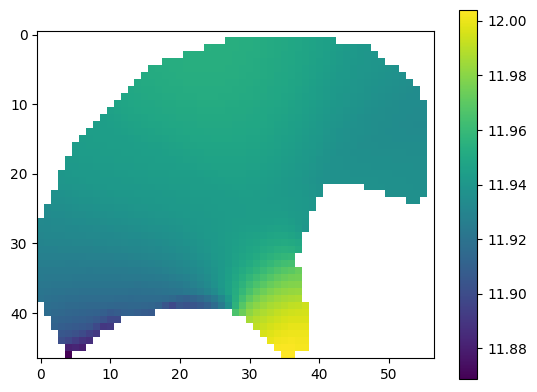

In [12]:
plt.imshow(arr)
plt.colorbar()

# Pre-IES run

In [9]:
run_name = 'local2'
temp_d = r'../models/local2/pest/local2_template'
m_d = r'../models/local2/pest/master_ies_prior'

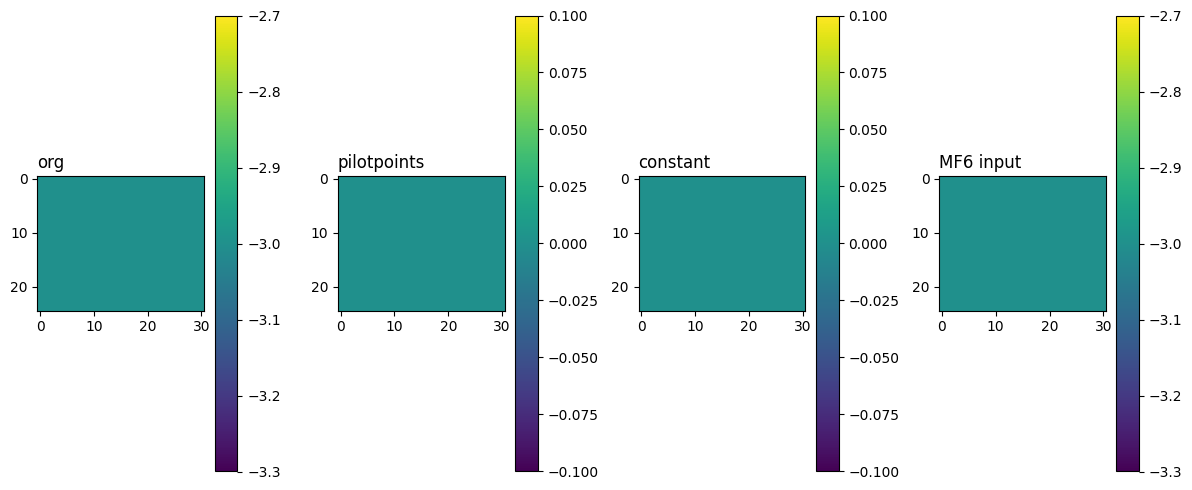

In [76]:
df = pd.read_csv(os.path.join(m_d,"mult2model_info.csv"))
kh1_df = df.loc[df.model_file.str.contains("npf_k_layer1"),:]

org_arr = np.loadtxt(os.path.join(m_d,kh1_df.org_file.iloc[0]))
inp_arr = np.loadtxt(os.path.join(m_d,kh1_df.model_file.iloc[1]))
mlt_arrs = [np.loadtxt(os.path.join(m_d,afile)) for afile in kh1_df.mlt_file]

arrs = [org_arr]
arrs.extend(mlt_arrs)
arrs.append(inp_arr)

names = ["org"]
names.extend([mf.split('.')[0].split('_')[-1] for mf in kh1_df.mlt_file])
names.append("MF6 input")

fig,axes = plt.subplots(1,kh1_df.shape[0]+2,figsize=(5*kh1_df.shape[0]+2,5))
for i,ax in enumerate(axes.flatten()):
    arr = np.log10(arrs[i])
    # arr[ib[0]==0] = np.nan
    cb = ax.imshow(arr)
    plt.colorbar(cb,ax=ax)
    ax.set_title(names[i],loc="left")
plt.tight_layout()

## Obs + Noise Plots

### Load

In [10]:
m_d = r'../models/local2/pest/master_ies_prior'
run_name = 'local2'

pr_oe = pd.read_csv(os.path.join(m_d, f"{run_name}.0.obs.csv"), index_col=0)
noise = pd.read_csv(os.path.join(m_d,f"{run_name}.obs+noise.csv"), index_col=0)

C:\Users\tfo46\AppData\Local\Temp\ipykernel_17728\648375220.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
C:\Users\tfo46\AppData\Local\Temp\ipykernel_17728\648375220.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


### Run

In [35]:
kper = 1
kstp = 1

99


Text(0.5, 1.0, 'oname:timeseries_otype:lst_usecol:pk4head_kper:1_kstp:1')

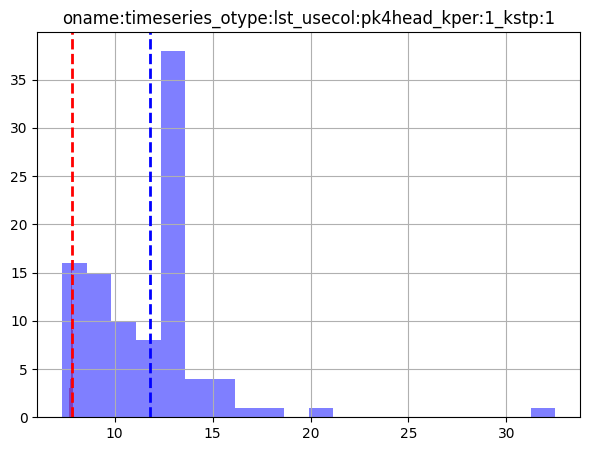

In [39]:

col = f'oname:timeseries_otype:lst_usecol:pk4head_kper:{kper}_kstp:{kstp}'
bins=20
fig, ax = plt.subplots(1,1,figsize=(7,5))

# plot posterior/noise (red)
noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")

# plot prior (blue)
head_mask = (pr_oe.loc[:,col] < 40) & (pr_oe.loc[:,col] > 0)
print(head_mask.sum())
pr_oe[head_mask].loc[:,col].hist(ax=ax, fc="blue", alpha=0.5, bins=bins, label="Prior")

# add mean line for noise & prior
meanp_val = pr_oe[head_mask].loc[:,col].mean()
ax.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
mean_val = noise.loc[:,col].mean()
ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")

ax.set_title(col)

In [22]:
mask = [
    (col.split('_')[0].split(':')[-1] == 'budget') \
         & (col.split('_')[3].split(':')[-1] == str(kper)) for col in pr_oe.columns]
# mask_b = [col.split('_')[3].split(':')[-1] == '1' for col in pr_oe_df.columns[1:]]
budget = pr_oe.loc[:,mask]

In [23]:
# rename labels
new_cols = [col.split('_')[2].split(':')[-1] for col in budget.columns]
budget.columns = new_cols
budget

,bawtotal,bghbaw,bghbconf,bghbpw,bghbspring,brcha,bstoss,btotal,in-out,percentdiscrepancy
real_name,,,,,,,,,,
0,-7.881930e+02,-1.173900e+00,-345598.000,-5708.2400,-787.0200,352091.000,0,-3.437500,-3.416300,0.00
1,-2.523540e+05,-2.523480e+05,238426.000,-131.5910,-6.5168,14063.800,0,3.406250,3.423400,0.00
2,-1.956420e+06,-1.147350e+06,2088370.000,-138028.0000,-809077.0000,6091.230,0,9.875000,9.791400,0.00
3,-7.356360e+04,-7.267710e+04,70142.600,-115.7090,-886.5610,3539.680,0,3.000000,2.998800,0.00
4,-7.161340e+03,-7.160540e+03,-1222.590,-7646.6900,-0.8041,16026.100,0,-4.474610,-4.473500,-0.03
...,...,...,...,...,...,...,...,...,...,...
95,-3.261880e+02,-3.148450e+02,46283.200,-47482.4000,-11.3429,1526.710,0,1.308590,1.310500,0.00
96,-1.405660e+04,-1.405540e+04,91850.200,-79441.5000,-1.2307,1647.920,0,0.007812,0.001366,0.00
97,-5.734950e+02,-1.019900e+02,40718.800,-40584.1000,-471.5040,435.029,0,-3.816410,-3.815900,-0.01


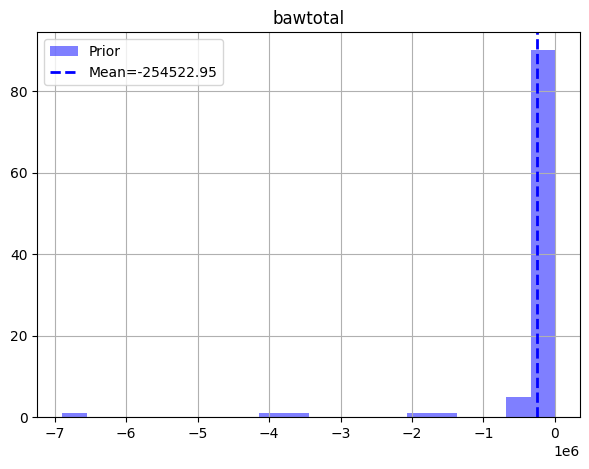

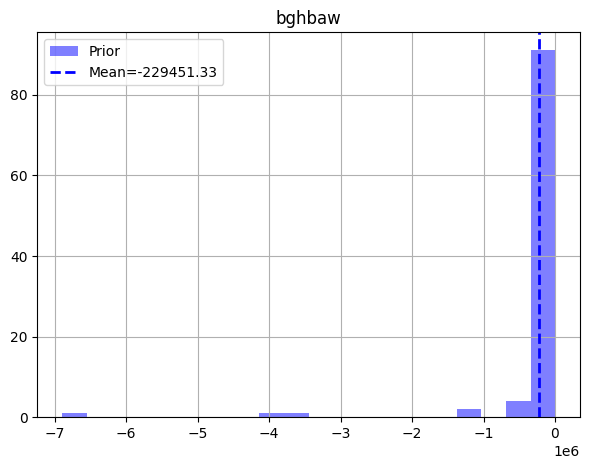

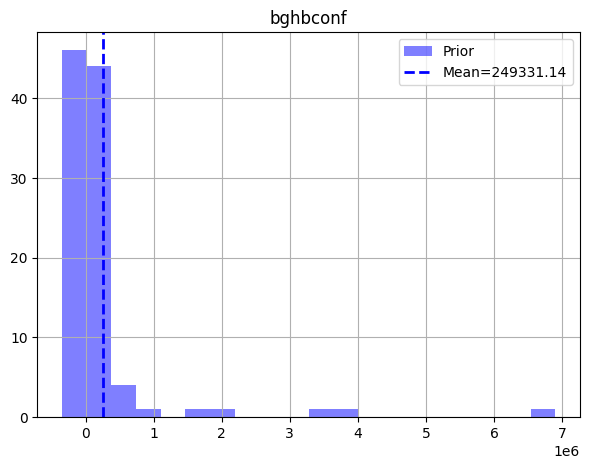

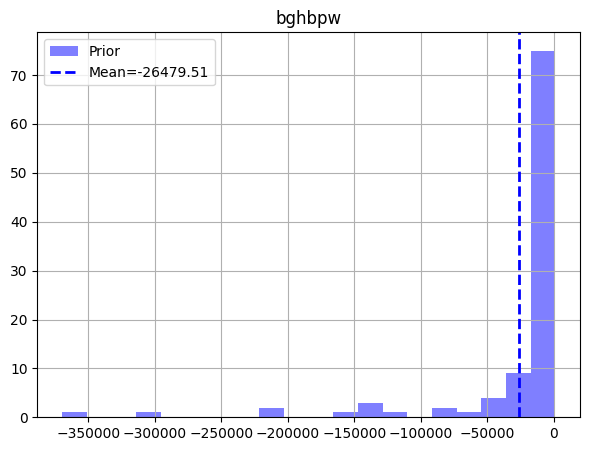

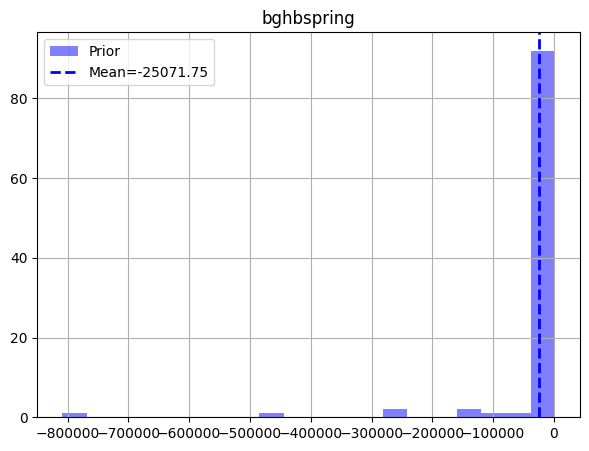

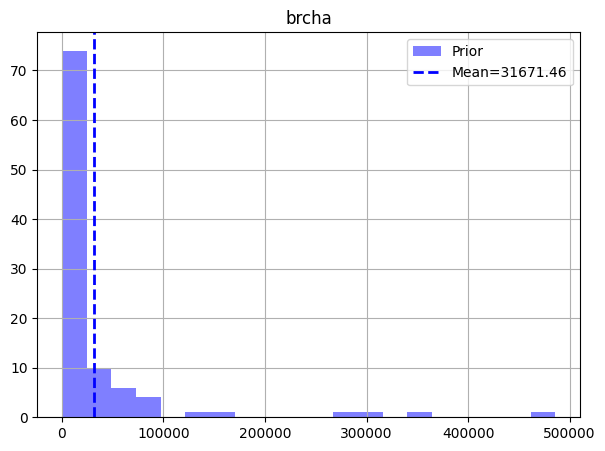

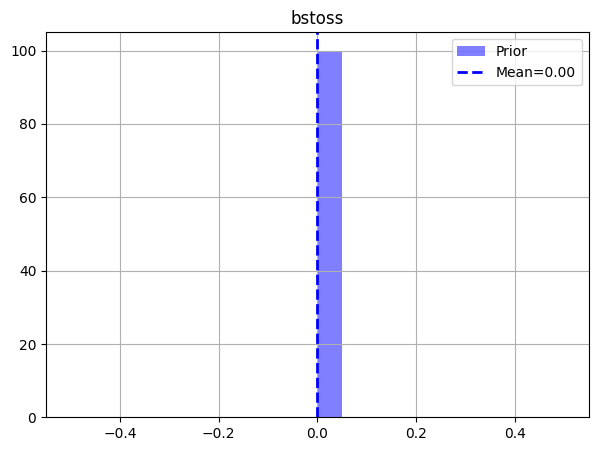

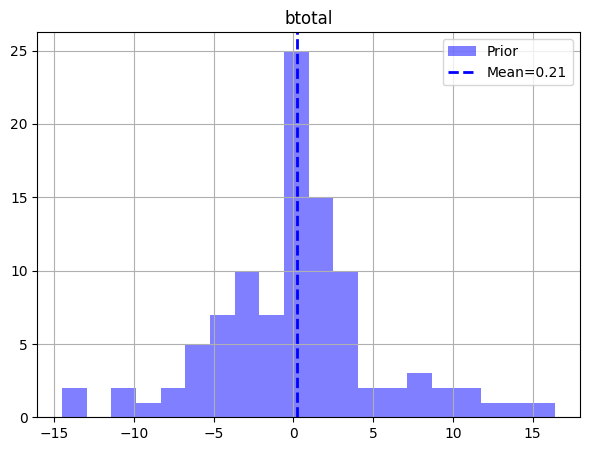

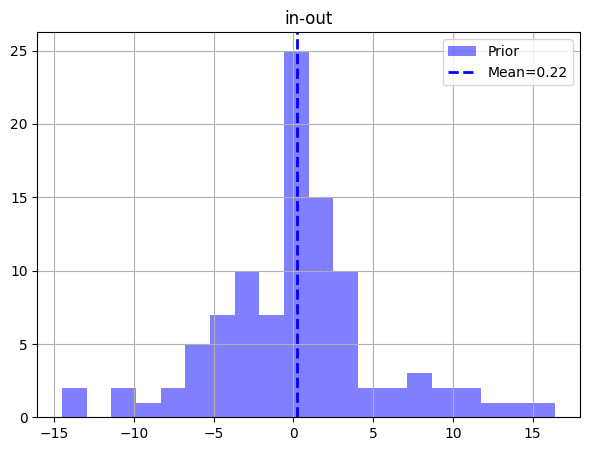

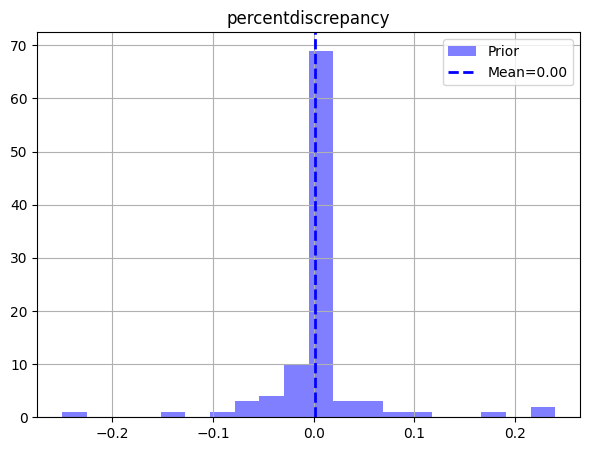

In [41]:
for col in budget.columns:
    # plot histograms
    bins=20
    fig, ax = plt.subplots(1,1,figsize=(7,5))
    budget.loc[:,col].hist(ax=ax, fc="blue", alpha=0.5, bins=bins, label="Prior")
    meanp_val = budget.loc[:,col].mean()
    ax.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
    ax.set_title(col)
    ax.legend()

c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.


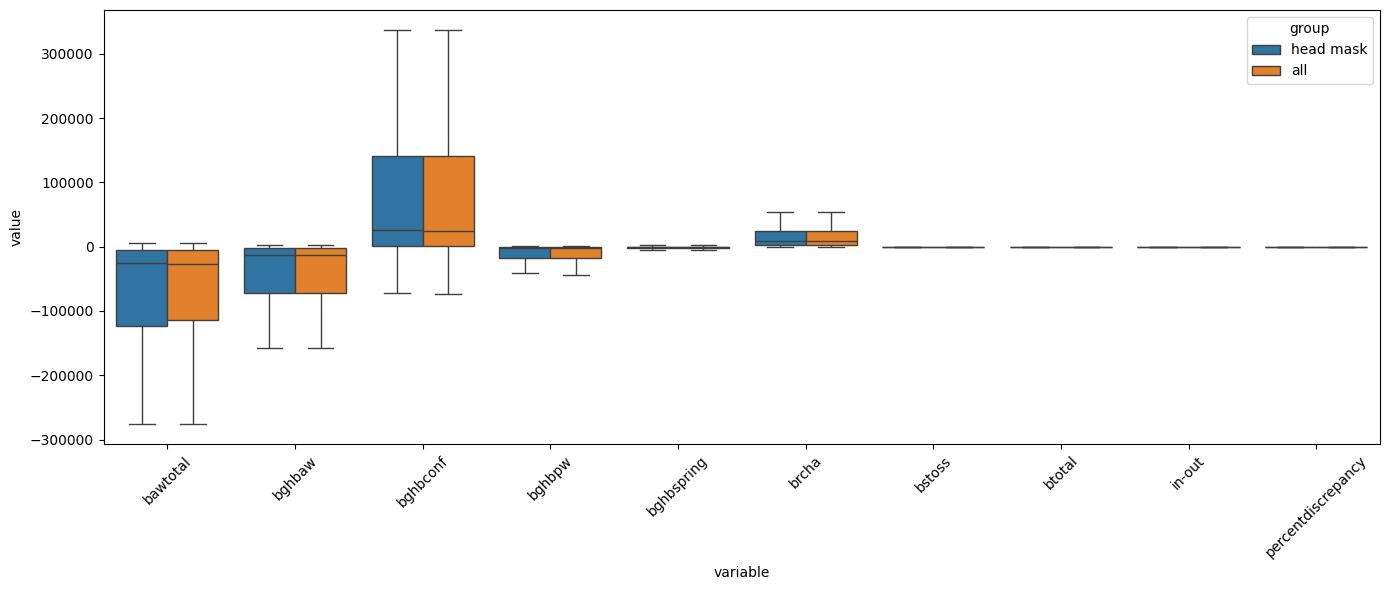

In [24]:
import seaborn as sns

# Suppose budget is your DataFrame
group1 = budget[head_mask].copy()
group2 = budget.copy()

group1['group'] = 'head mask'
group2['group'] = 'all'

# Combine and melt for seaborn
df_plot = pd.concat([group1, group2])
df_plot['realization'] = df_plot.index
df_long = df_plot.melt(id_vars=['group', 'realization'], var_name='variable', value_name='value')

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_long, 
    x='variable', 
    y='value', 
    hue='group',
    showfliers=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

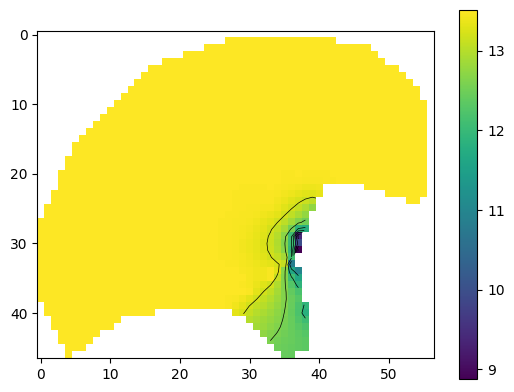

In [44]:
realization = 95
mask = [col.split('_')[0].split(':')[-1] == 'modelheads' for col in pr_oe.columns]
hdat = pr_oe.loc[:,mask]

r0 = hdat.iloc[realization, :].to_frame(name='value').reset_index()
r0.columns = ['oname', 'value']
r0['kper'] = r0['oname'].map(lambda x: int(x.split('_')[3].split(':')[-1]))
r0['kstp'] = r0['oname'].map(lambda x: int(x.split('_')[4].split(':')[-1]))
r0['i'] = r0['oname'].map(lambda x: int(x.split('_')[5].split(':')[-1]))
r0['j'] = r0['oname'].map(lambda x: int(x.split('_')[6].split(':')[-1]))

# create array
filtered = r0[(r0['kper'] == 1) & (r0['kstp'] == 1)]
arr = filtered.pivot(index='i', columns='j', values='value').to_numpy()
max_nan = 1e+30
arr = np.where(arr == max_nan, np.nan, arr)
plt.imshow(arr)
plt.colorbar()
# add contours
plt.contour(arr, colors='k', linewidths=0.5)

In [30]:
head_mask.index[head_mask][:-1]

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,
         12,   13,   14,   15,   16,   17,   18,   19,   20,   21,   22,   23,
         24,   25,   26,   27,   28,   29,   30,   31,   32,   33,   34,   35,
         36,   37,   38,   39,   40,   41,   42,   43,   44,   45,   46,   47,
         48,   49,   50,   52,   53,   54,   55,   56,   57,   58,   59,   60,
         61,   62,   63,   64,   65,   66,   67,   68,   69,   70,   71,   72,
         73,   74,   75,   76,   77,   78,   79,   80,   81,   82,   83,   84,
         85,   86,   87,   88,   89,   90,   91,   92,   93,   94,   95,   96,
         97, '98'],
      dtype='object', name='real_name')

In [33]:
type(pr_oe)

pandas.core.frame.DataFrame

In [34]:
reals = head_mask.index[head_mask][:-2] # remove base
arrs = []

mask = [col.split('_')[0].split(':')[-1] == 'modelheads' for col in pr_oe.columns]
hdat = pr_oe.loc[:,mask]

for r in reals:
    r0 = hdat.iloc[r, :].to_frame(name='value').reset_index()

    r0.columns = ['oname', 'value']
    r0['kper'] = r0['oname'].map(lambda x: int(x.split('_')[3].split(':')[-1]))
    r0['kstp'] = r0['oname'].map(lambda x: int(x.split('_')[4].split(':')[-1]))
    r0['i'] = r0['oname'].map(lambda x: int(x.split('_')[5].split(':')[-1]))
    r0['j'] = r0['oname'].map(lambda x: int(x.split('_')[6].split(':')[-1]))

    # create array
    filtered = r0[(r0['kper'] == kper) & (r0['kstp'] == kstp)]
    arr = filtered.pivot(index='i', columns='j', values='value').to_numpy()
    max_nan = 1e+30
    arr = np.where(arr == max_nan, np.nan, arr)
    arrs.append(arr)

In [45]:
head_stack = np.stack(arrs)
mean_arr = np.mean(head_stack, axis=0)
std_arr = np.std(head_stack, axis=0)

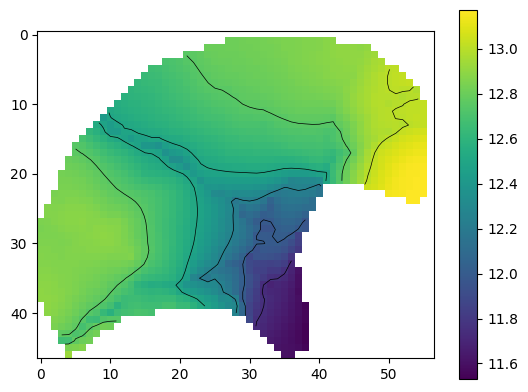

In [47]:
plt.imshow(
    mean_arr, 
)
plt.colorbar()
plt.contour(mean_arr, colors='k', linewidths=0.5)

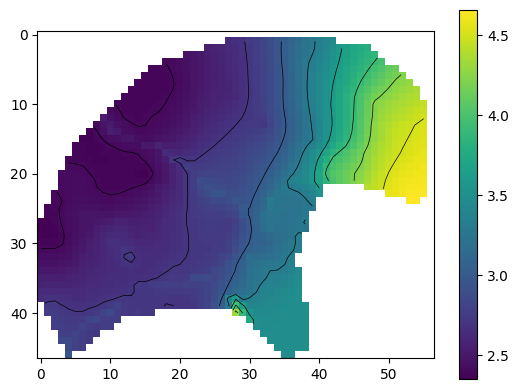

In [49]:
plt.imshow(
    std_arr, 
    )
plt.colorbar()
plt.contour(std_arr, colors='k', linewidths=0.5)

## Obs + Noise Plots (Check the priors)

In [50]:
pst = pyemu.Pst(os.path.join(m_d, f"{run_name}.pst"))
pr_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.0.obs.csv"))
noise = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,f"{run_name}.obs+noise.csv"))

### Large plot

In [51]:
pr_oe

return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


,oname:timeseries_otype:lst_usecol:awcum_kper:1_kstp:1,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:1,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:10,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:11,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:12,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:13,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:14,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:15,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:16,oname:timeseries_otype:lst_usecol:awcum_kper:2_kstp:17,...,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:51,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:52,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:53,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:54,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:55,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:56,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:6,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:7,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:8,oname:modelheads_otype:lst_usecol:head_kper:4_kstp:9_i:9_j:9
real_name,,,,,,,,,,,,,,,,,,,,,
0,-1.173860e+00,-1.293550e+00,-0.624808,-0.624417,-0.624234,-0.624153,-0.624122,-0.624100,-0.624098,-0.624097,...,14.1219,14.0539,14.0018,13.9281,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30
1,-2.523480e+05,-9.780990e+02,-21.916600,-21.915500,-21.915100,-21.914600,-21.914500,-21.914400,-21.914400,-21.914400,...,12.9725,13.0572,13.2286,13.1818,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30
2,-1.147350e+06,-1.012570e+06,-2248.590000,-2248.210000,-2247.320000,-2247.190000,-2245.060000,-2245.090000,-2244.260000,-2244.180000,...,12.1497,12.1611,12.1712,12.1781,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30
3,-7.267710e+04,-6.341890e+04,-3453.710000,-2765.600000,-2226.680000,-1802.840000,-1468.480000,-1204.070000,-994.633000,-828.395000,...,13.4108,13.4079,13.4058,13.4044,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30
4,-7.160540e+03,-4.368160e+03,-22.153800,-22.100200,-22.097100,-22.096100,-22.095000,-22.094500,-22.093500,-22.093000,...,13.5033,13.5032,13.5032,13.5032,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-3.148450e+02,-1.050590e+02,-0.207421,-0.204002,-0.203459,-0.202851,-0.202394,-0.202032,-0.201753,-0.201581,...,13.5036,13.5035,13.5034,13.5033,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30
96,-1.405540e+04,-1.697910e+01,-0.037006,-0.037006,-0.037006,-0.037006,-0.037006,-0.037006,-0.037006,-0.037006,...,13.5000,13.5000,13.5000,13.5004,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30
97,-1.019900e+02,-2.335540e+02,-183.226000,-178.565000,-174.101000,-169.822000,-165.714000,-161.768000,-157.975000,-154.325000,...,13.4910,13.4910,13.4910,13.4910,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30


In [52]:
import matplotlib.pyplot as plt

def plot_prior_noise(pr_oe, noise, pst, bins=10, all=False):
    # select only columns with nonzero weights
    if all:
        valid_cols = noise.columns.tolist()
    else:
        valid_cols = [col for col in noise.columns if pst.observation_data.loc[col, "weight"] != 0]
    
    ncols = 3
    nrows = (len(valid_cols) + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten()
    
    for i, col in enumerate(valid_cols):
        kstp = int(noise.columns[0].split('_')[-1].split(':')[-1])
        if kstp in [1]:

            ax = axes[i]
            ax2 = ax.twinx()
                
            # plot posterior/noise (red)
            noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")
            
            # plot prior (blue)
            pr_oe.loc[:,col].hist(ax=ax2, fc="blue", alpha=0.5, bins=bins, label="Prior")
            
            # add mean line for noise & prior
            meanp_val = pr_oe.loc[:,col].mean()
            ax2.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
            mean_val = noise.loc[:,col].mean()
            ax2.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")
            
            ax.set_title(col)
            
            # combine legends from both axes
            handles1, labels1 = ax.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(handles1 + handles2, labels1 + labels2, loc="best")
    
    # remove unused axes if any
    for j in range(len(valid_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [53]:
plot_prior_noise(pr_oe, noise, pst, bins=20)

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x0000015D9E9E3A60> (for post_execute), with arguments args (),kwargs {}:


ValueError: Image size of 1500x46497000 pixels is too large. It must be less than 2^23 in each direction.

ValueError: Image size of 1500x46497000 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 1500x4.6497e+07 with 2664 Axes>

### individual plots

NameError: name 'noise' is not defined

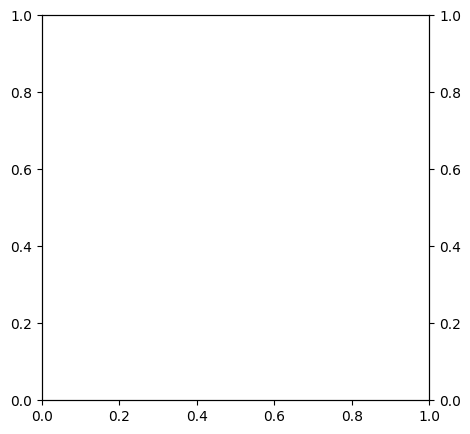

In [ ]:
bins=50
col = 'oname:bgt_otype:lst_usecol:bghbaw_kper:1'

fig, ax = plt.subplots(figsize=(5, 5))

ax2 = ax.twinx()
    
# plot posterior/noise (red)
noise.loc[:,col].hist(ax=ax, fc="r", alpha=0.5, bins=bins, label="Noise")

# plot prior (blue)
mask = (pr_oe.loc[:,col].values < 30) & (pr_oe.loc[:,col].values > 0)
pr_oe.loc[mask,col].hist(ax=ax2, fc="blue", alpha=0.5, bins=bins, label="Prior")

# add mean line for noise & prior
meanp_val = pr_oe.loc[mask,col].mean()
ax2.axvline(meanp_val, color="blue", linestyle="--", linewidth=2, label=f"Mean={meanp_val:.2f}")
mean_val = noise.loc[:,col].mean()
ax2.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean={mean_val:.2f}")

ax.set_title(col)

# combine legends from both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="best")

# ax.set_xlim(-5000, 5000)

In [ ]:
mask = (pr_oe.loc[:,col].values < 30) & (pr_oe.loc[:,col].values > 0)
pr_oe.loc[mask,col]

Series([], Name: oname:bgt_otype:lst_usecol:bghbaw_kper:1, dtype: float64)

## Timeseries Plots

#### PK4

In [ ]:
# clip prior values
tag = 'oname:timeseries_otype:lst_usecol:pk4springdiff_kper:'
clipped = pr_oe.loc[:,[col for col in pr_oe.columns if tag in col]]

In [104]:
clipped

return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


,oname:budget_otype:lst_usecol:bghbconf_kper:1,oname:budget_otype:lst_usecol:bghbconf_kper:2,oname:budget_otype:lst_usecol:bghbconf_kper:3,oname:budget_otype:lst_usecol:bghbconf_kper:4
real_name,,,,
0,-345598.000,-349642.00,-347703.000,-347711.000
1,238426.000,-14040.50,308781.000,308778.000
2,2088370.000,-2489.59,1444480.000,1444480.000
3,70142.600,-3365.85,241708.000,241706.000
4,-1222.590,-15981.10,-7375.820,-7375.320
...,...,...,...,...
95,46283.200,-1504.43,3730.640,3729.190
96,91850.200,-1638.61,22289.300,22289.200
97,40718.800,-350487.00,1251.810,1250.150


In [97]:
ts = []
for col in clipped.columns:
    usecol = col.split('_')[2].split(':')[-1]
    kper = int(col.split('_')[3].split(':')[-1])
    kstp = int(col.split('_')[4].split(':')[-1])
    rdf = clipped.loc[:, col].to_frame(name='value').reset_index()
    rdf['usecol'] = usecol
    rdf['kper'] = kper
    rdf['kstp'] = kstp
    rdf['realization'] = rdf.index
    ts.append(rdf)
ts_df = pd.concat(ts)
ts_df

,real_name,value,usecol,kper,kstp,realization
0,0,9.25576,pk4springdiff,1,1,0
1,1,5.94609,pk4springdiff,1,1,1
2,2,1.21866,pk4springdiff,1,1,2
3,3,5.86822,pk4springdiff,1,1,3
4,4,5.90897,pk4springdiff,1,1,4
...,...,...,...,...,...,...
95,95,4.31059,pk4springdiff,4,9,95
96,96,4.35379,pk4springdiff,4,9,96
97,97,4.34447,pk4springdiff,4,9,97
98,98,4.41879,pk4springdiff,4,9,98


C:\Users\tfo46\AppData\Local\Temp\ipykernel_11032\1703910500.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


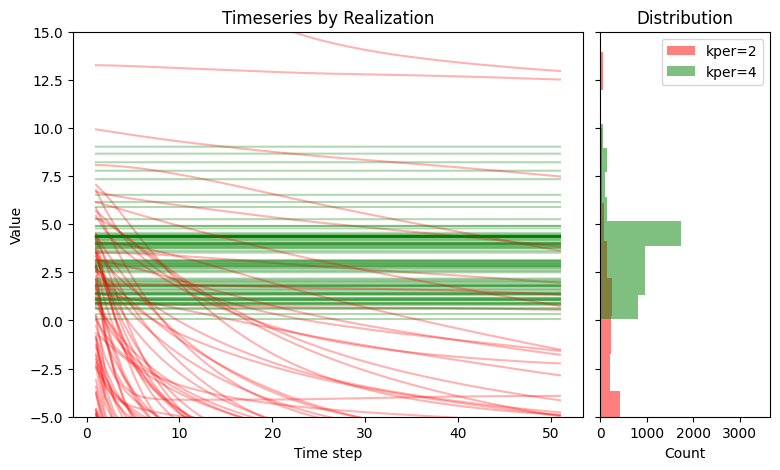

In [102]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create figure with 2 columns: main plot + narrow histogram
fig = plt.figure(figsize=(9, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.05)

ax_main = fig.add_subplot(gs[0])   # main timeseries
ax_hist = fig.add_subplot(gs[1], sharey=ax_main)  # histogram panel (share y-axis)

# Loop through realizations for timeseries
for r in ts_df['realization'].unique():
    mask = ts_df['realization'] == r
    
    # kper = 2 (red)
    ts_df_kper2 = ts_df.loc[mask & (ts_df['kper'] == 2)].sort_values(by='kstp')
    ax_main.plot(ts_df_kper2['kstp'], ts_df_kper2['value'], color='red', alpha=0.3)
    
    # kper = 4 (green)
    ts_df_kper4 = ts_df.loc[mask & (ts_df['kper'] == 4)].sort_values(by='kstp')
    ax_main.plot(ts_df_kper4['kstp'], ts_df_kper4['value'], color='green', alpha=0.3)

# Limit + clean main axis
ax_main.set_ylim(-5, 15)
ax_main.set_xlabel("Time step")
ax_main.set_ylabel("Value")
ax_main.set_title("Timeseries by Realization")
# ax_main.legend(None)

# --- Histogram panel ---
vals_kper2 = ts_df.loc[ts_df['kper'] == 2, 'value']
vals_kper4 = ts_df.loc[ts_df['kper'] == 4, 'value']

ax_hist.hist(vals_kper2, bins=200, orientation='horizontal', 
             color='red', alpha=0.5, label="kper=2")
ax_hist.hist(vals_kper4, bins=200, orientation='horizontal', 
             color='green', alpha=0.5, label="kper=4")

ax_hist.set_xlabel("Count")
ax_hist.set_ylabel("")  # hide duplicate y-label
ax_hist.set_title("Distribution")
ax_hist.legend()

# Remove extra tick labels on shared y-axis
plt.setp(ax_hist.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()

#### Budget

In [107]:
# clip prior values
tag = 'oname:budget_otype:lst_usecol:bghbconf_kper:'
clipped = pr_oe.loc[:,[col for col in pr_oe.columns if tag in col]]

In [108]:
ts = []
for col in clipped.columns:
    usecol = col.split('_')[2].split(':')[-1]
    kper = int(col.split('_')[3].split(':')[-1])
    rdf = clipped.loc[:, col].to_frame(name='value').reset_index()
    rdf['usecol'] = usecol
    rdf['kper'] = kper
    rdf['realization'] = rdf.index
    ts.append(rdf)
ts_df = pd.concat(ts)
ts_df

,real_name,value,usecol,kper,realization
0,0,-345598.000,bghbconf,1,0
1,1,238426.000,bghbconf,1,1
2,2,2088370.000,bghbconf,1,2
3,3,70142.600,bghbconf,1,3
4,4,-1222.590,bghbconf,1,4
...,...,...,...,...,...
95,95,3729.190,bghbconf,4,95
96,96,22289.200,bghbconf,4,96
97,97,1250.150,bghbconf,4,97
98,98,-34172.000,bghbconf,4,98


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.


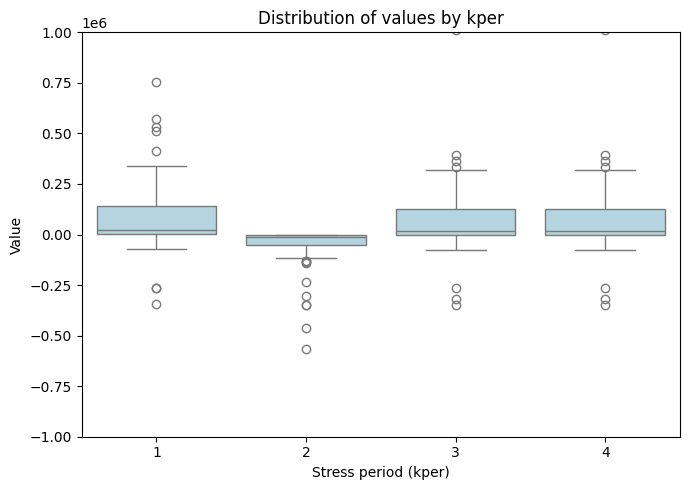

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))

# Horizontal boxplots: kper on y-axis, value on x-axis
sns.boxplot(
    data=ts_df,
    y="value",
    x="kper",
    ax=ax,
    color="lightblue"
)

ax.set_ylabel("Value")
ax.set_xlabel("Stress period (kper)")
ax.set_title("Distribution of values by kper")
ax.set_ylim(-1000000, 1000000)

plt.tight_layout()
plt.show()

## old

In [109]:
records = []
# for realization in range(pr_oe.shape[0]):
for realization in range(1):
    print(f'Realization: {realization}')
    for i in range(len(clipped.iloc[realization,:].index)):
        col = clipped.iloc[realization,:].index[i]
        oname = col.split('_')[0].split(':')[-1]
        if oname != 'h':
            print(f'\tColumn: {col}')
            real_data = clipped.loc[:, col]
            val = clipped.iloc[realization,:].values[i]
            rank = stats.percentileofscore(real_data, val)
            col_name = col.split('_')[2].split(':')[-1]
            kper = col.split('_')[3].split(':')[-1]
            if oname == 'ts':
                kstp = col.split('_')[-1].split(':')[-1]
            else:
                kstp = None
            rec = {
                'realization': realization,
                'col': col,
                'oname': oname,
                'usecol': col_name,
                'kper': int(kper),
                'kstp': int(kstp),
                'value': val,
                'rank': rank,
                }
            records.append(rec)
obs_vals = pd.DataFrame(records)

Realization: 0
	Column: oname:budget_otype:lst_usecol:bghbconf_kper:1


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

In [58]:
obs_vals['kper'] = pd.to_numeric(obs_vals['kper'], errors='coerce')
obs_vals['kstp'] = pd.to_numeric(obs_vals['kstp'], errors='coerce')

In [63]:
obs_vals

,realization,col,oname,usecol,kper,kstp,value,rank
0,0,oname:timeseries_otype:lst_usecol:pk4head_kper:1_kstp:1,timeseries,pk4head,1,NaN,16.84580,96.0
1,0,oname:timeseries_otype:lst_usecol:pk4head_kper:2_kstp:1,timeseries,pk4head,2,NaN,10.39050,73.0
2,0,oname:timeseries_otype:lst_usecol:pk4head_kper:2_kstp:10,timeseries,pk4head,2,NaN,3.46316,70.0
3,0,oname:timeseries_otype:lst_usecol:pk4head_kper:2_kstp:11,timeseries,pk4head,2,NaN,3.45932,70.0
4,0,oname:timeseries_otype:lst_usecol:pk4head_kper:2_kstp:12,timeseries,pk4head,2,NaN,3.45753,72.0
...,...,...,...,...,...,...,...,...
99,0,oname:timeseries_otype:lst_usecol:pk4head_kper:4_kstp:51,timeseries,pk4head,4,NaN,16.90120,94.0
100,0,oname:timeseries_otype:lst_usecol:pk4head_kper:4_kstp:6,timeseries,pk4head,4,NaN,16.90110,94.0
101,0,oname:timeseries_otype:lst_usecol:pk4head_kper:4_kstp:7,timeseries,pk4head,4,NaN,16.90110,94.0
102,0,oname:timeseries_otype:lst_usecol:pk4head_kper:4_kstp:8,timeseries,pk4head,4,NaN,16.90120,94.0


In [60]:
obs_vals['usecol'].unique()

array(['pk4head'], dtype=object)

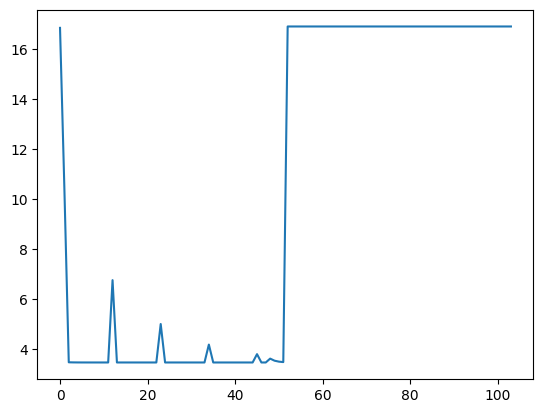

In [68]:
plt.plot(
    obs_vals.index,
    obs_vals['value'],       
)

Text(0.5, 1.0, 'pk4head')

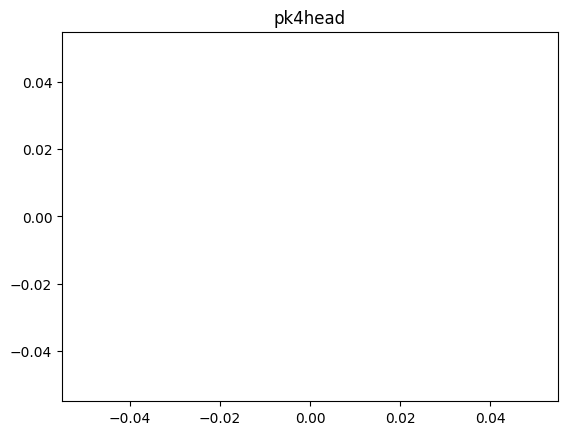

In [64]:
col = 'pk4head'
for r in obs_vals['realization'].unique():
    mask = (obs_vals['usecol']==col) & \
        (obs_vals['realization']==r) & \
            (obs_vals['kper']==2)
    dat = obs_vals.loc[mask].sort_values(by='kstp')
    plt.plot(dat['kstp'], dat['value'], alpha=0.5)

plt.title(col)
# plt.ylim(-250, 20)

(-20000.0, 20000.0)

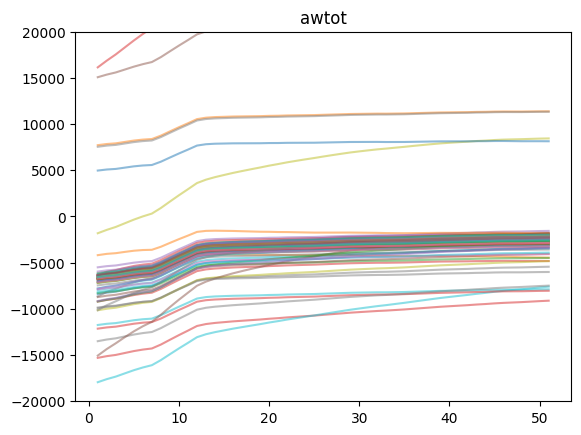

In [229]:
col = 'awtot'
for r in obs_vals['realization'].unique():
    mask = (obs_vals['usecol']==col) & \
        (obs_vals['realization']==r) & \
            (obs_vals['kper']==2)
    dat = obs_vals.loc[mask].sort_values(by='kstp')
    plt.plot(dat['kstp'], dat['value'], alpha=0.5)

plt.title(col)
plt.ylim(-20000, 20000)
# pr_oe.iloc[:,col].transform(lambda x: x.rank(pct=True) * 100)

(0.0, 30.0)

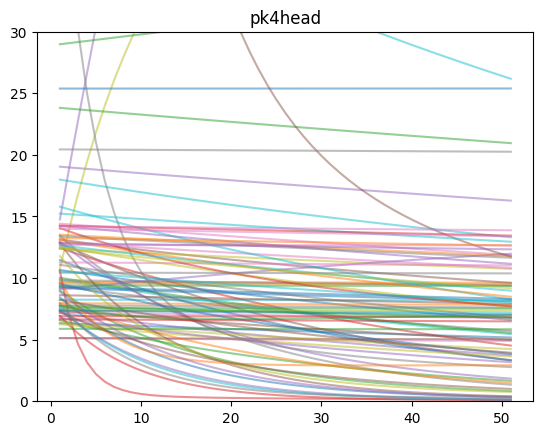

In [223]:
for r in obs_vals['realization'].unique():
    mask = (obs_vals['usecol']=='pk4head') & \
        (obs_vals['realization']==r) & \
            (obs_vals['kper']==2)
    dat = obs_vals.loc[mask].sort_values(by='kstp')
    plt.plot(dat['kstp'], dat['value'], alpha=0.5)

plt.title('pk4head')
plt.ylim(0,30)
# pr_oe.iloc[:,col].transform(lambda x: x.rank(pct=True) * 100)

(-10.0, 20.0)

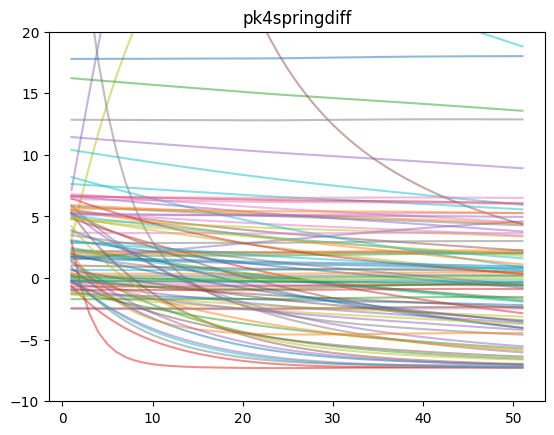

In [222]:
for r in obs_vals['realization'].unique():
    mask = (obs_vals['usecol']=='pk4springdiff') & \
        (obs_vals['realization']==r) & \
            (obs_vals['kper']==2)
    dat = obs_vals.loc[mask].sort_values(by='kstp')
    plt.plot(dat['kstp'], dat['value'], alpha=0.5)

plt.title('pk4springdiff')
plt.ylim(-10,20)
# pr_oe.iloc[:,col].transform(lambda x: x.rank(pct=True) * 100)

In [ ]:
# result['percentile'] = (
#     result.groupby('usecol')['value']
#     .transform(lambda x: x.rank(pct=True) * 100)
# )

In [ ]:
result['usecol'].unique()

array(['awcum', 'awgwhead', 'awq', 'awswgwdiff', 'awswhead', 'awtot',
       'confhead', 'pk4awgwdiff', 'pk4awswdiff', 'pk4confdiff', 'pk4head',
       'pk4pwgwdiff', 'pk4pwswdiff', 'pk4springdiff', 'pwcum', 'pwgwhead',
       'pwq', 'pwswgwdiff', 'pwswhead', 'pwtot', 'springcum',
       'springhead', 'springq'], dtype=object)

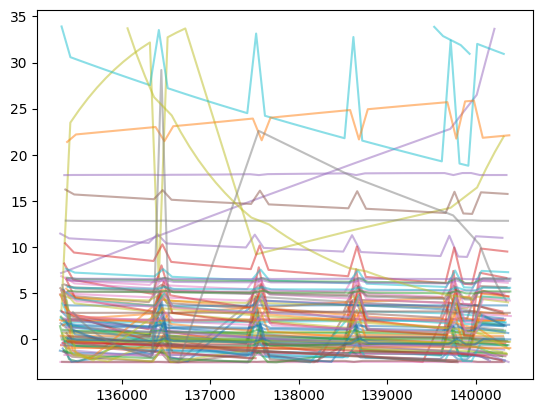

In [100]:
mask = (result['usecol'] == 'pk4springdiff') & (result['kper'] == 2) & (result['percentile'] > 10) & (result['percentile'] < 90)
data = result.loc[mask,:]

for r in data['realization'].unique():
    ts = data.loc[data['realization'] == r, 'value']
    plt.plot(ts, label=f'Realization {r}', alpha=0.5)

In [ ]:
data.loc[data['realization'] == r,:]

,realization,usecol,kper,kstp,value,percentile
139533,33,pk4springdiff,2,48,33.8715,89.980769
139633,33,pk4springdiff,2,49,32.8664,89.903846
139833,33,pk4springdiff,2,50,31.8905,89.826923
139933,33,pk4springdiff,2,51,30.9433,89.778846


In [ ]:
result[['usecol', 'value']].groupby('usecol').agg(['min', 'max', 'mean', 'std'])

value                                          
                        min           max          mean           std
usecol                                                               
awcum         -3.964330e+08  8.219140e+07 -1.984738e+06  2.647527e+07
awgwhead      -5.590590e+03  4.418920e+04  4.869103e+02  3.573233e+03
awq           -3.164540e+05  3.524680e-01 -3.182738e+02  4.341536e+03
awswgwdiff    -4.417920e+04  5.599950e+03 -4.785820e+02  3.573273e+03
awswhead       6.474750e+00  1.214820e+01  8.328270e+00  1.441463e+00
awtot         -3.964390e+08  8.226880e+07 -1.997722e+06  2.647626e+07
confhead       1.043170e+01  1.725540e+01  1.308199e+01  1.039924e+00
pk4awgwdiff   -4.412770e+04  2.184660e+04 -1.675207e+02  3.337127e+03
pk4awswdiff   -4.708660e+03  2.604110e+04  3.110614e+02  2.165675e+03
pk4confdiff   -4.714300e+03  2.603780e+04  3.063077e+02  2.165835e+03
pk4head       -4.699300e+03  2.605050e+04  3.193898e+02  2.165802e+03
pk4pwgwdiff   -4.710760e+03  1.416450e+04 -1.886150e+01  1.250817e+03
pk4pwswdiff   -4.712090e+03  2.604100e+04  3.104429e+02  2.165880e+03
pk4springdiff -4.707910e+03  2.604250e+04  3.111454e+02  2.165737e+03
pwcum         -1.239600e+06  1.316720e+05 -8.139701e+03  4.811801e+04
pwgwhead      -2.583290e+02  1.915540e+04  3.382511e+02  1.619667e+03
pwq           -3.697460e+04  7.465040e+03 -1.851712e+02  1.150661e+03
pwswgwdiff    -1.914810e+04  2.704850e+02 -3.293043e+02  1.619796e+03
pwswhead       3.938530e+00  1.291580e+01  8.946806e+00  1.166405e+00
pwtot         -1.245290e+06  1.288130e+05 -1.243782e+04  4.808283e+04
springcum     -4.859490e+04  1.219840e+01 -5.458741e+02  3.943549e+03
springhead     4.915100e+00  1.212100e+01  8.244400e+00  1.134470e+00
springq       -1.361840e+04  5.597700e+03 -1.177115e+02  1.015965e+03

In [ ]:
result['percentile'] = (
    result.groupby('usecol')['value']
    .transform(lambda x: x.rank(pct=True) * 100)
)

In [ ]:
result

,realization,usecol,kper,kstp,value,percentile
0,0,awcum,1,1,-9745.000000,22.047170
1,1,awcum,1,1,710.237000,88.650943
2,2,awcum,1,1,429871.000000,97.745283
3,3,awcum,1,1,-198.091000,71.198113
4,4,awcum,1,1,913.243000,89.339623
...,...,...,...,...,...,...
243795,95,springq,4,9,-5.578640,58.518868
243796,96,springq,4,9,-0.000124,94.174528
243797,97,springq,4,9,-0.001443,92.415094
243798,98,springq,4,9,39.268300,98.773585


<Figure size 3000x3000 with 0 Axes>

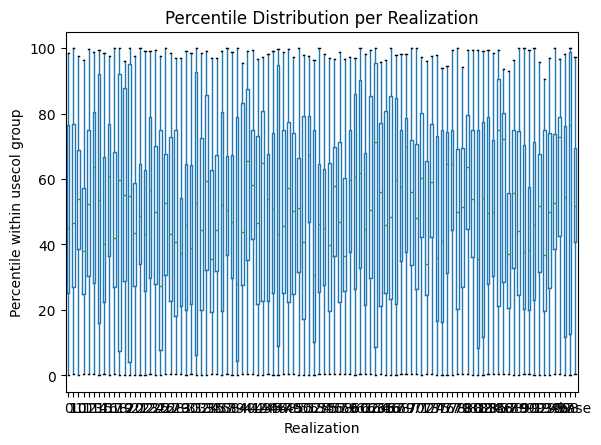

In [ ]:
# Boxplot of percentiles per realization
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 30))
result.boxplot(column='percentile', by='realization', grid=False)
plt.ylabel('Percentile within usecol group')
plt.xlabel('Realization')
plt.title('Percentile Distribution per Realization')
plt.suptitle('')
plt.show()

## Investigate specific realizations

In [18]:
pr_pe = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.0.par.csv"))

In [19]:
pr_pe

return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:12_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:17_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:22_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:27_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:7_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:12_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:17_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:22_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:27_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:12_j:2_zone:1,...,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:19_idx2:4,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:19_idx2:5,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:20_idx2:1,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:20_idx2:2,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:20_idx2:3,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:20_idx2:4,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:21_idx2:0,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:21_idx2:1,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:21_idx2:2,pname:ghb-conf-head-cn_inst:2_ptype:cn_usecol:3_pstyle:a
real_name,,,,,,,,,,,,,,,,,,,,,
0,8.000890,11.072500,2.010360,0.389044,6.618630,7.706680,3.867370,3.282980,1.269850,1.885480,...,-0.654714,-0.542078,-0.691195,-0.742691,-0.865933,-0.784459,-0.782371,-0.884791,-0.863386,-0.449483
1,22.314900,9.008250,5.591420,2.229630,6.439650,4.591740,8.377770,5.813640,1.192450,2.792310,...,0.702379,0.277648,0.949108,1.029730,0.743256,0.579546,0.854280,0.630081,0.649254,-0.076086
2,0.106468,0.132968,0.403636,0.196436,0.782189,0.074772,0.039802,0.075567,0.195545,2.162730,...,-0.346583,-0.223921,0.381298,0.540780,-0.041180,0.054211,0.374716,0.341205,0.416268,0.485192
3,0.145517,0.239867,0.643708,0.872587,0.394064,0.287395,0.507956,0.343376,1.942490,5.620720,...,-0.386566,-0.450820,-0.672805,-0.218561,-0.337208,-0.269538,-0.550932,-0.320538,-0.253803,-0.854129
4,1.872070,0.645393,1.093760,0.797467,0.160693,0.321927,0.356099,0.610484,2.891300,0.227012,...,-0.285545,-0.170946,0.242404,0.183530,-0.043293,0.048105,0.546647,0.284584,0.180180,0.174282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.517170,0.190053,0.142611,0.093690,6.045420,7.162560,0.319358,0.195995,0.458060,37.103800,...,-0.630494,-0.599741,-0.605789,-0.412670,-0.380860,-0.428920,-0.641957,-0.440032,-0.197136,0.580019
96,3.947550,3.083720,2.473750,1.267360,0.285206,0.377027,0.332835,1.008950,0.763887,0.239943,...,-0.233210,-0.286943,-0.485114,-0.440976,-0.324428,-0.420567,-0.569928,-0.296302,-0.360358,0.355420
97,0.615812,1.480100,0.692888,0.282339,0.917813,1.696360,1.834380,1.560840,1.279250,0.516066,...,-0.017048,-0.259517,-0.508451,-0.456253,-0.070142,-0.141783,-0.356164,-0.690831,-0.485836,-0.643265


In [91]:
mask = pr_oe.loc[:,'oname:ts_otype:lst_usecol:pk4head_kper:2_kstp:4'].values > 4
pr_oe.values[mask,:]

array([[-9.74500e+03, -6.04014e+02, -5.92179e+02, ...,  0.00000e+00,
         0.00000e+00,  0.00000e+00],
       [ 7.10237e+02,  1.41790e+04,  1.41540e+04, ...,  0.00000e+00,
         0.00000e+00,  0.00000e+00],
       [ 4.29871e+05,  1.73646e+07,  5.73223e+06, ...,  0.00000e+00,
         0.00000e+00,  0.00000e+00],
       ...,
       [-1.09578e+00, -2.96771e+03, -1.10101e+03, ...,  0.00000e+00,
         0.00000e+00,  0.00000e+00],
       [ 1.64086e+06,  8.21914e+07,  8.19758e+07, ...,  0.00000e+00,
         0.00000e+00,  0.00000e+00],
       [-1.97478e+02, -6.76621e+02, -6.40308e+02, ...,  0.00000e+00,
         0.00000e+00,  0.00000e+00]], shape=(99, 2544))

## Jacobian

In [ ]:
jco = pyemu.Jco.from_binary(os.path.join(m_d, f"prior_pe.jcb"))
df = jco.to_dataframe()

In [ ]:
df.head()

,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:2_j:12_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:2_j:17_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:2_j:22_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:2_j:27_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:7_j:7_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:7_j:12_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:7_j:17_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:7_j:22_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:7_j:27_zone:1,pname:npfklayer1_pp_inst:0_ptype:pp_pstyle:m_i:12_j:2_zone:1,...,pname:ghb_spring_cond_cn_inst:1_ptype:cn_usecol:4_pstyle:m,pname:ghb_spring_head_cn_inst:1_ptype:cn_usecol:3_pstyle:a,pname:ghb_spring_cond_cn_inst:2_ptype:cn_usecol:4_pstyle:m,pname:ghb_spring_head_cn_inst:2_ptype:cn_usecol:3_pstyle:a,pname:ghb_conf_cond_cn_inst:0_ptype:cn_usecol:4_pstyle:m,pname:ghb_conf_head_cn_inst:0_ptype:cn_usecol:3_pstyle:a,pname:ghb_conf_cond_cn_inst:1_ptype:cn_usecol:4_pstyle:m,pname:ghb_conf_head_cn_inst:1_ptype:cn_usecol:3_pstyle:a,pname:ghb_conf_cond_cn_inst:2_ptype:cn_usecol:4_pstyle:m,pname:ghb_conf_head_cn_inst:2_ptype:cn_usecol:3_pstyle:a
0,8.000889,11.072511,2.010359,0.389044,6.618626,7.706685,3.867375,3.282983,1.269850,1.885482,...,24.393474,0.769893,0.609996,-0.112272,0.490300,0.068291,0.023062,-1.181960,0.189966,0.152867
1,22.314926,9.008254,5.591419,2.229635,6.439655,4.591744,8.377765,5.813641,1.192447,2.792311,...,0.183070,1.373973,0.119087,0.564550,0.034979,1.326108,0.010811,-0.411816,0.065970,0.293858
2,0.106468,0.132968,0.403636,0.196436,0.782189,0.074772,0.039802,0.075567,0.195545,2.162730,...,0.072525,-0.152784,0.044852,0.781808,0.001926,0.089104,0.000275,0.675812,1.480468,0.657896
3,0.145517,0.239867,0.643708,0.872587,0.394064,0.287395,0.507956,0.343376,1.942490,5.620715,...,0.062007,0.203093,0.494922,-0.472898,0.388034,0.596625,1.419568,0.552569,29.724115,-0.721726
4,1.872067,0.645393,1.093763,0.797467,0.160693,0.321927,0.356099,0.610484,2.891301,0.227012,...,3.992244,1.327888,0.010521,1.472927,3.199389,-0.283808,14.492147,1.288341,3.200629,-0.339200


(0.0, 10.0)

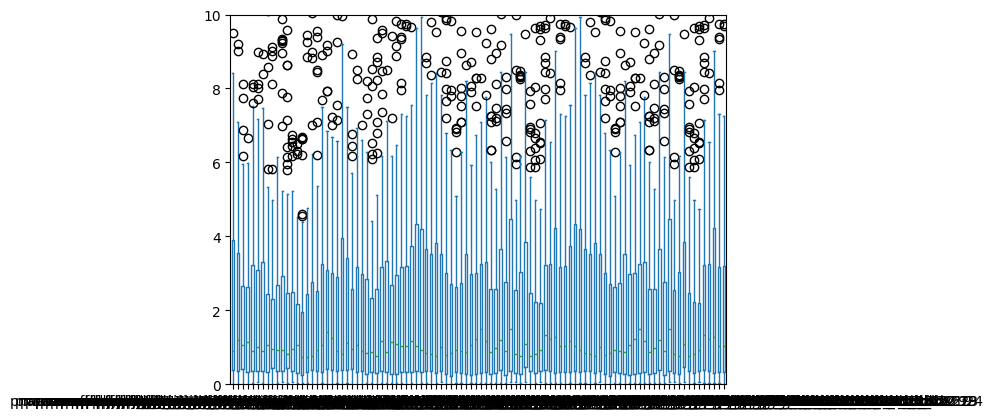

In [ ]:
df.iloc[:,:100].plot(kind='box', legend=False)
# plt.yscale('symlog')
plt.ylim(0, 10)

In [ ]:
sc = pyemu.Schur(os.path.join(m_d, f"prior_pe.jcb"), pst=pst)

Exception: forecast argument: oname:ts_otype:lst_usecol:pk4head_kper:3_kstp:1 not found in jco row names and could not be loaded from a file.

# IES History Match

In [23]:
run_name = 'local2'
temp_d = r'../models/local2/pest/local2_template'
m_d = r'../models/local2/pest/master_ies'

## Phi

TypeError: no numeric data to plot

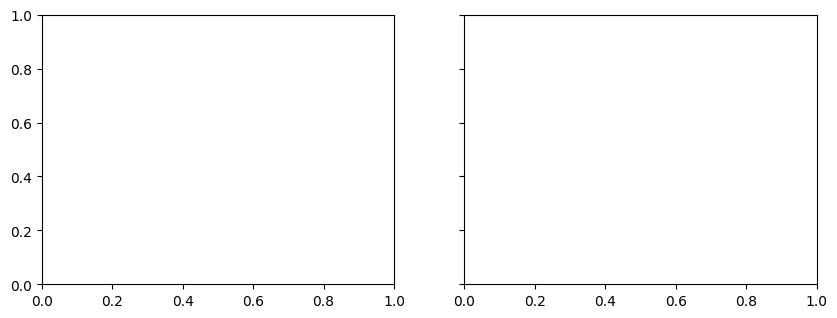

In [31]:
f_act = os.path.join(m_d, f"{run_name}.phi.actual.csv")
f_meas = os.path.join(m_d, f"{run_name}.phi.meas.csv")

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10,3.5))
# left
ax = axes[0]
phi = pd.read_csv(f_act, index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.5,color='k', ax=ax)
ax.set_title(r'Actual $\Phi$')
ax.set_ylabel(r'log $\Phi$')
# right
ax = axes[-1]
phi = pd.read_csv(f_meas,index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.2,color='r', ax=ax)
ax.set_title(r'Measured+Noise $\Phi$')
fig.tight_layout()

In [25]:
phi.iloc[-1,6:]

1       2124870.0
2         22261.6
3       1641570.0
4         94239.5
5        111933.0
          ...    
95        84648.8
96      1967930.0
97      1481890.0
98       789371.0
base      61446.8
Name: 496, Length: 99, dtype: float64

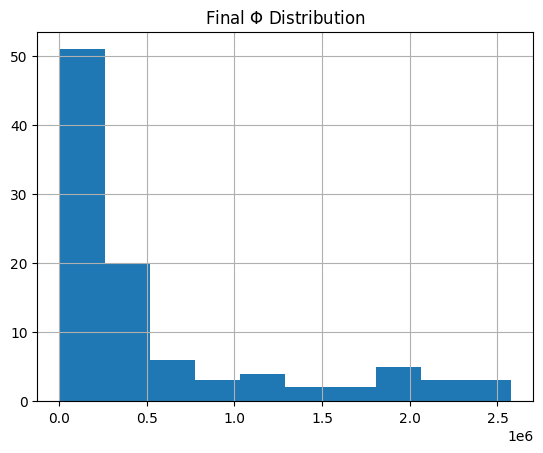

In [26]:
plt.figure()
phi.iloc[-1,6:].hist()
plt.title(r'Final $\Phi$ Distribution');

# Obs: Prior vs Posterior

In [36]:
pst = pyemu.Pst(os.path.join(m_d, f"{run_name}.pst"))
pr_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.0.obs.csv"))
pt_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.{pst.control_data.noptmax}.obs.csv"))
noise = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,f"{run_name}.obs+noise.csv"))

## 1:1 plots

[<Figure size 800x1050 with 0 Axes>,
 <Figure size 800x1050 with 8 Axes>,
 <Figure size 800x1050 with 8 Axes>,
 <Figure size 800x1050 with 8 Axes>]

<Figure size 800x1050 with 0 Axes>

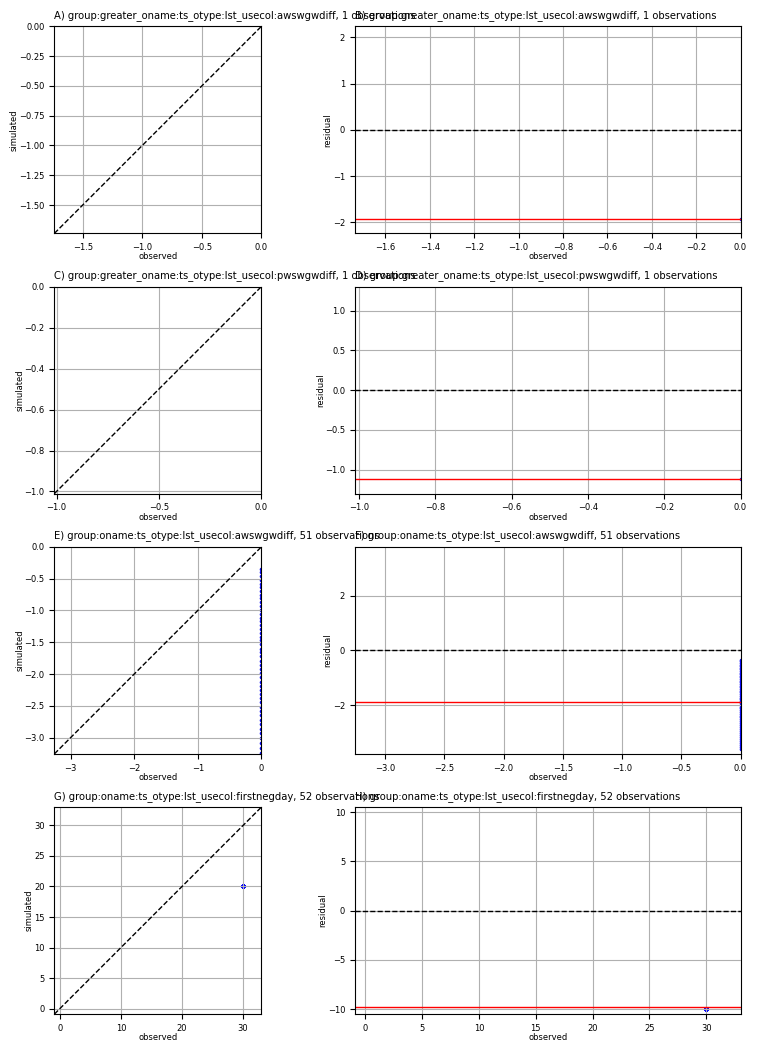

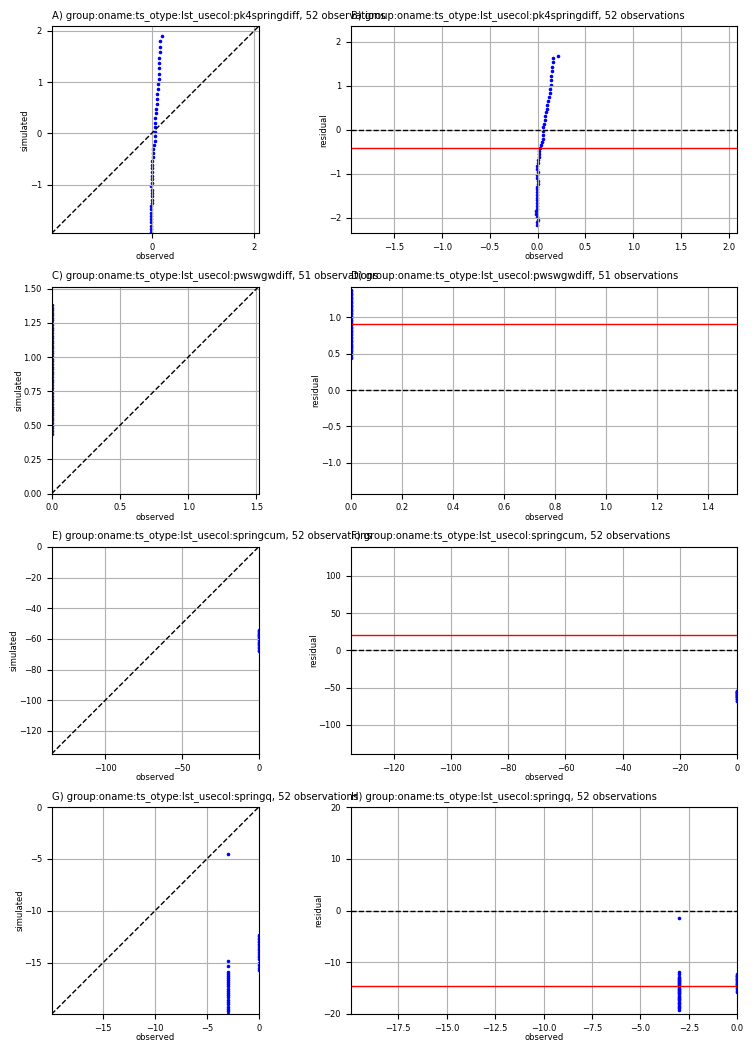

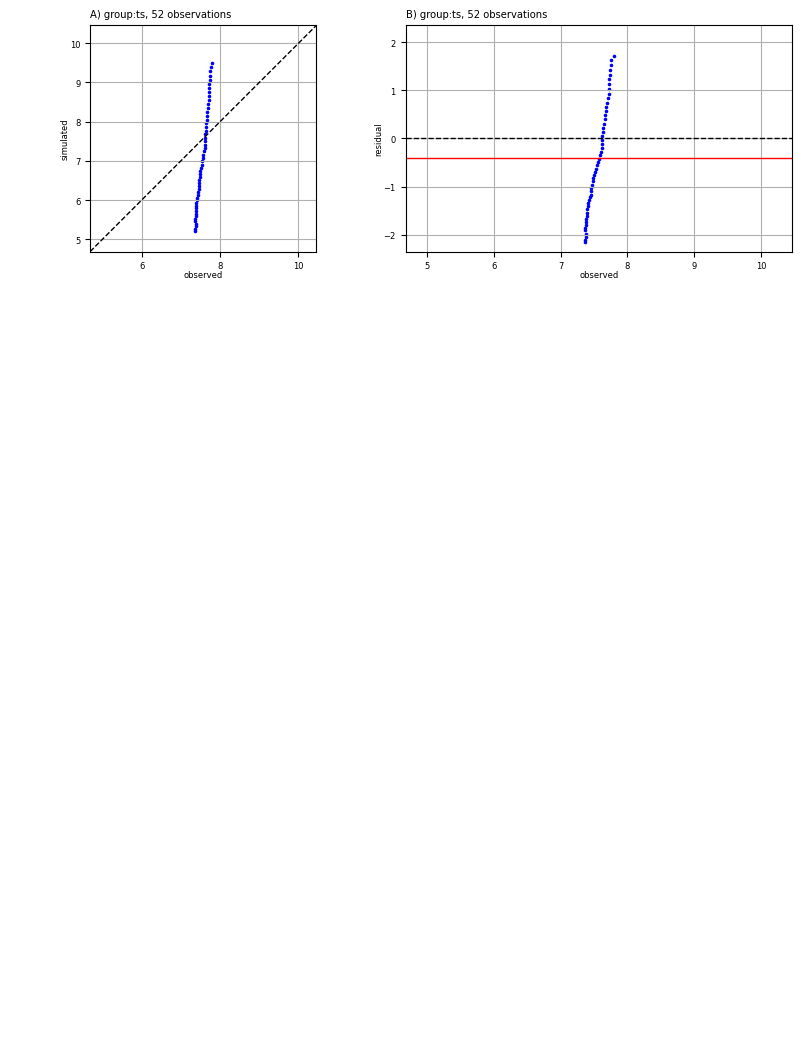

In [278]:
pst.plot('1to1')

## Phi

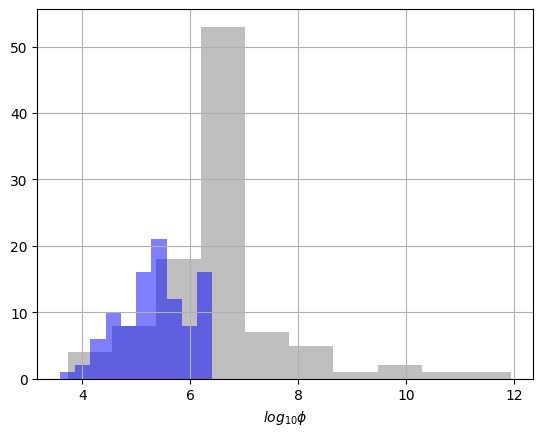

In [29]:
fig,ax = plt.subplots(1,1)
pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False) # prior grey
pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False) # posterior blue
_ = ax.set_xlabel("$log_{10}\\phi$")

reducing posterior ensemble from 100 to 90 realizations


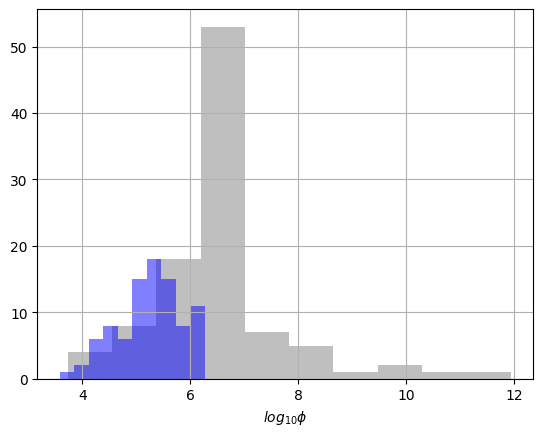

In [30]:
# threshold Phi
thres = phi.iloc[-1,6:].quantile(0.9)
# drop reals with Phi > thresh
pv = pt_oe.phi_vector
keep = pv.loc[pv<thres]
if keep.shape[0] != pv.shape[0]:
    print("reducing posterior ensemble from {0} to {1} realizations".format(pv.shape[0],keep.shape[0]))
    pt_oe = pt_oe.loc[keep.index,:]
    fig,ax = plt.subplots(1,1)
    pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False)
    pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False)
    _ = ax.set_xlabel("$log_{10}\\phi$")
else:
    print('No realizations dropped.')
if pt_oe.shape[0] == 0:
    print("filtered out all posterior realization #sad")

## Obs

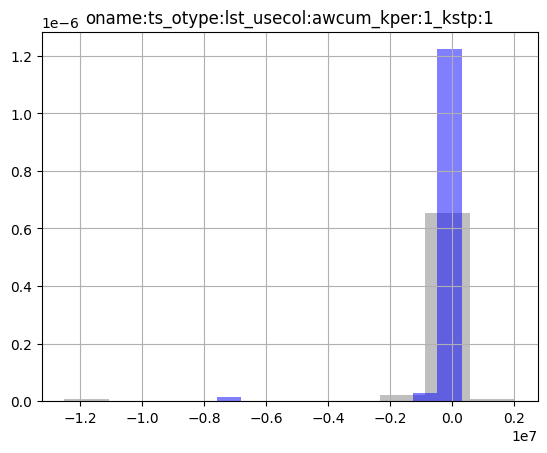

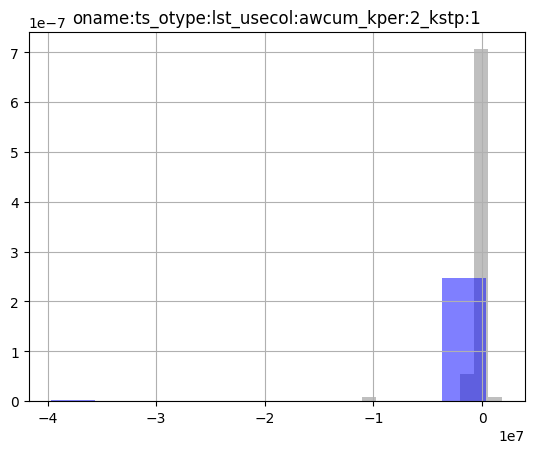

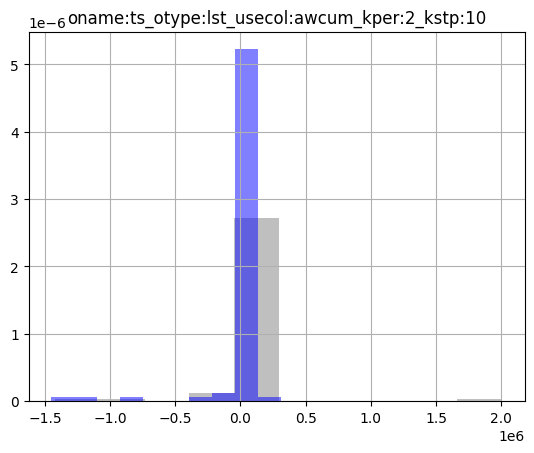

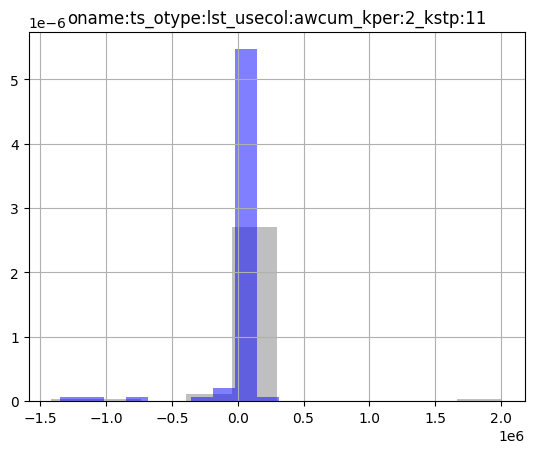

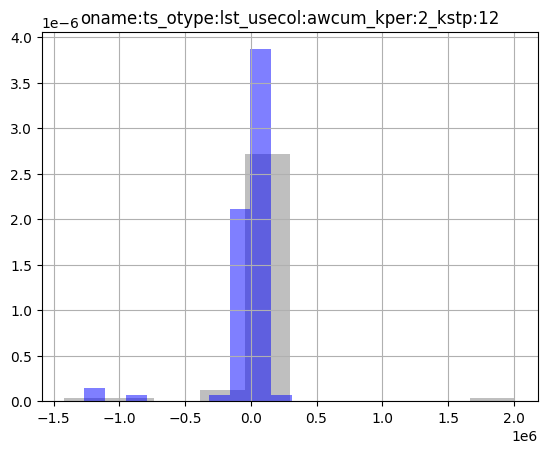

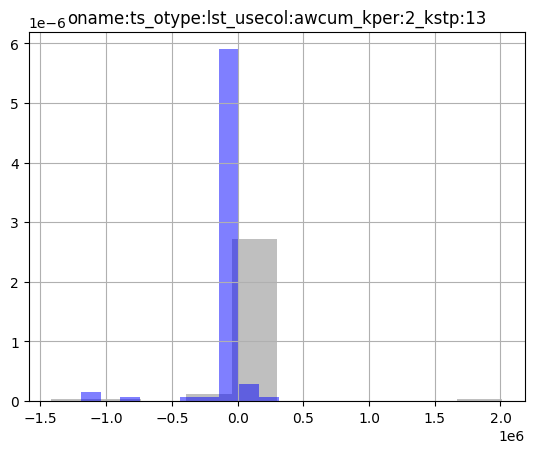

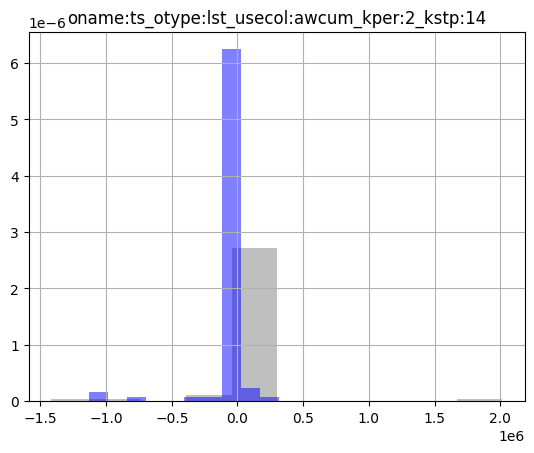

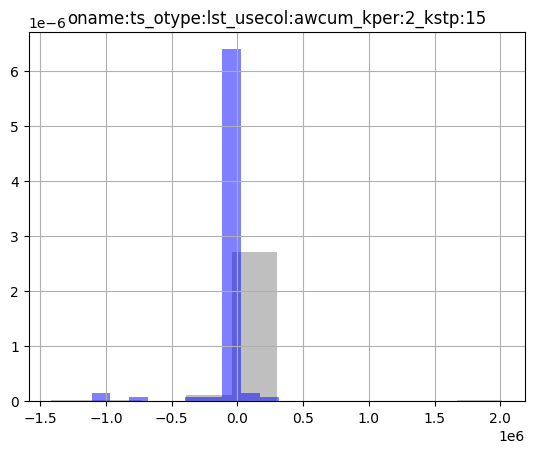

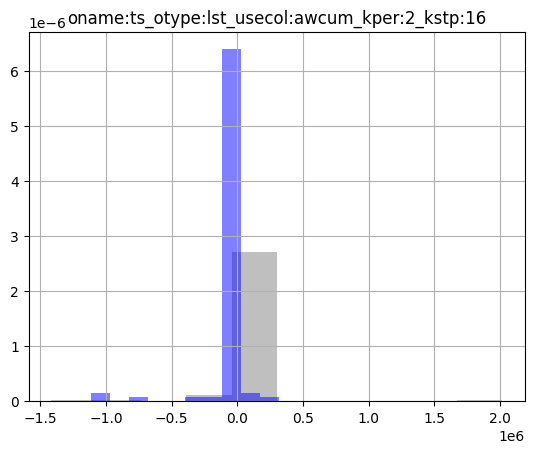

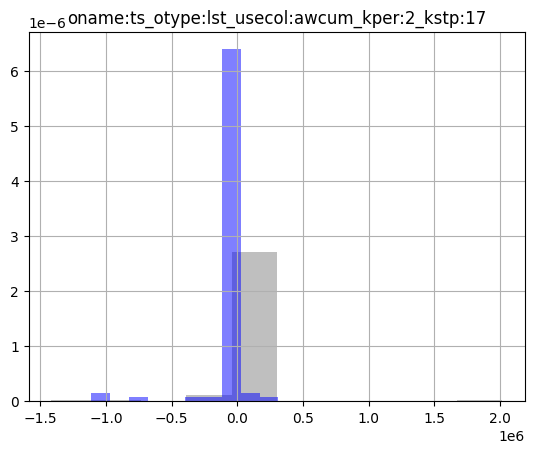

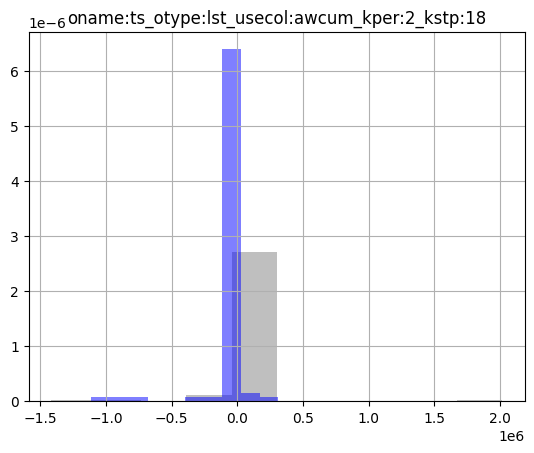

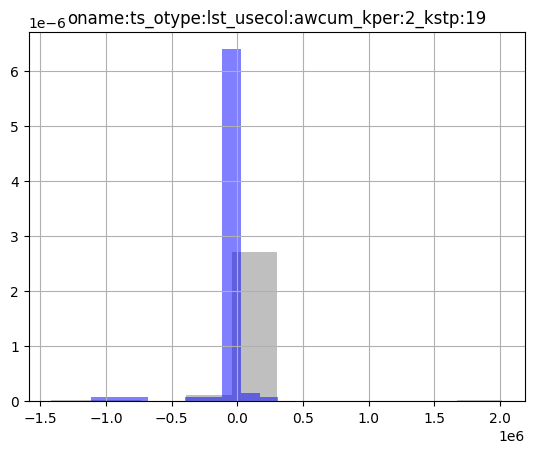

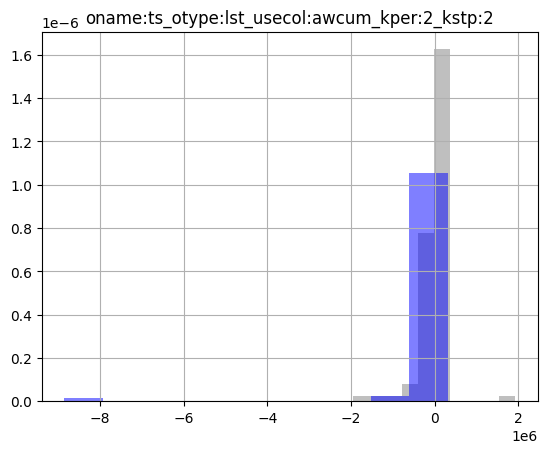

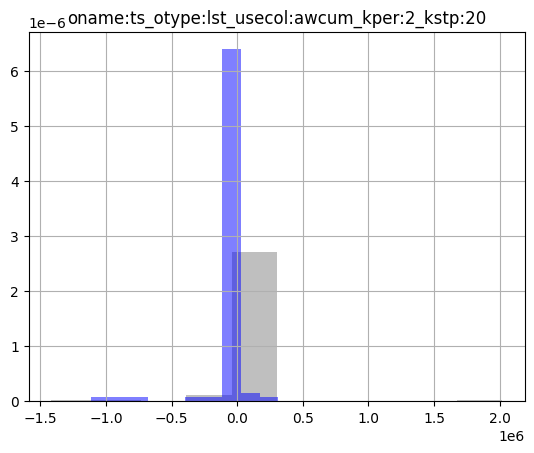

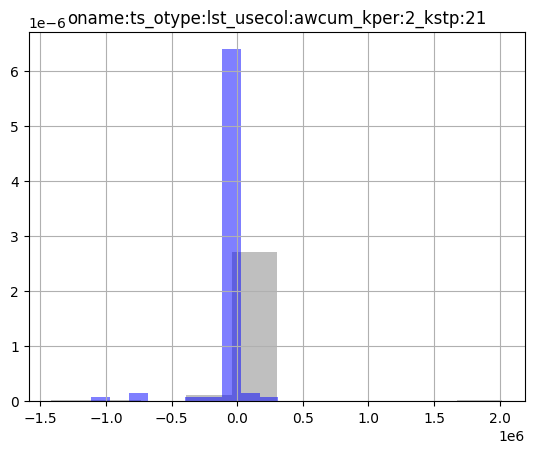

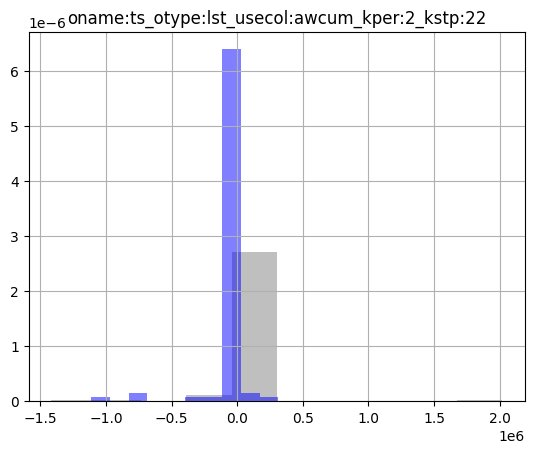

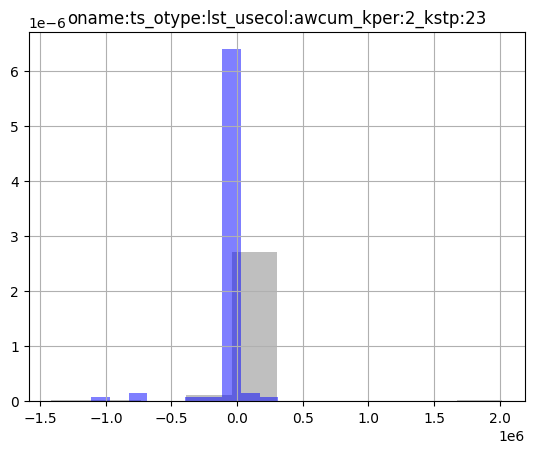

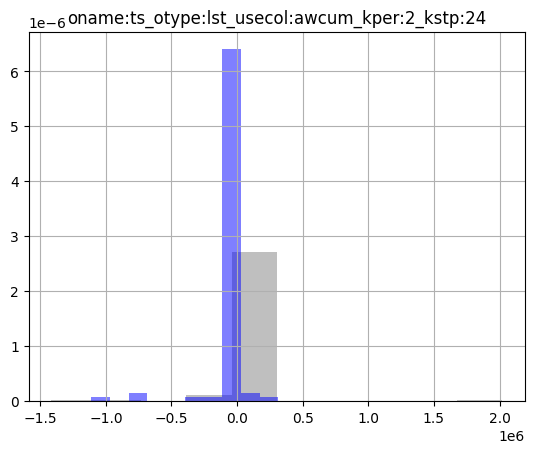

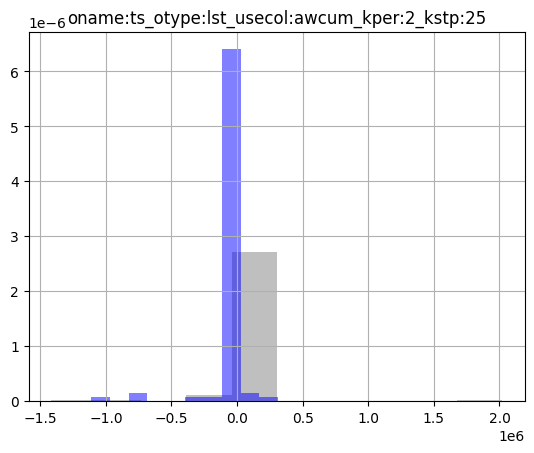

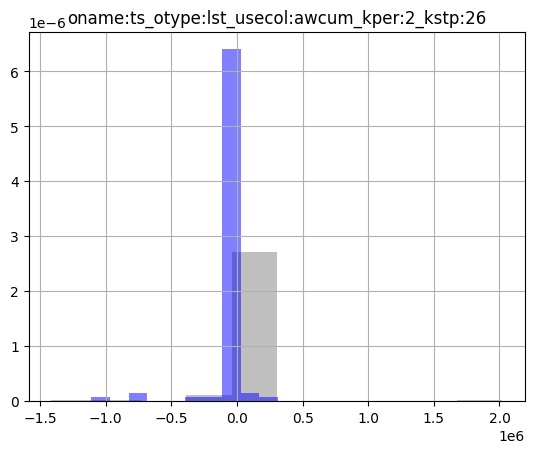

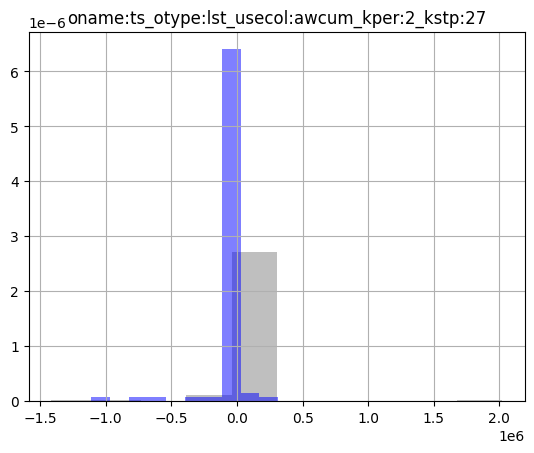

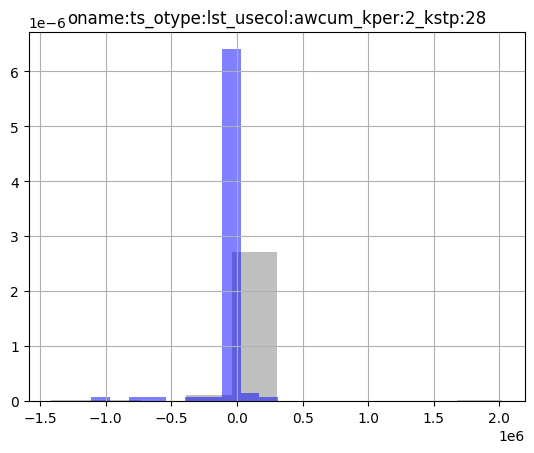

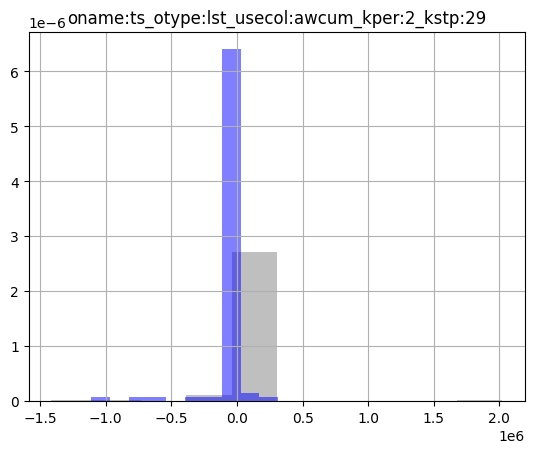

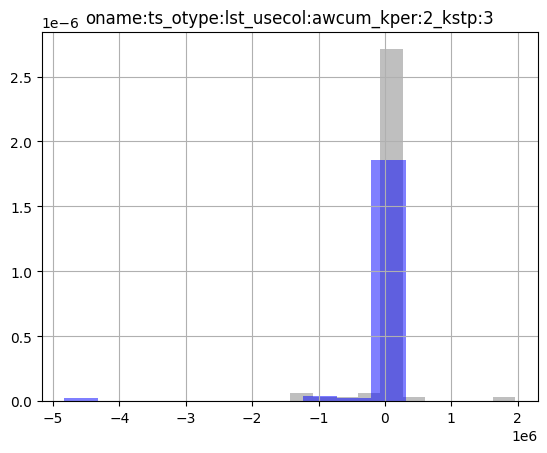

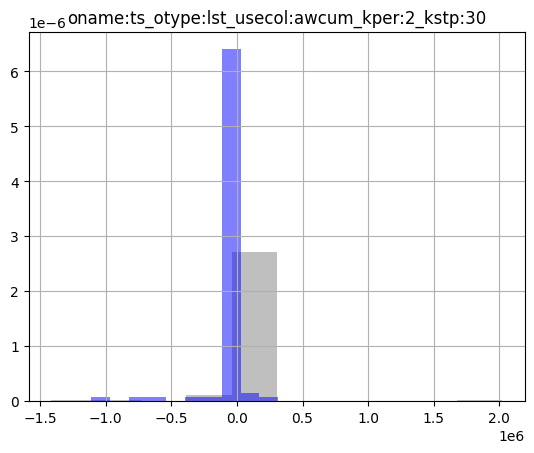

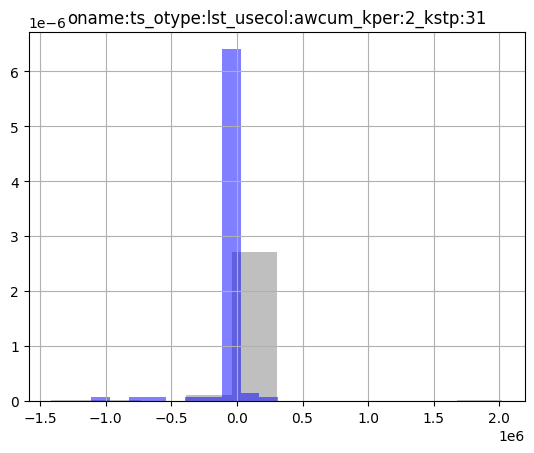

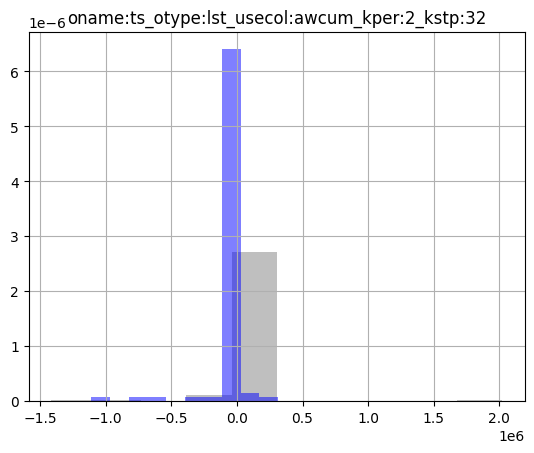

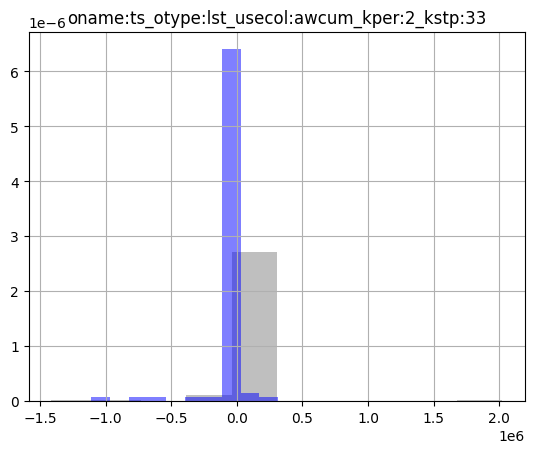

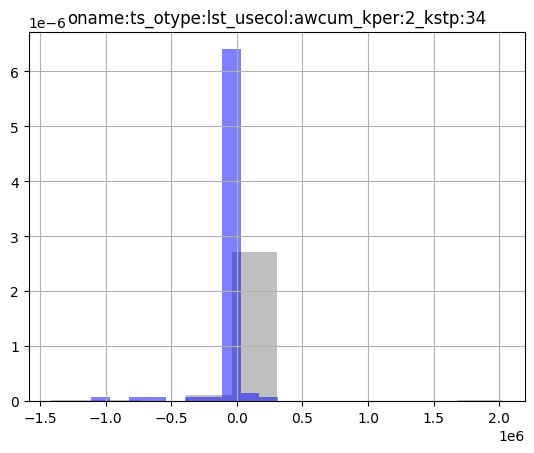

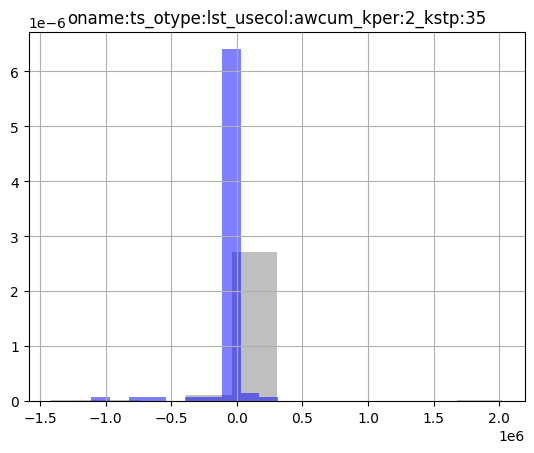

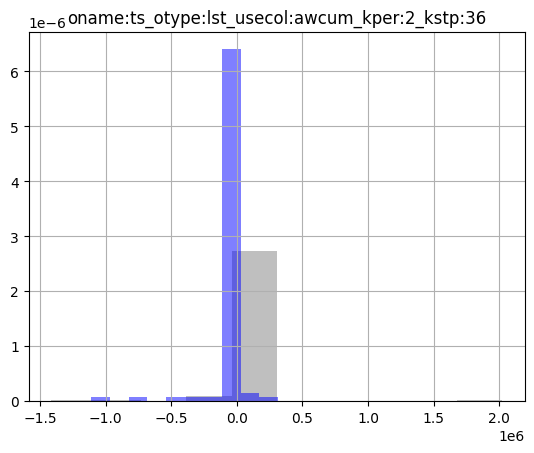

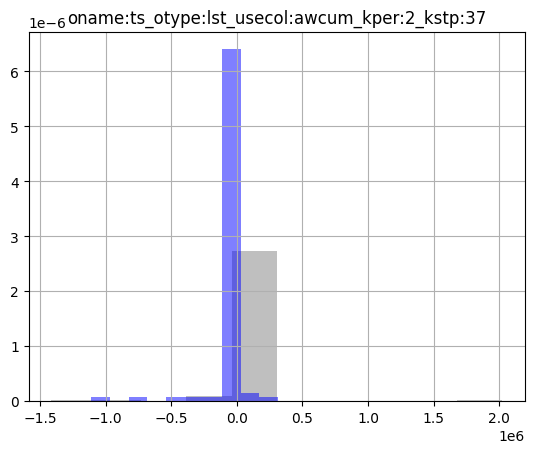

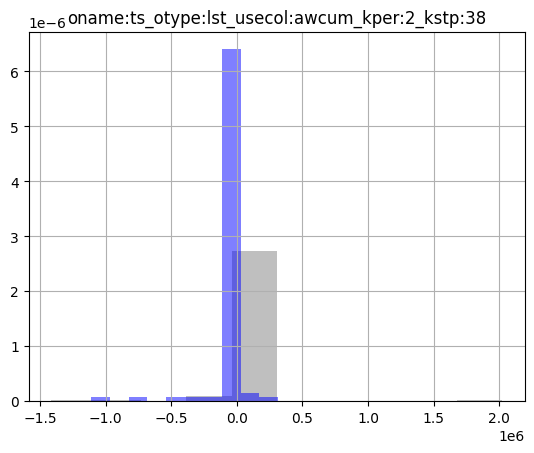

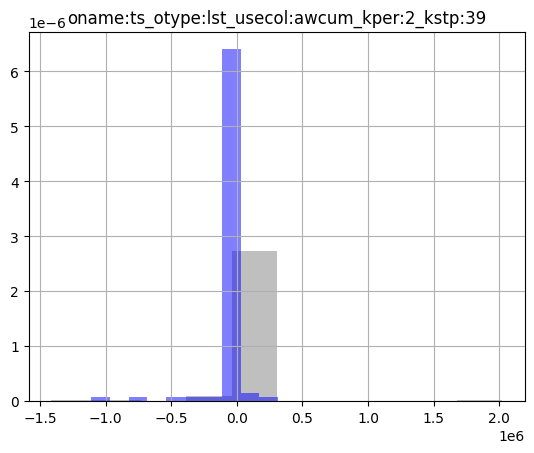

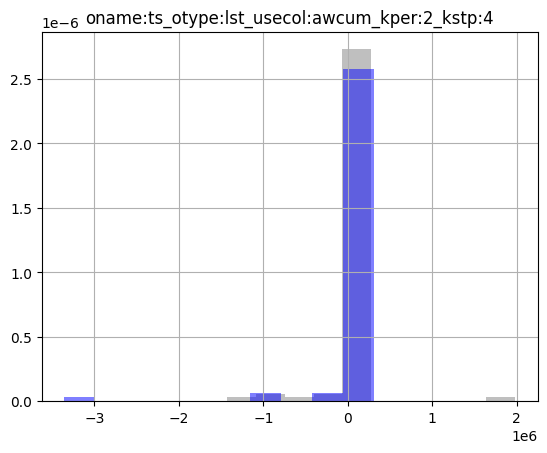

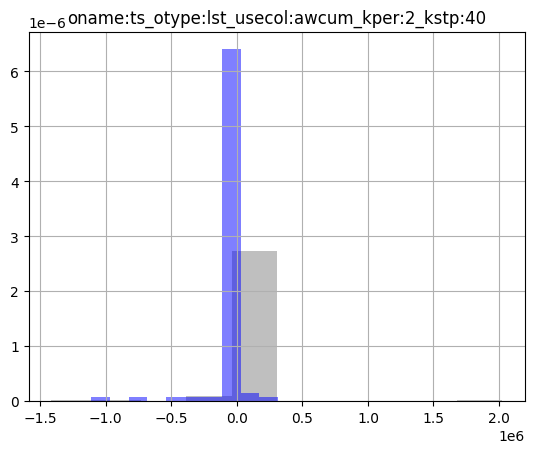

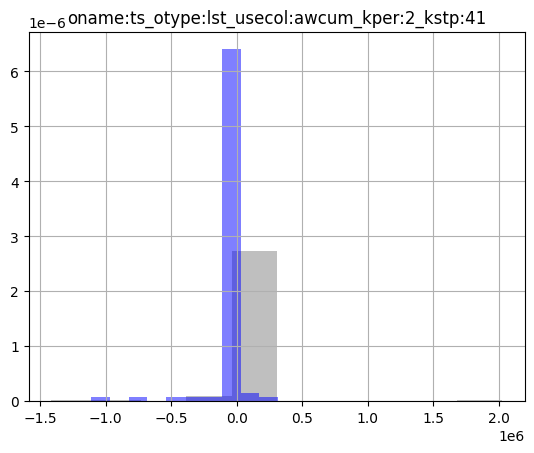

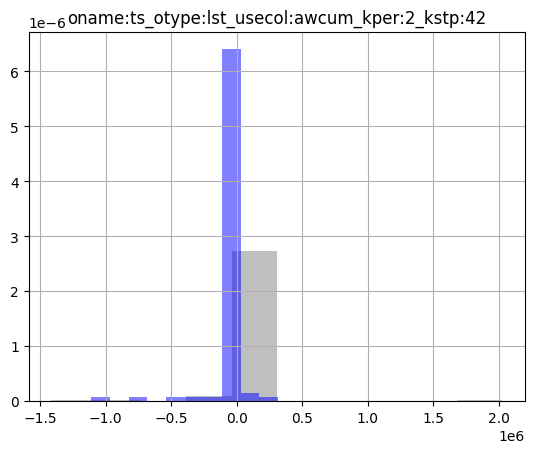

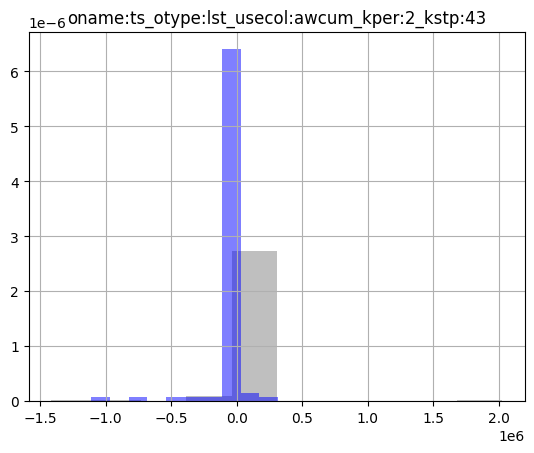

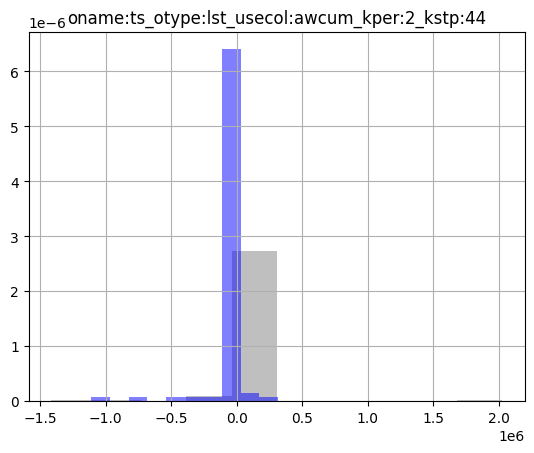

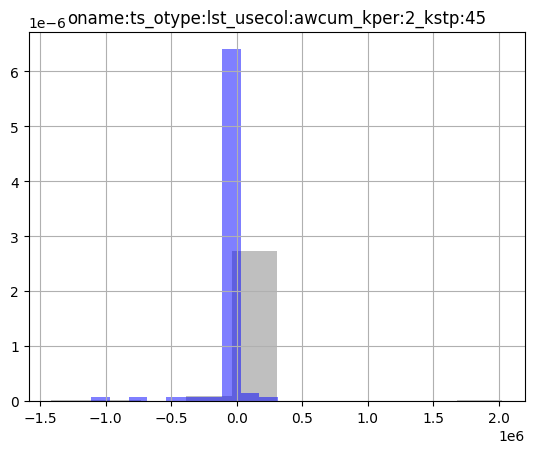

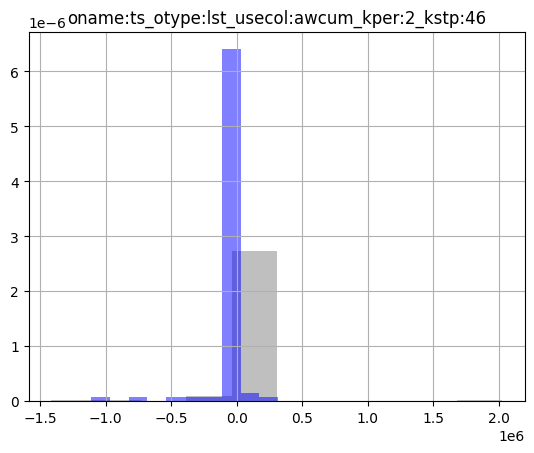

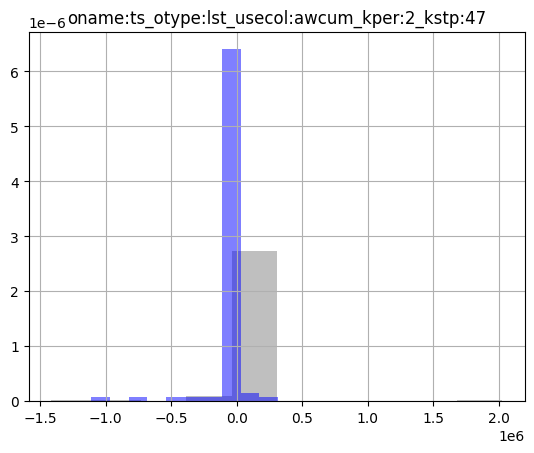

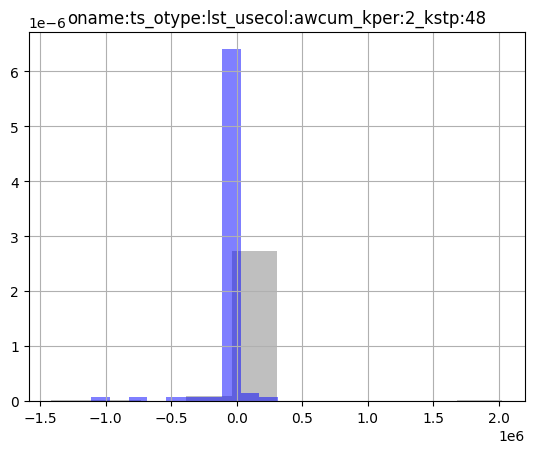

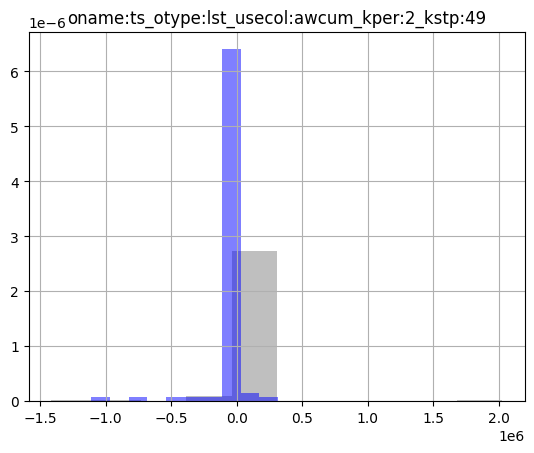

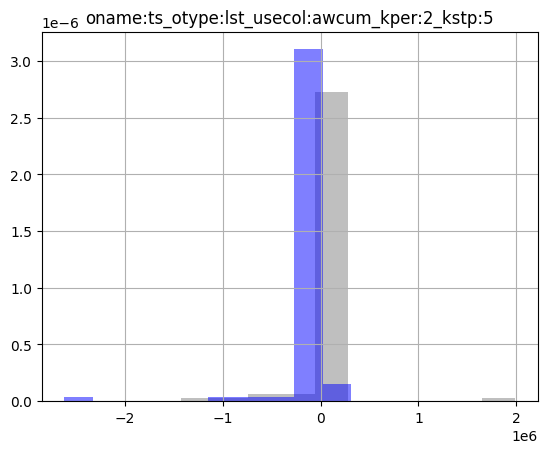

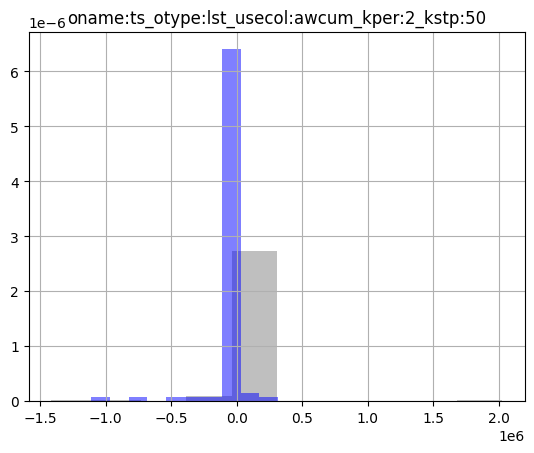

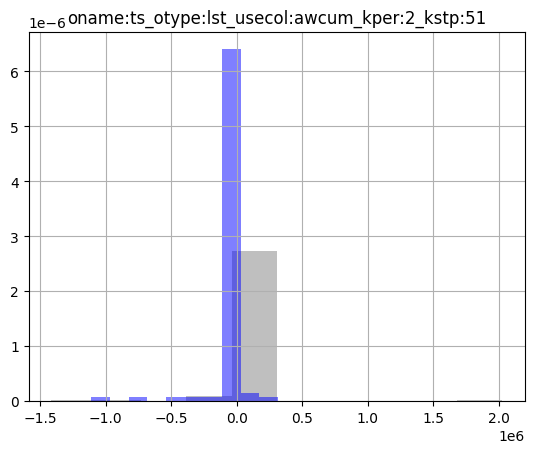

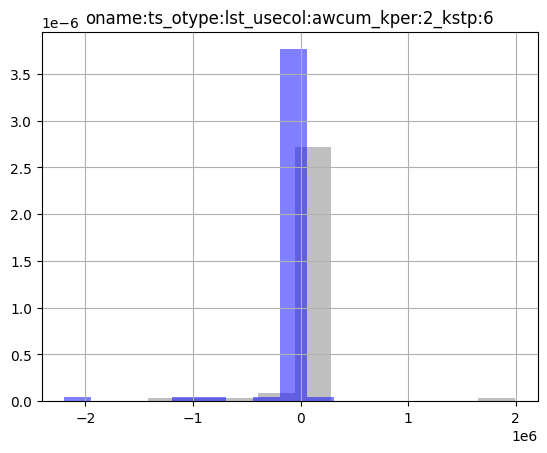

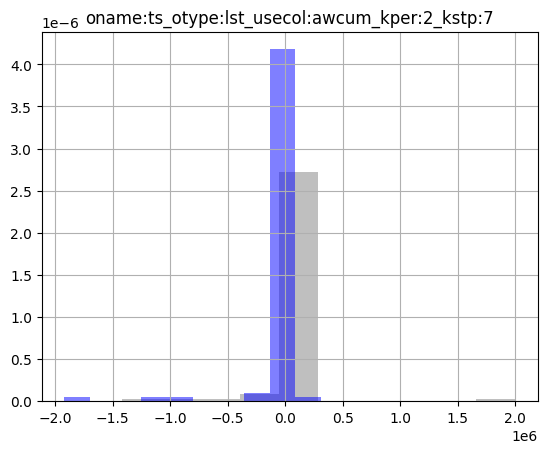

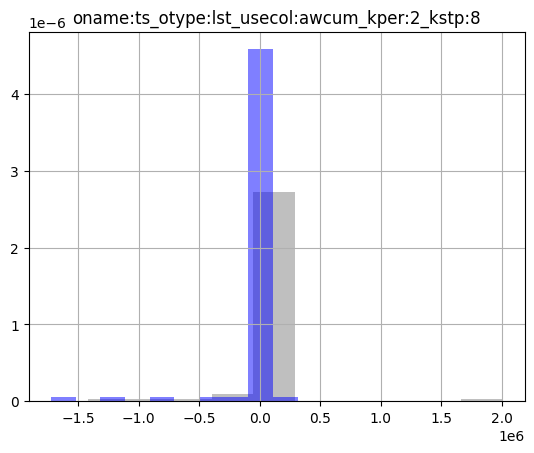

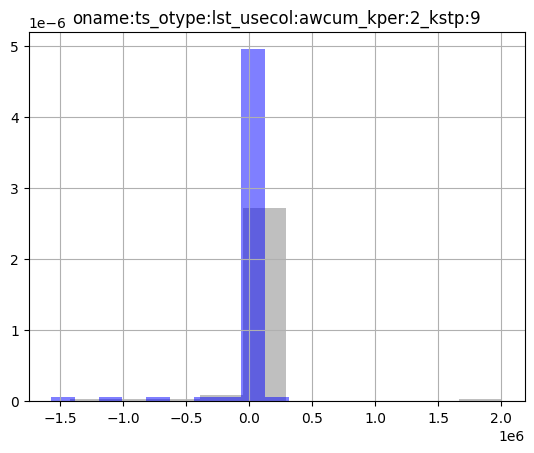

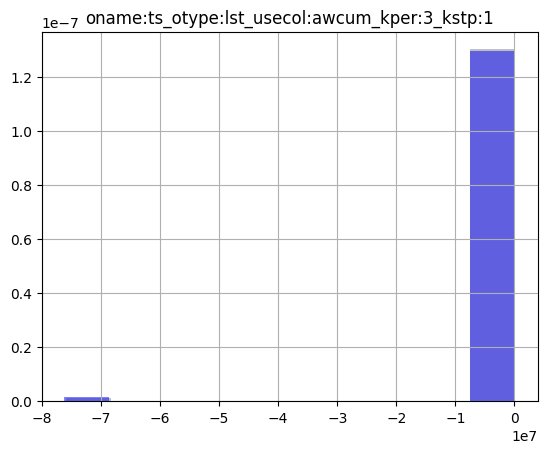

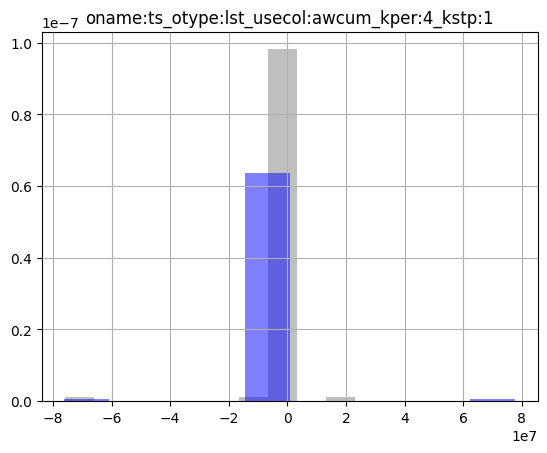

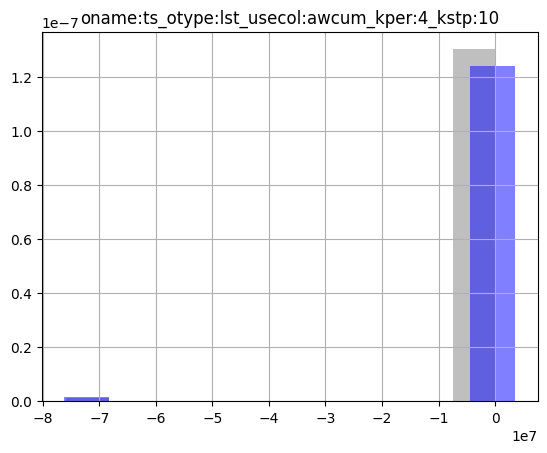

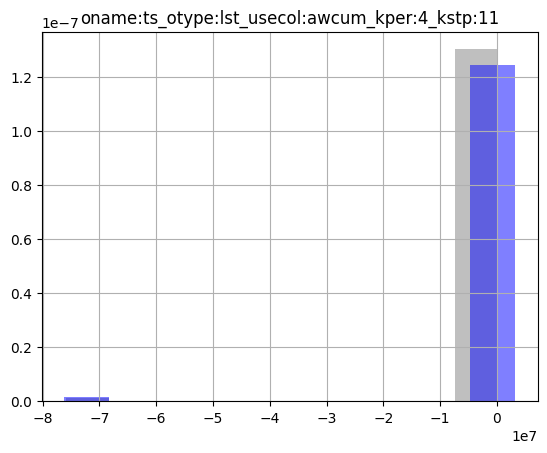

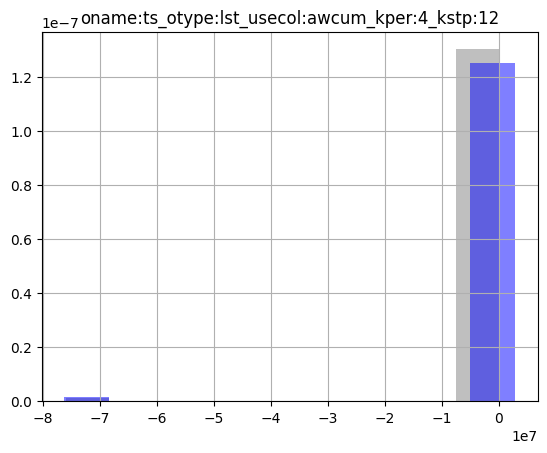

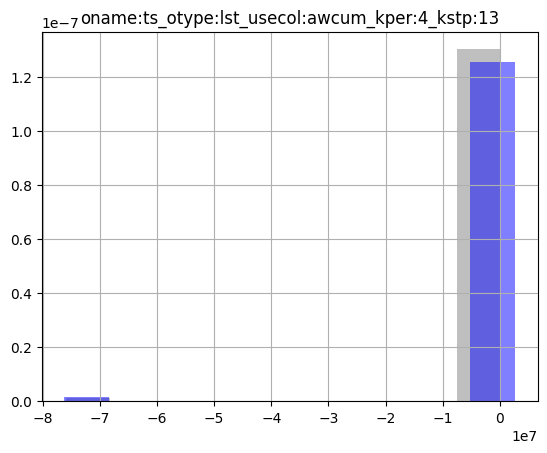

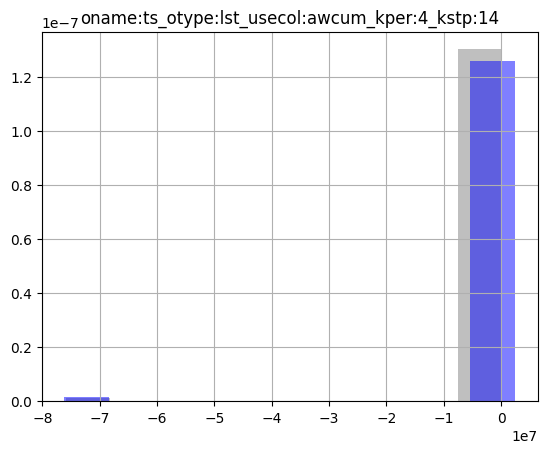

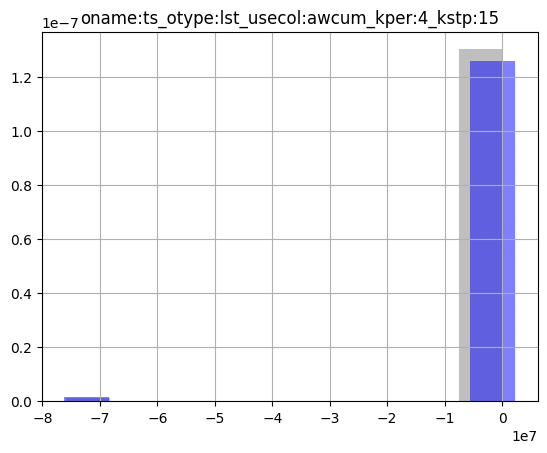

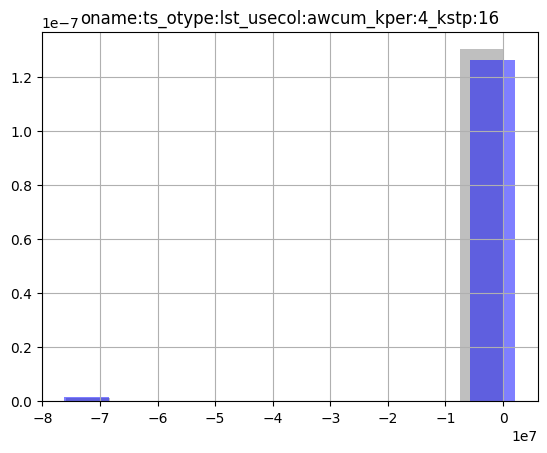

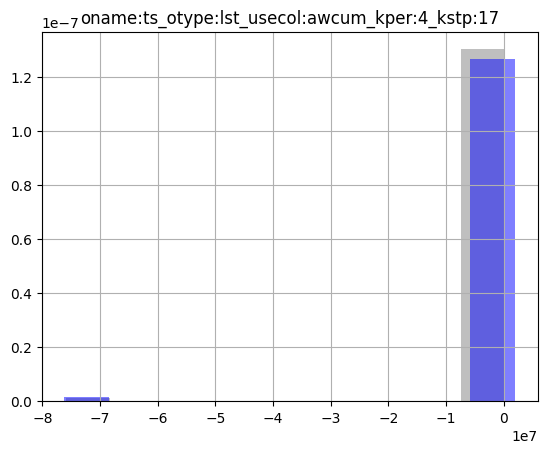

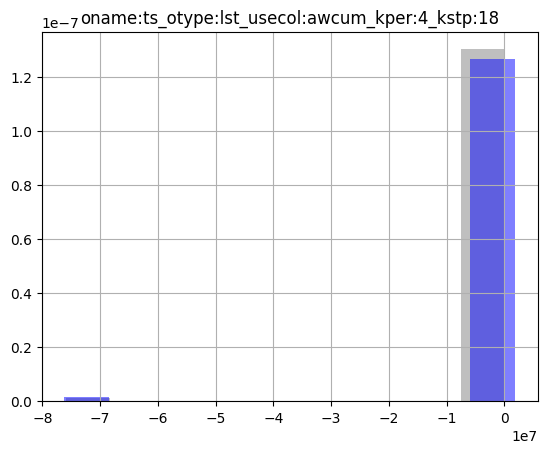

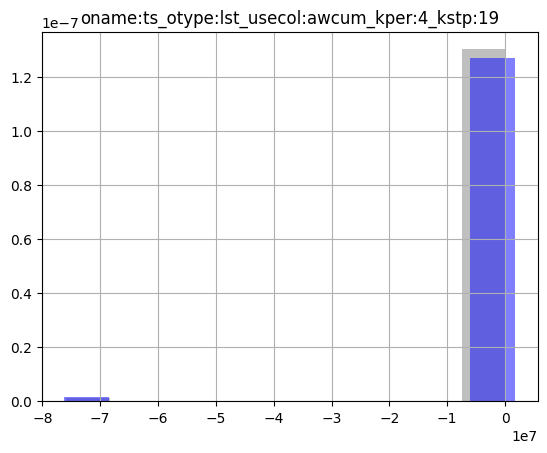

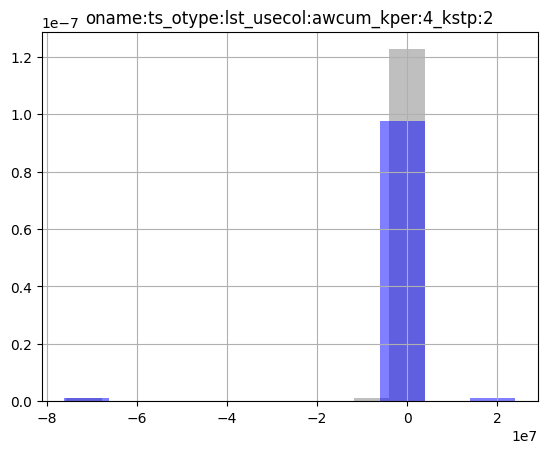

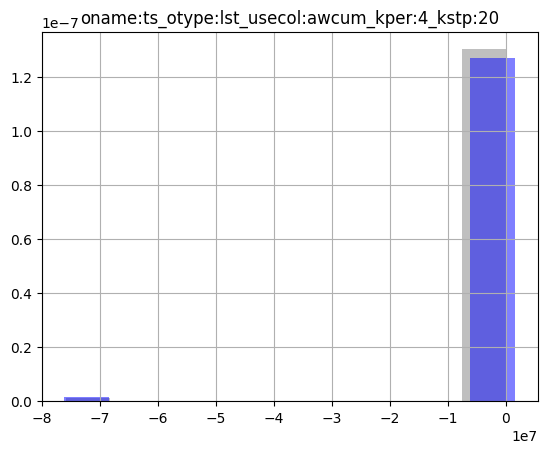

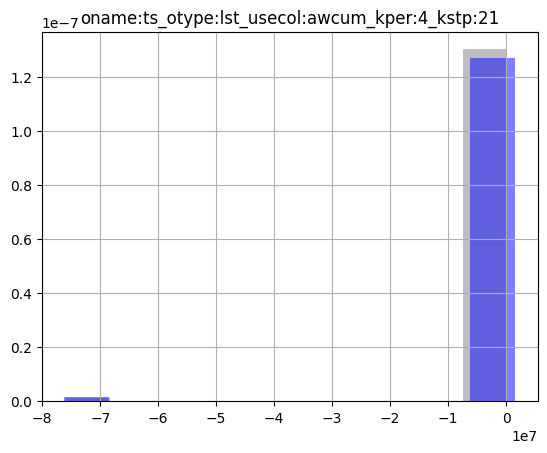

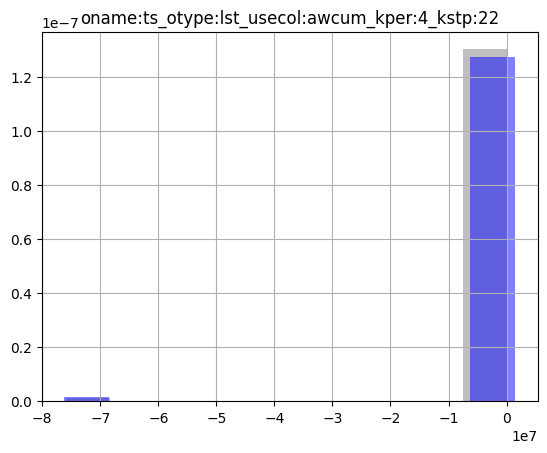

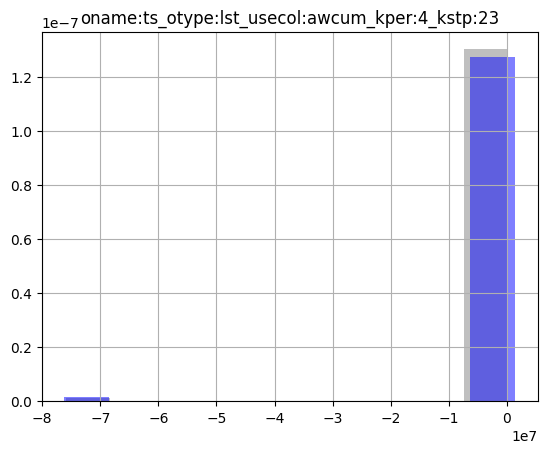

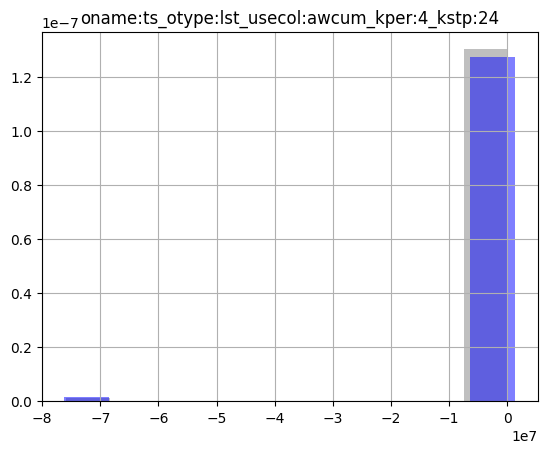

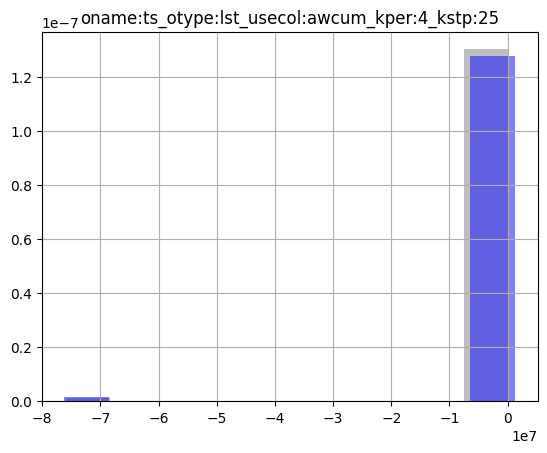

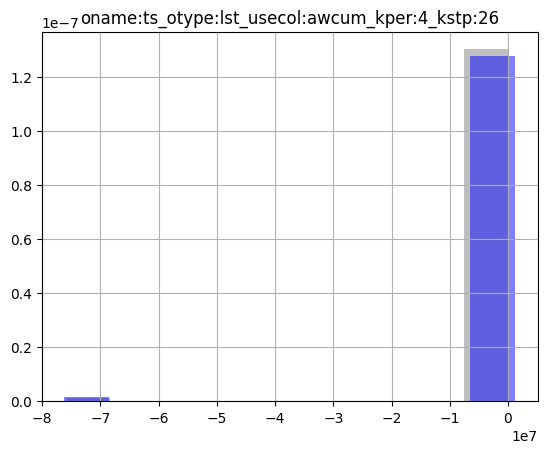

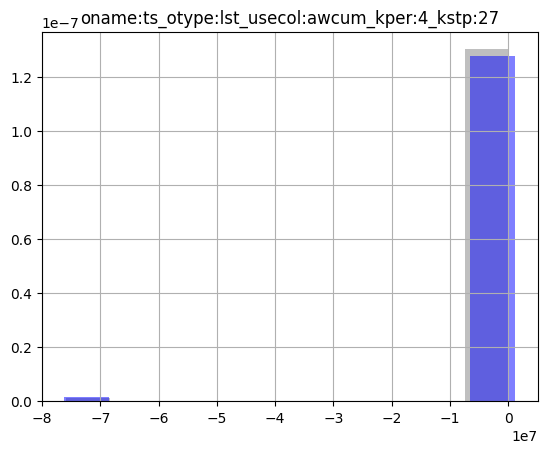

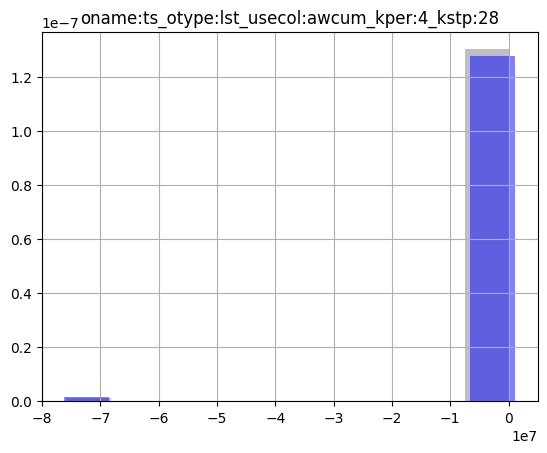

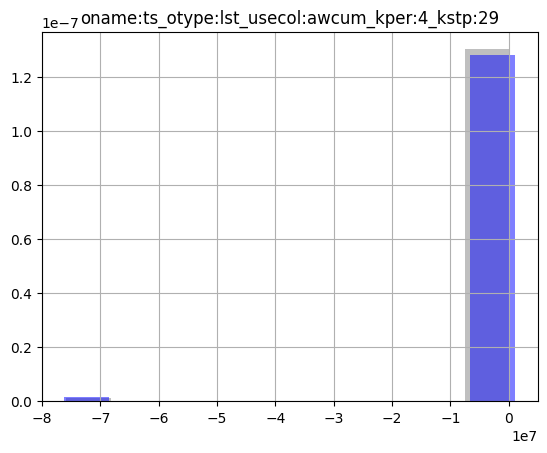

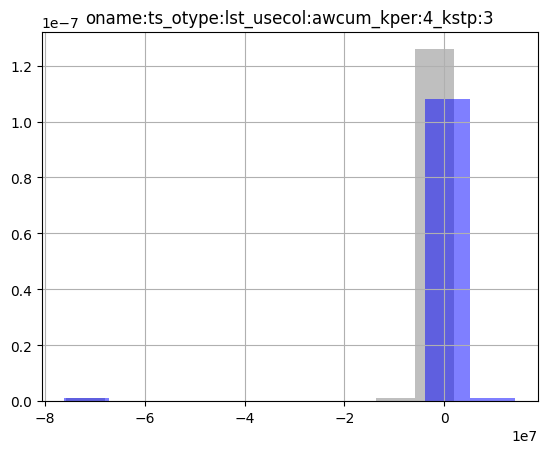

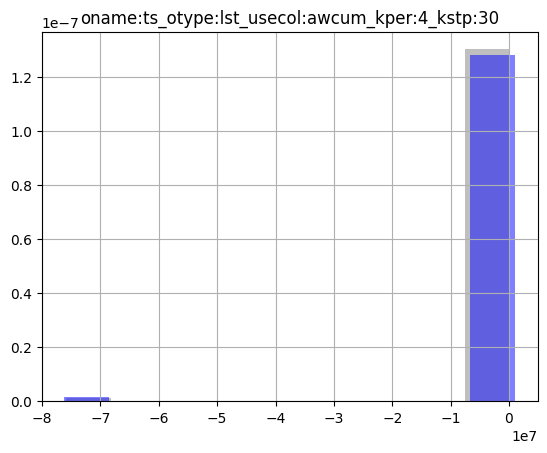

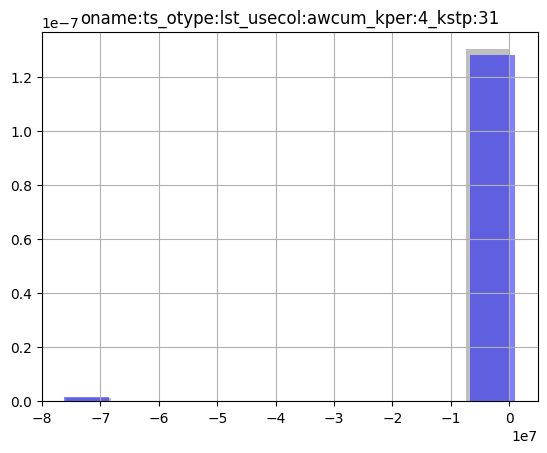

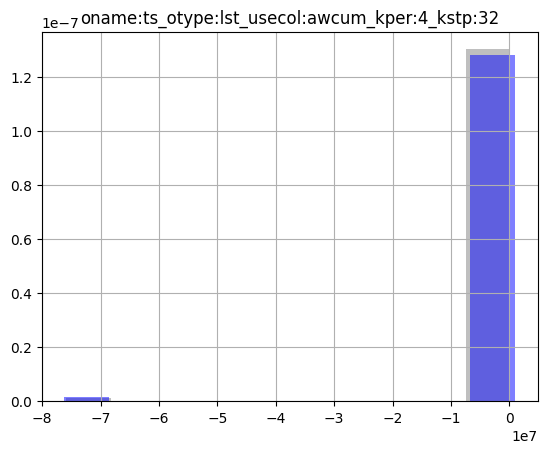

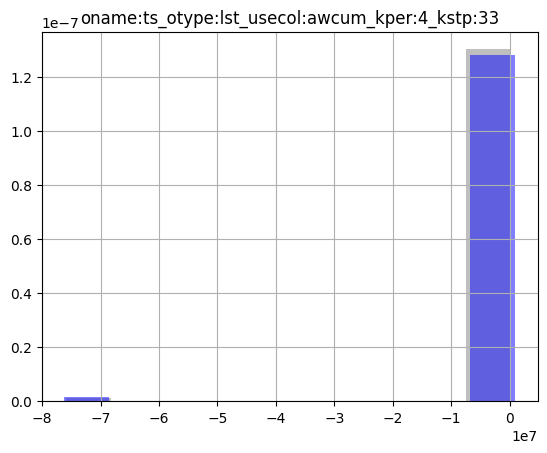

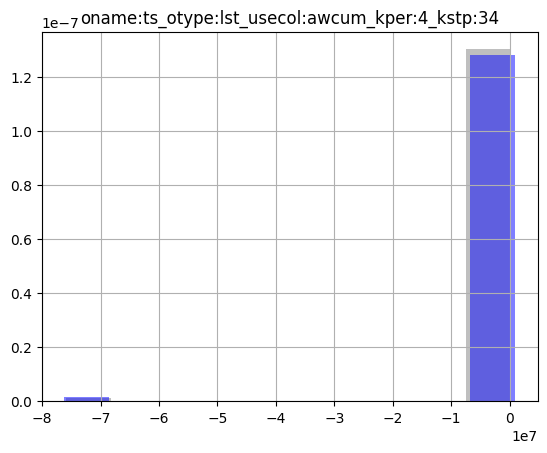

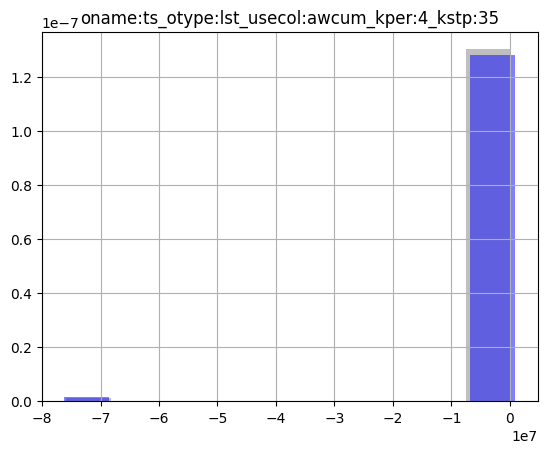

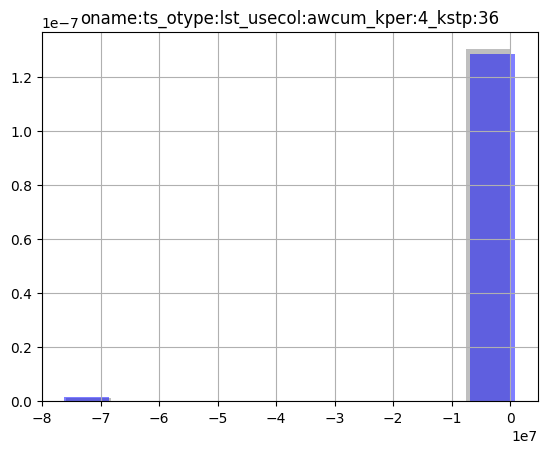

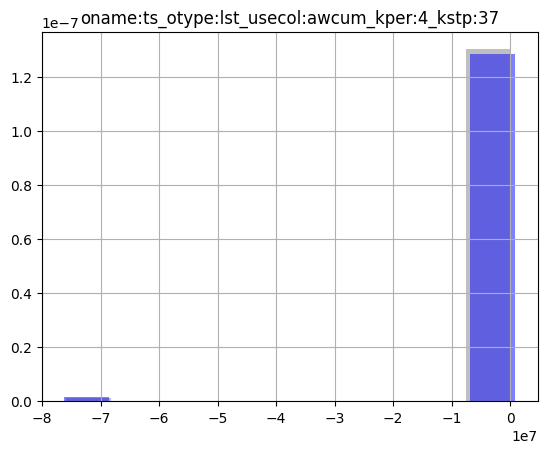

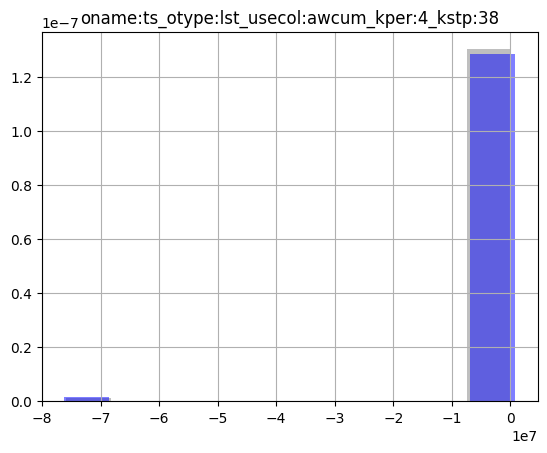

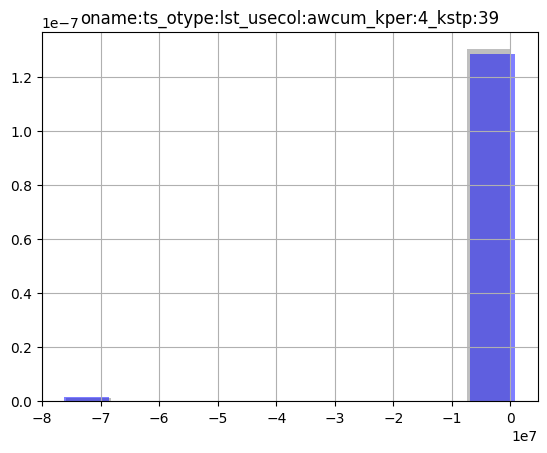

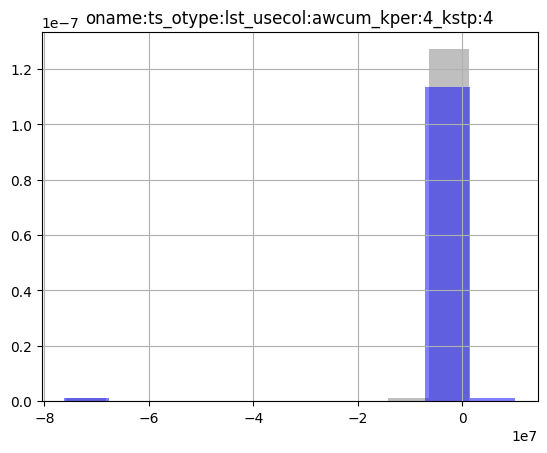

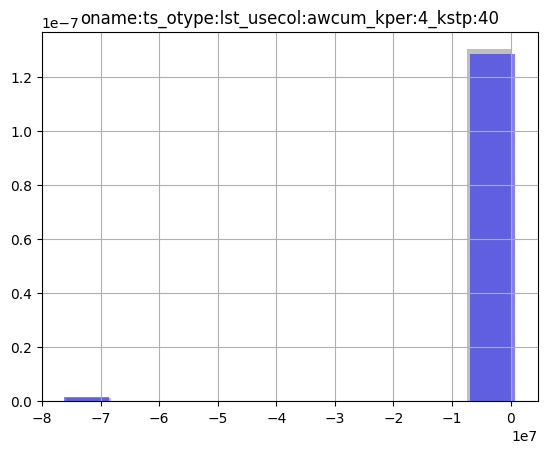

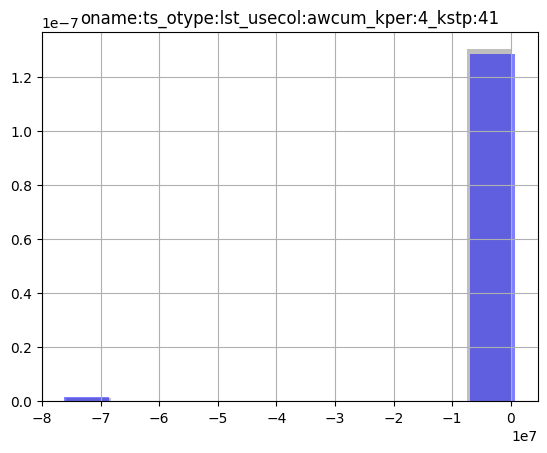

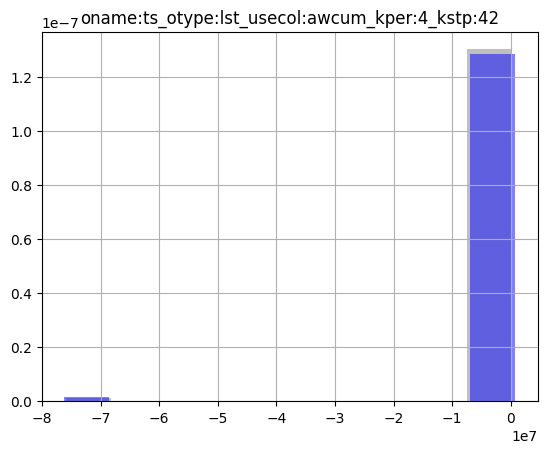

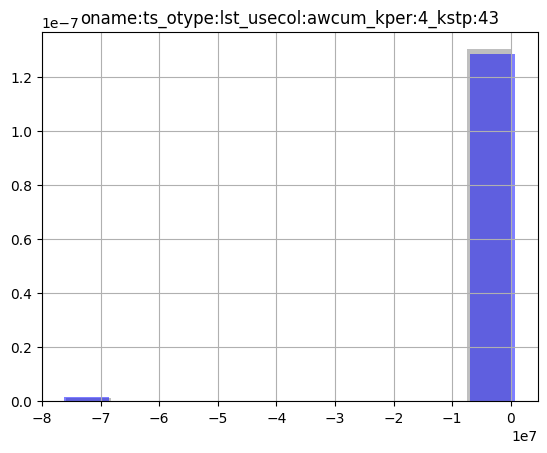

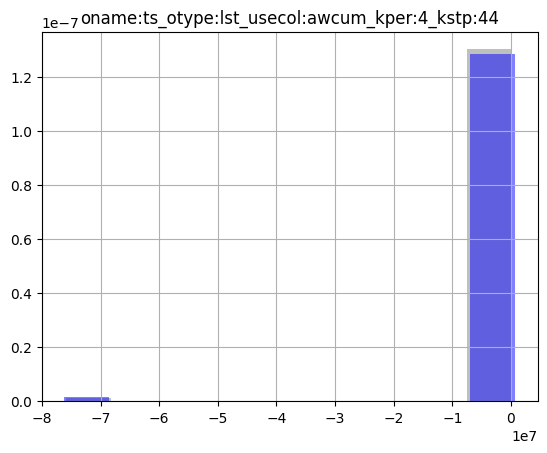

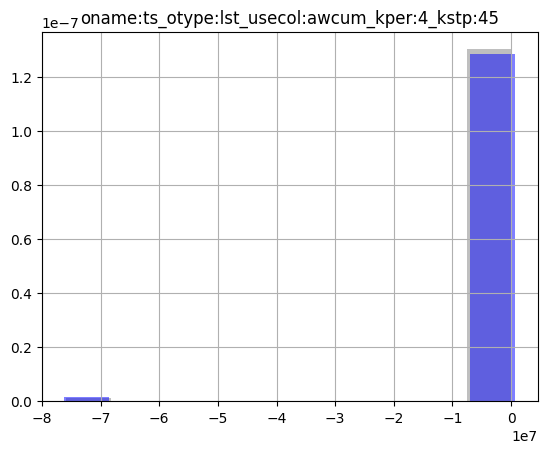

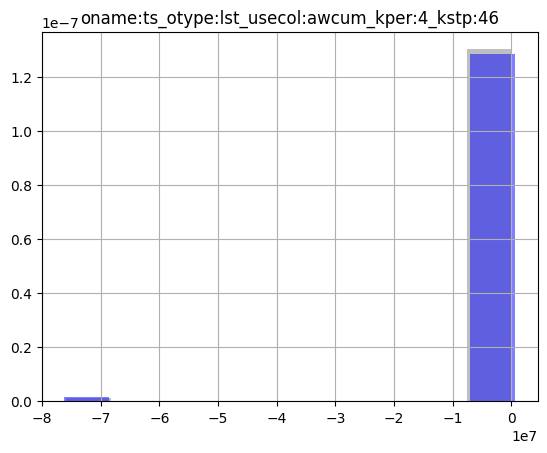

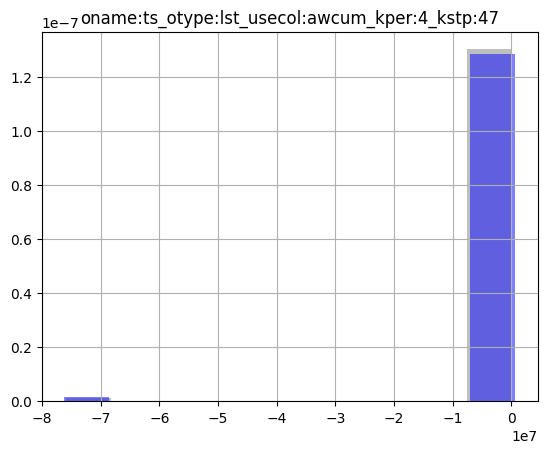

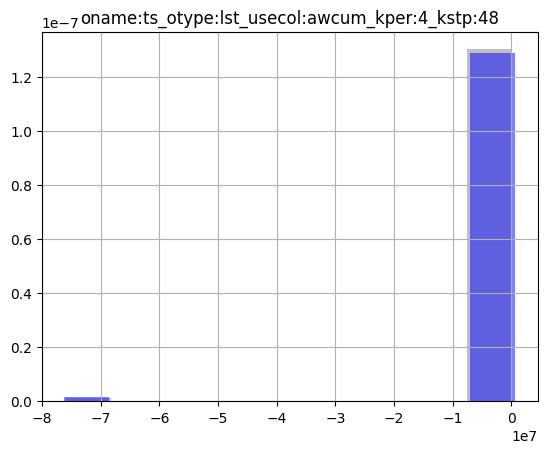

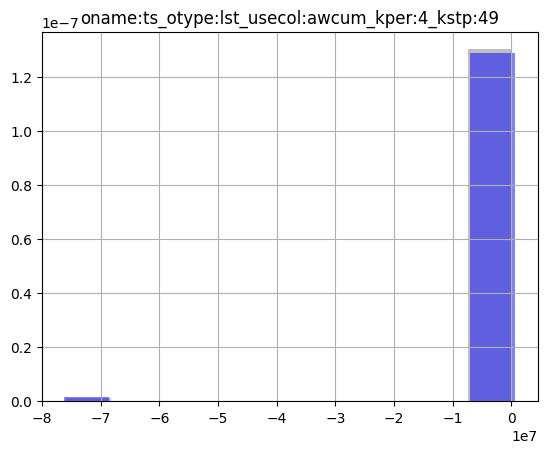

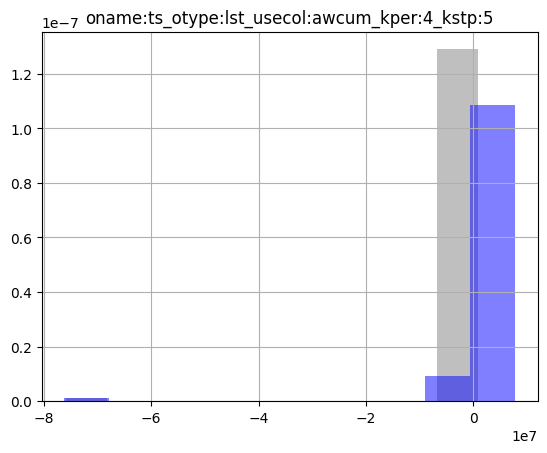

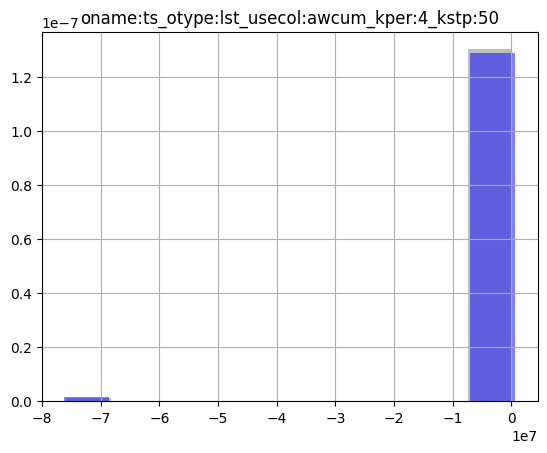

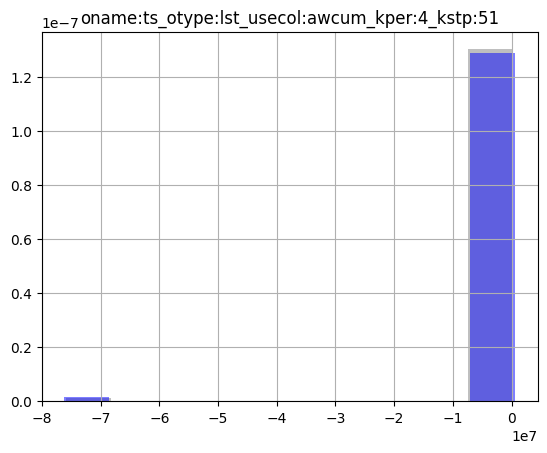

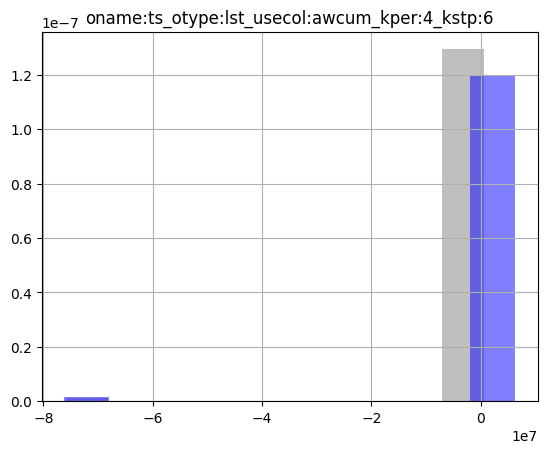

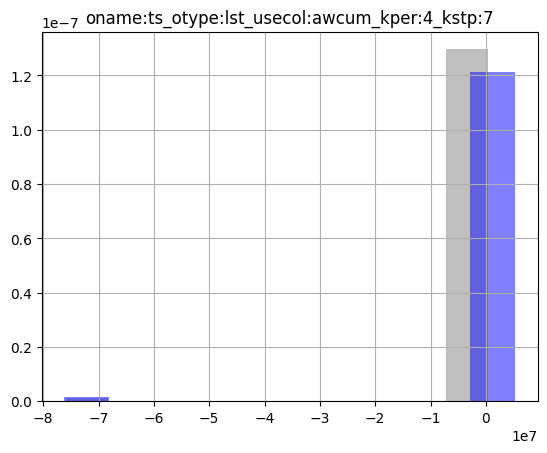

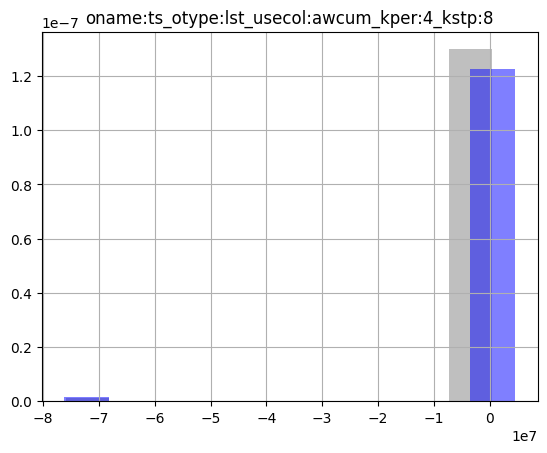

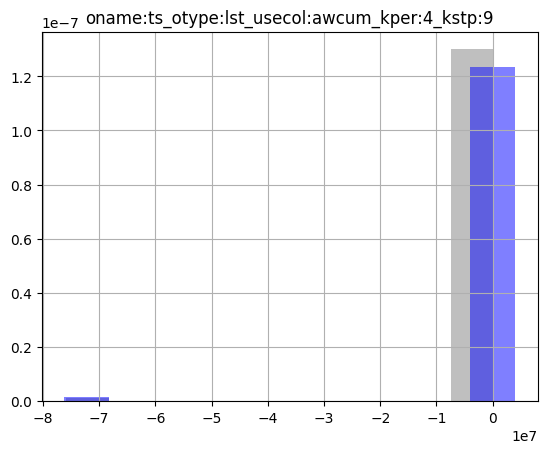

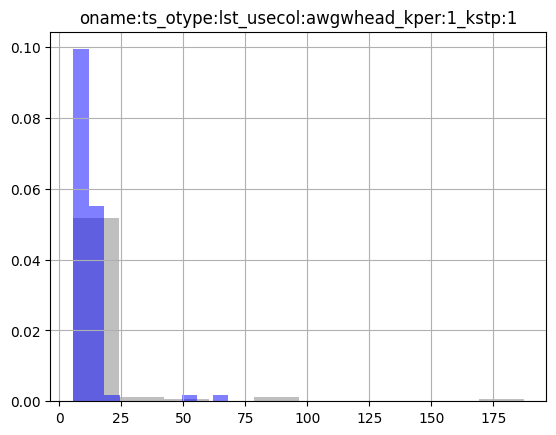

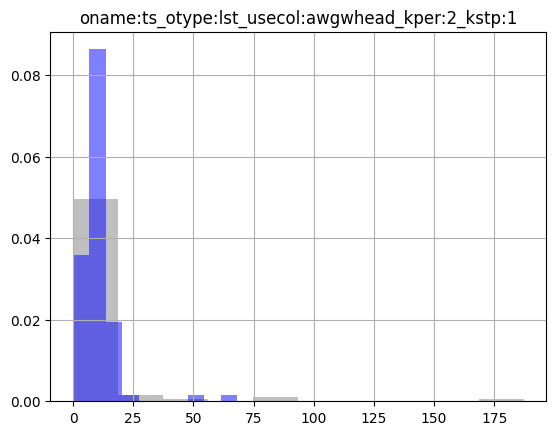

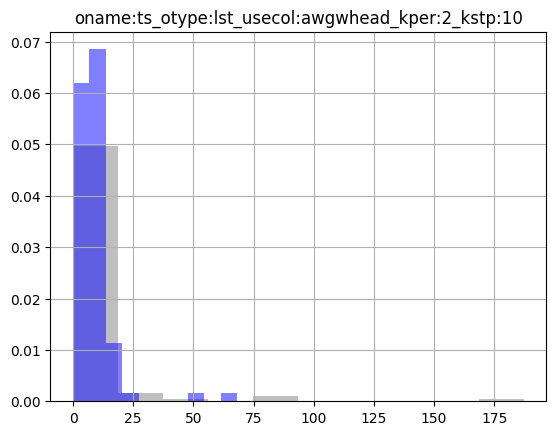

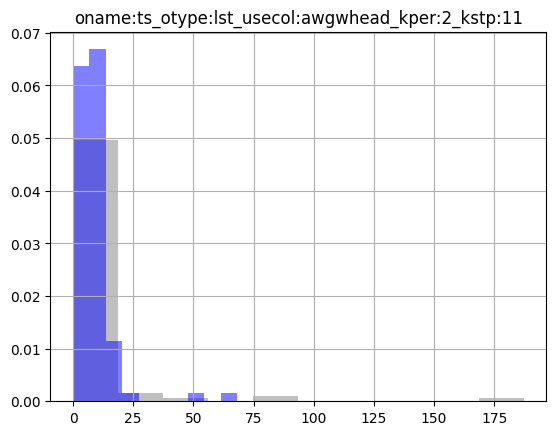

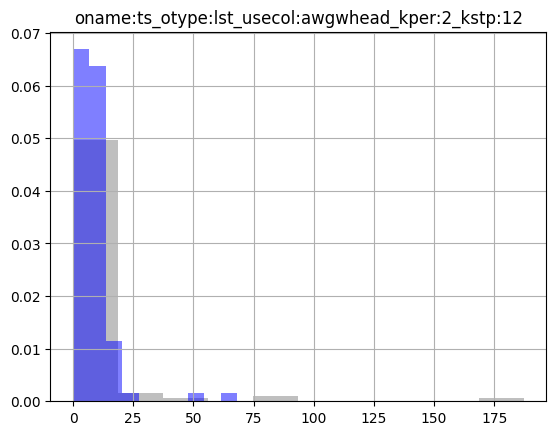

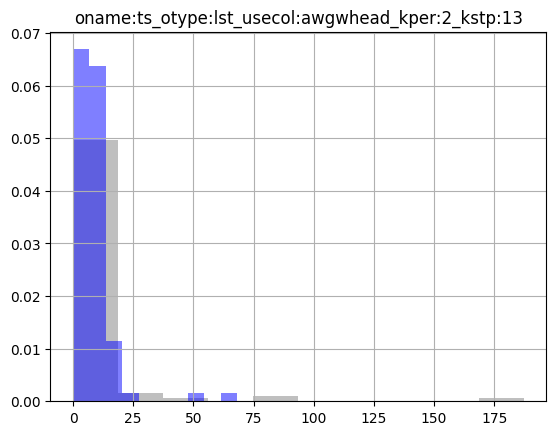

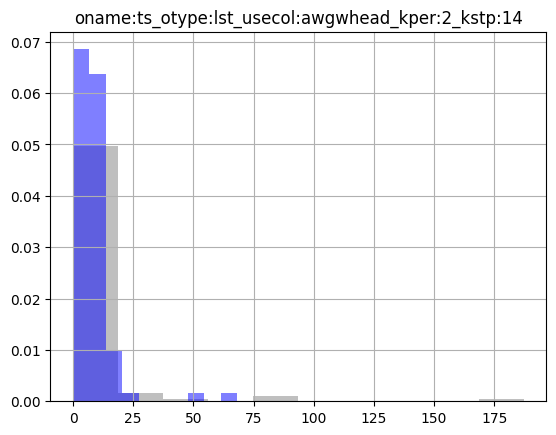

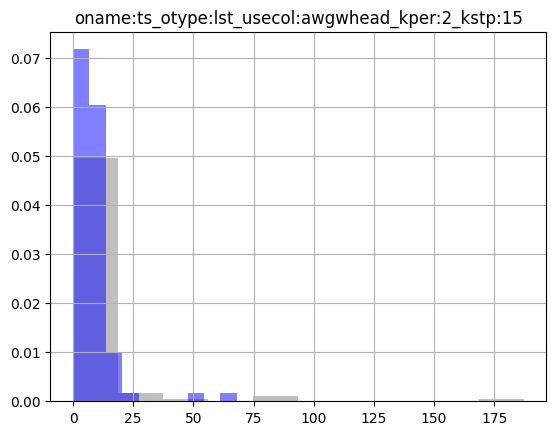

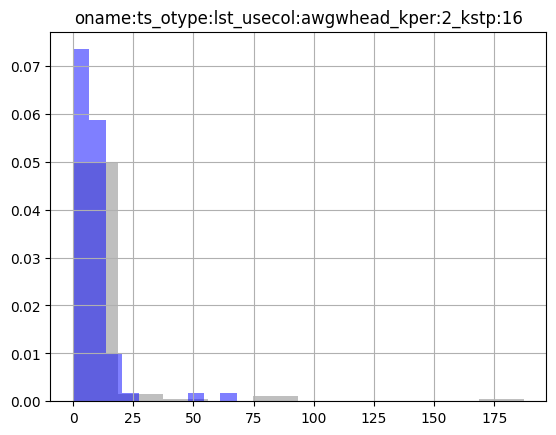

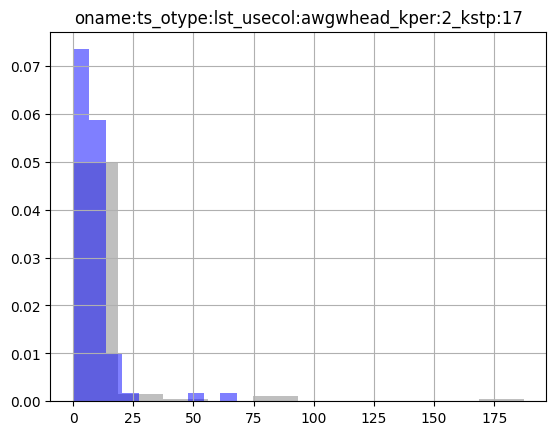

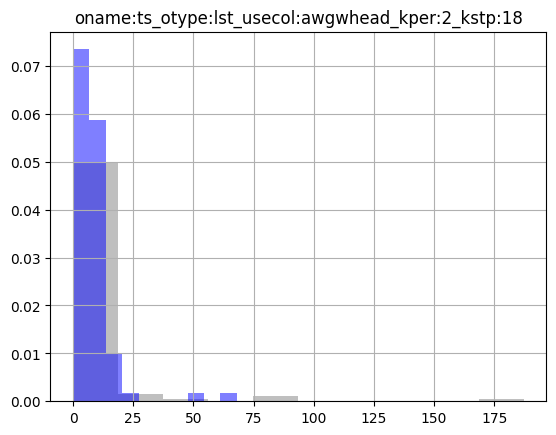

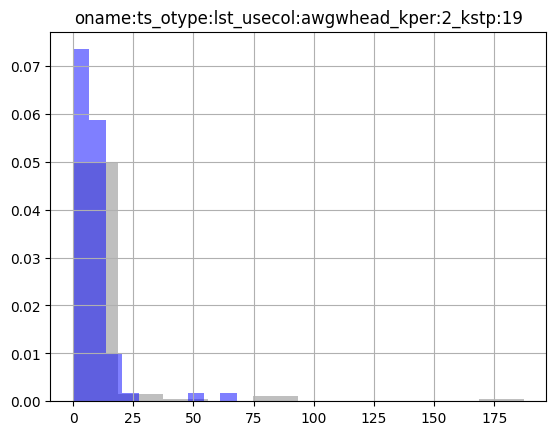

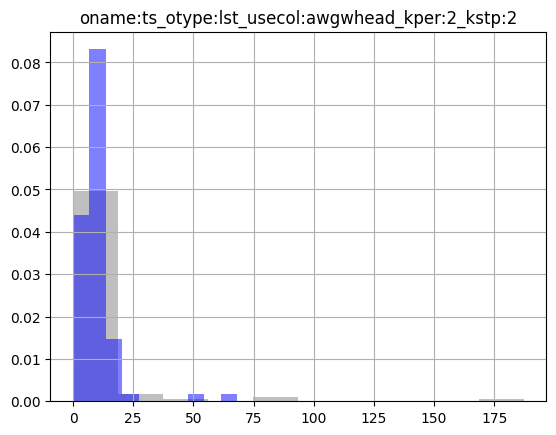

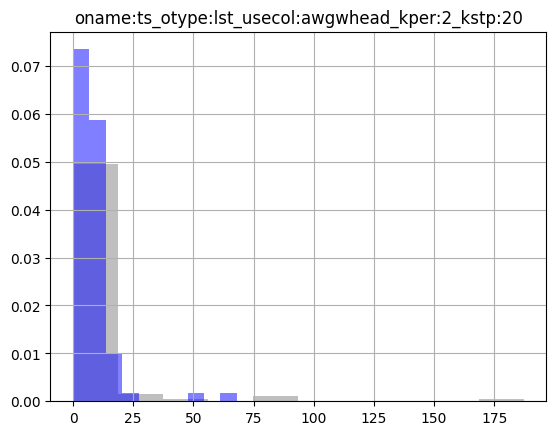

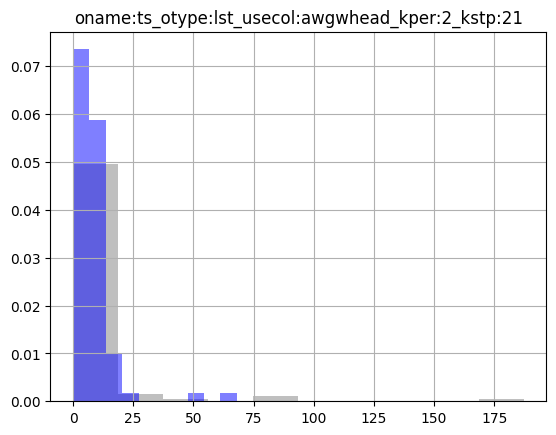

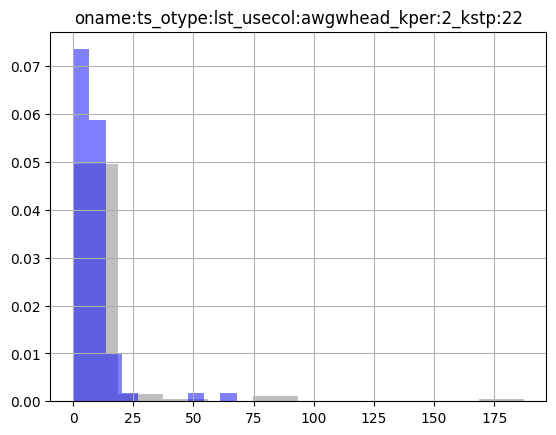

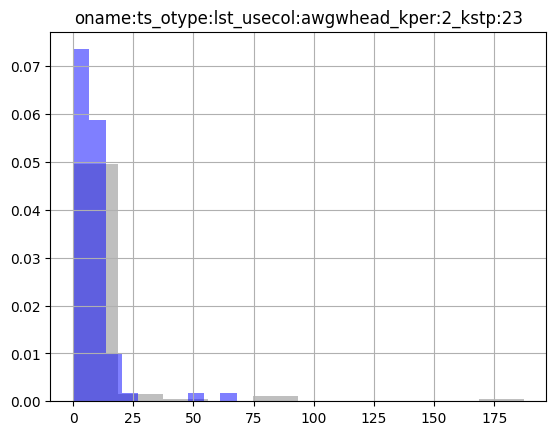

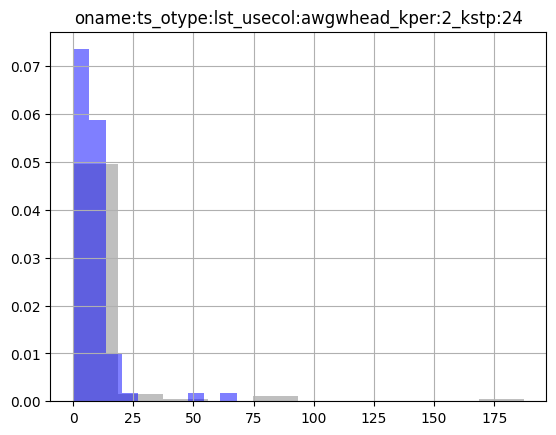

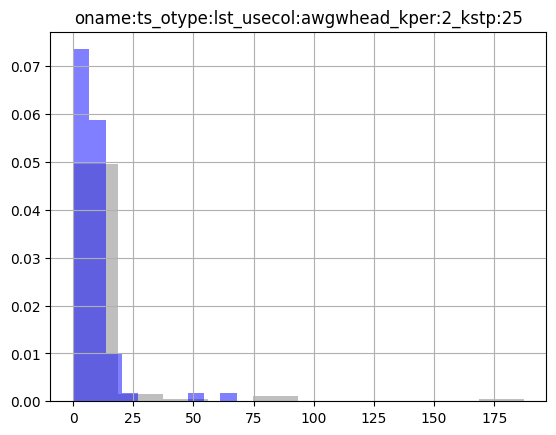

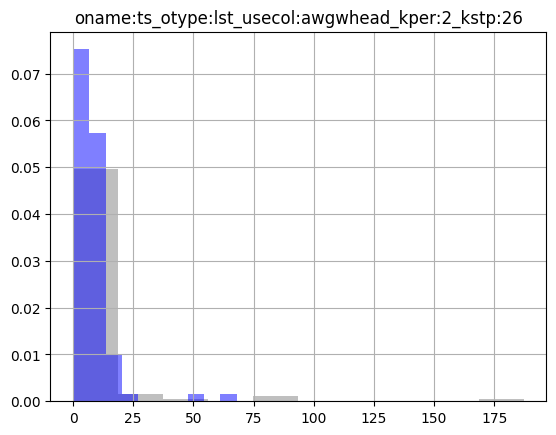

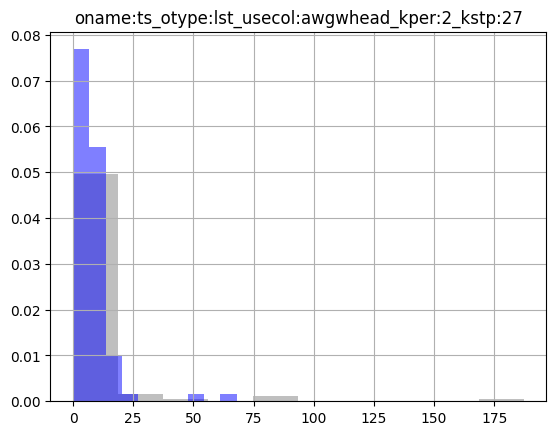

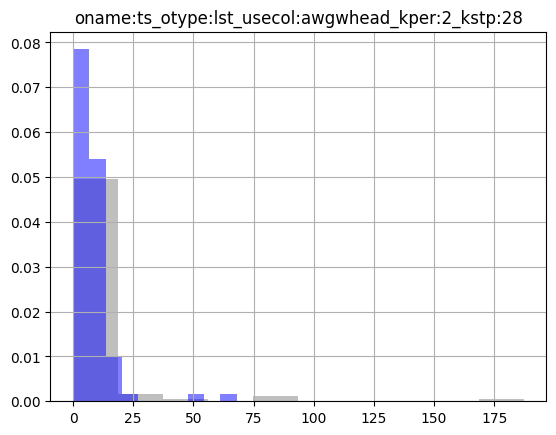

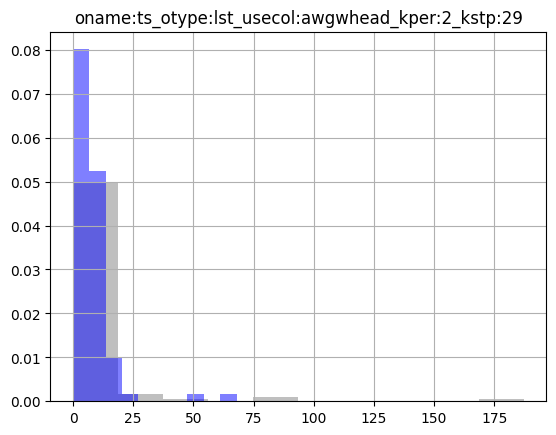

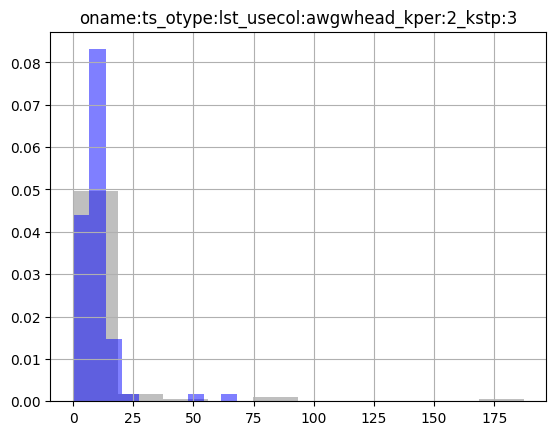

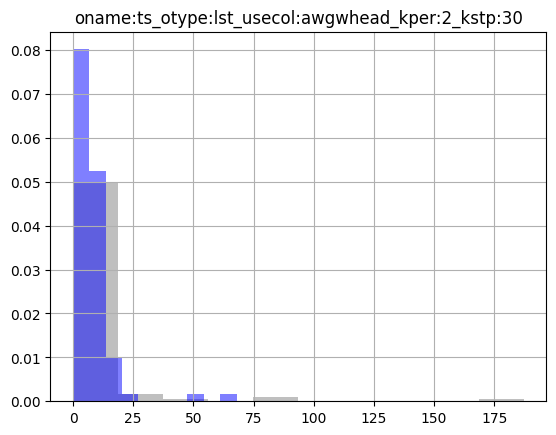

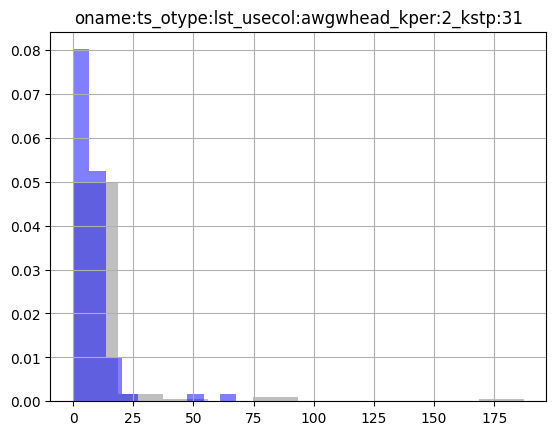

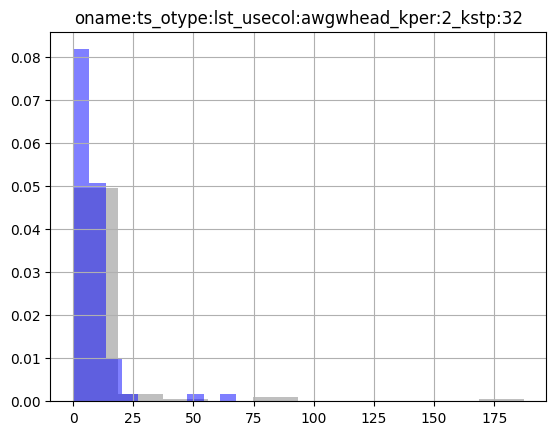

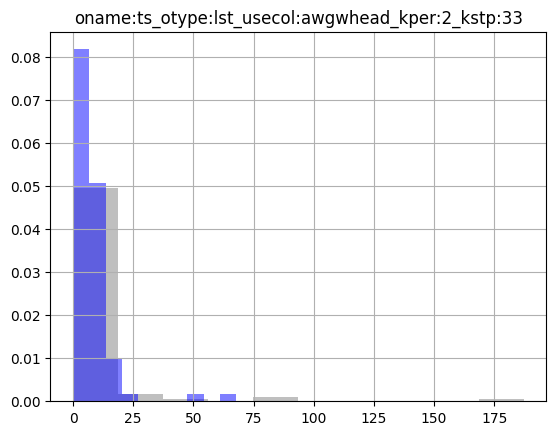

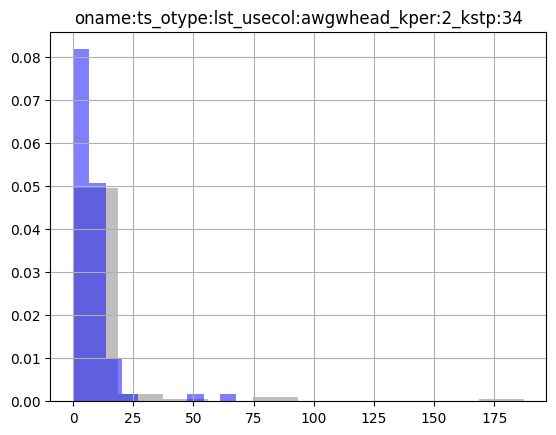

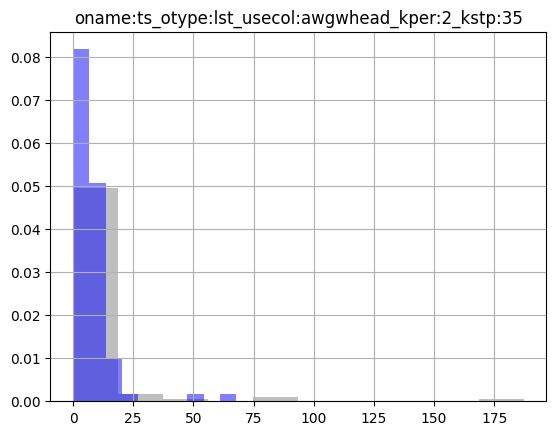

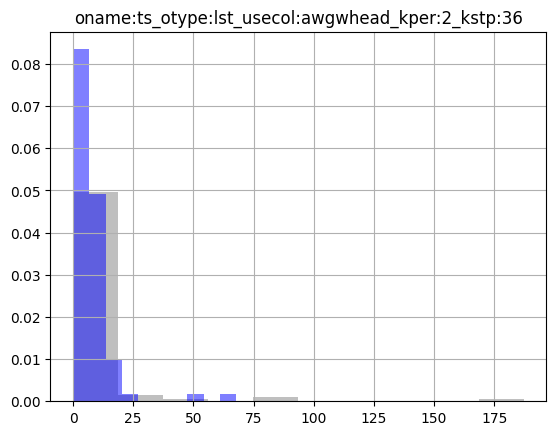

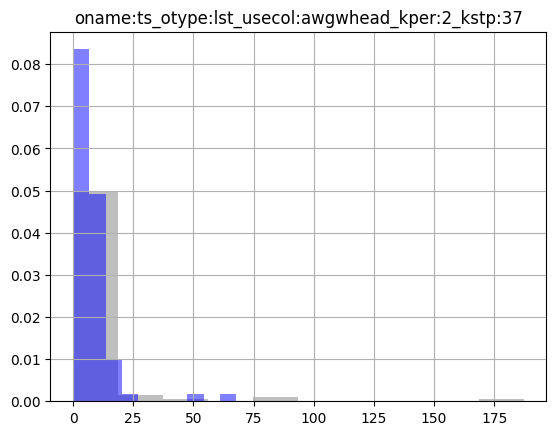

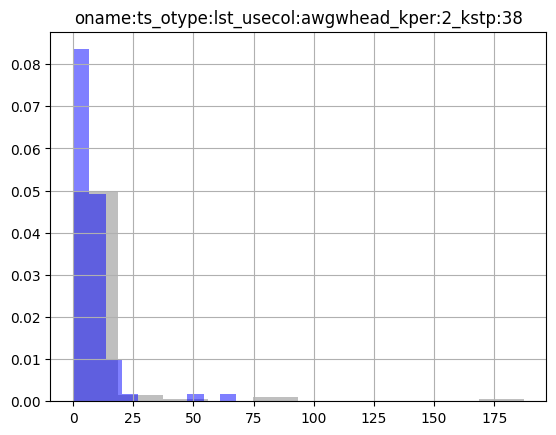

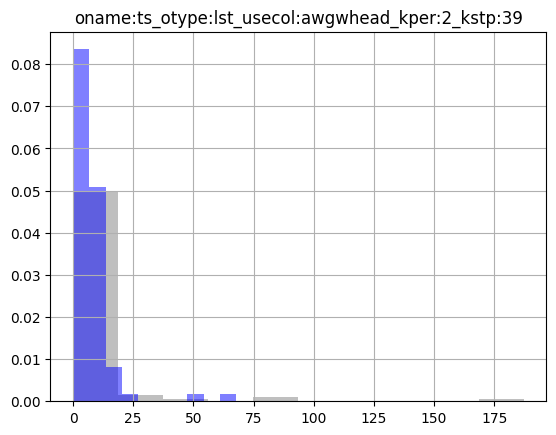

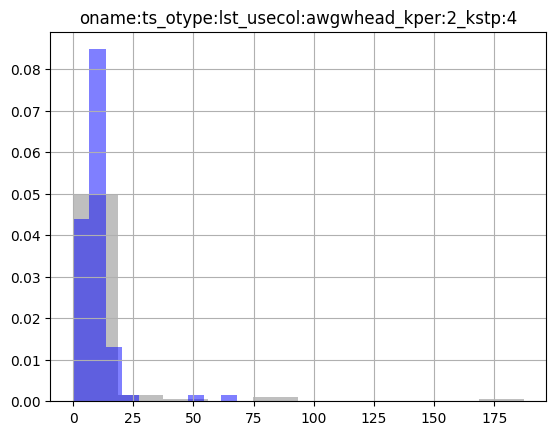

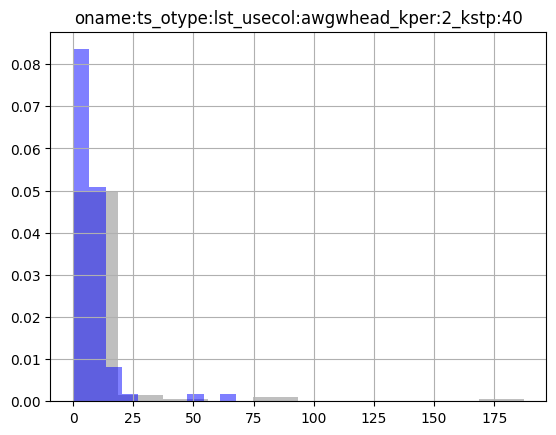

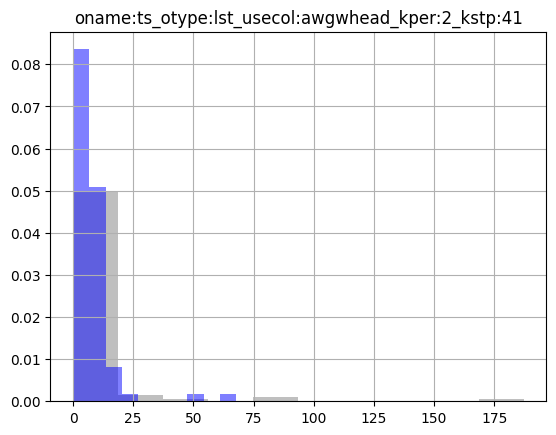

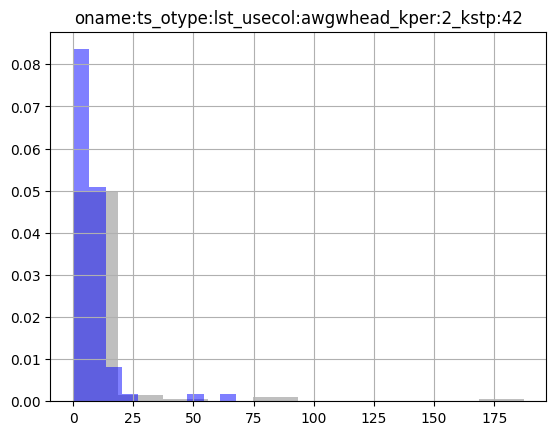

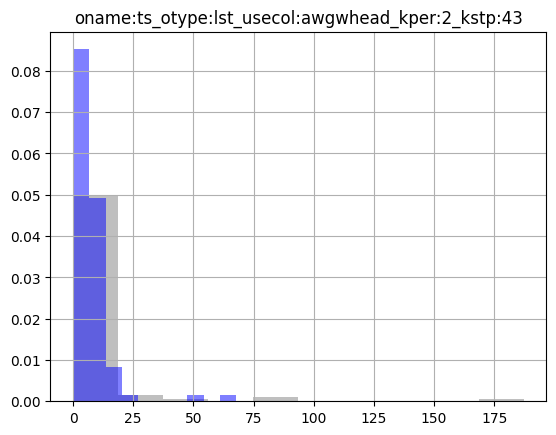

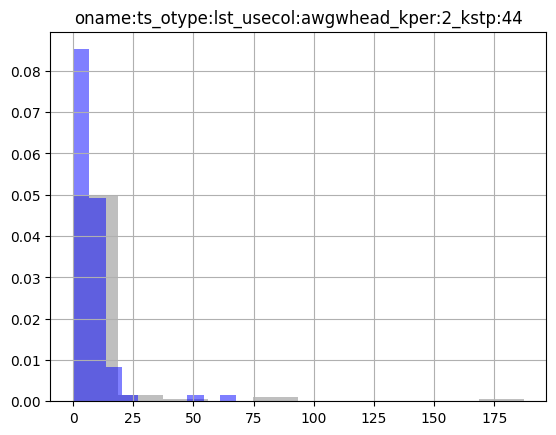

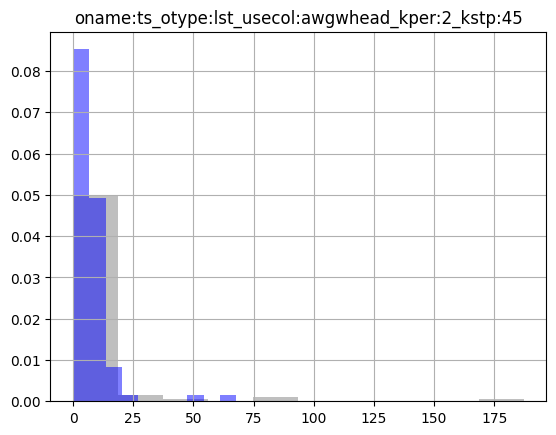

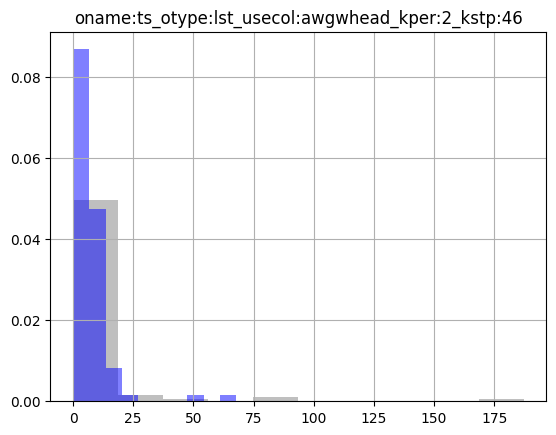

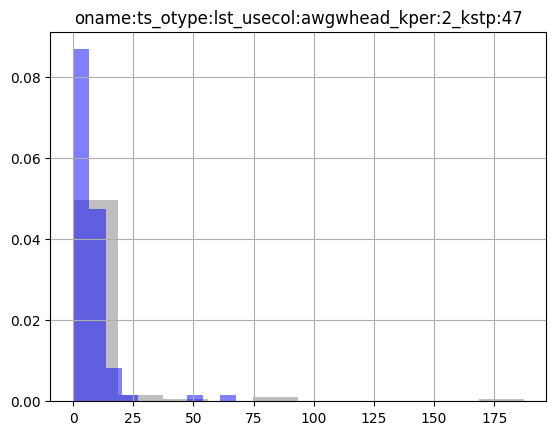

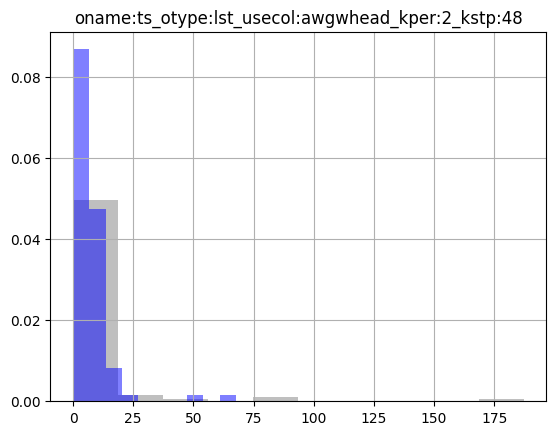

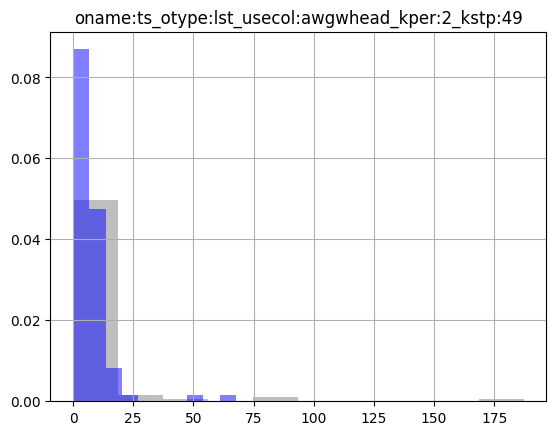

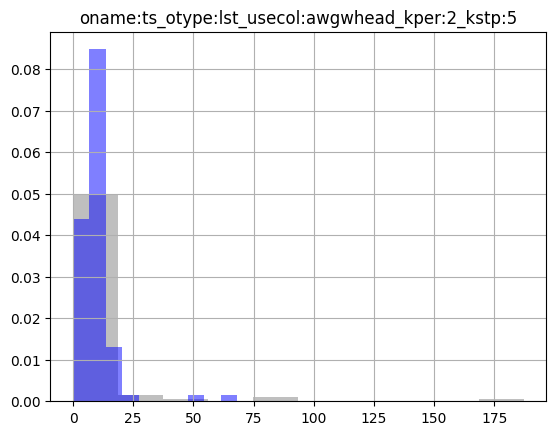

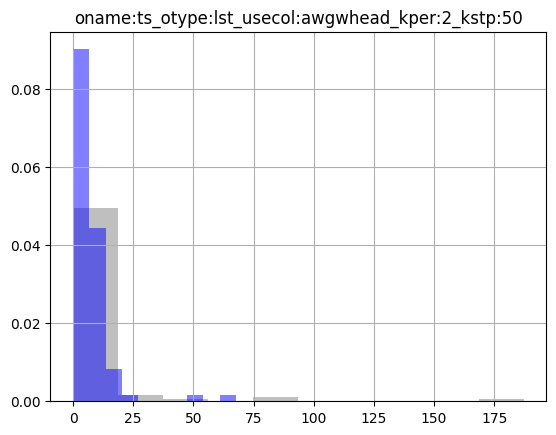

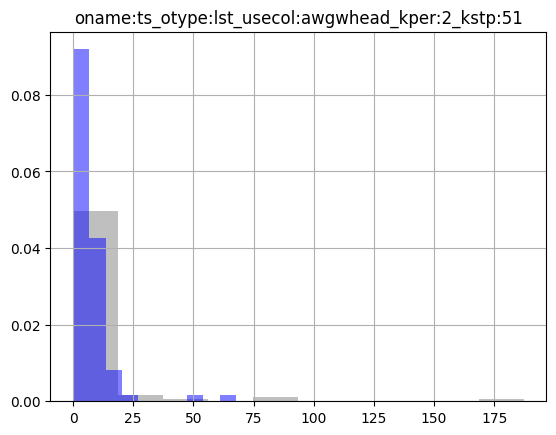

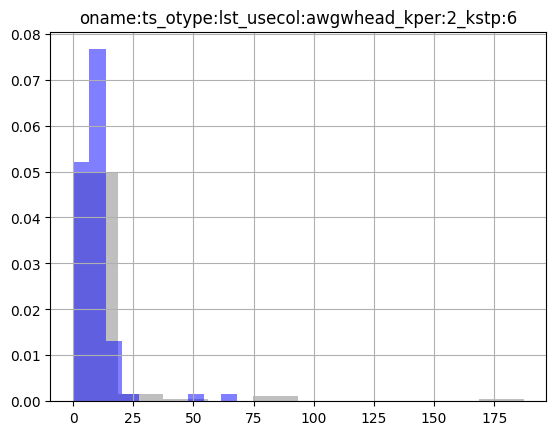

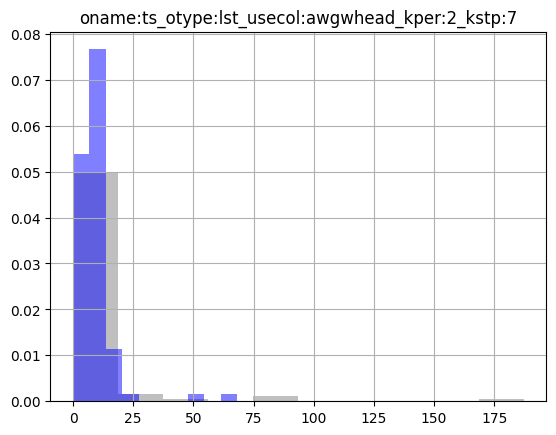

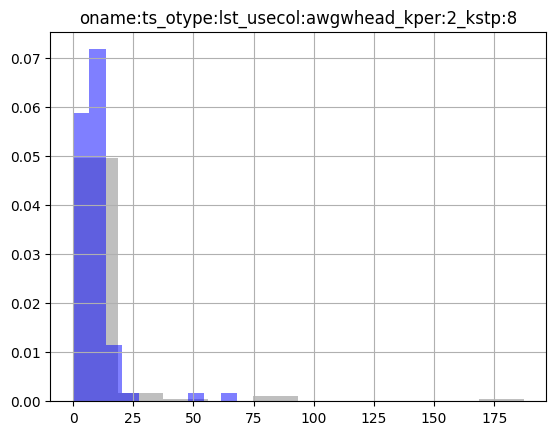

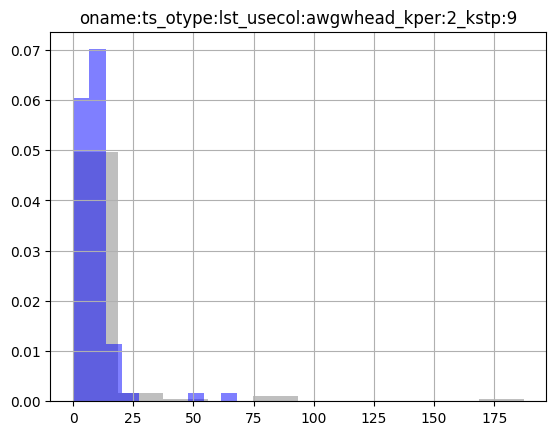

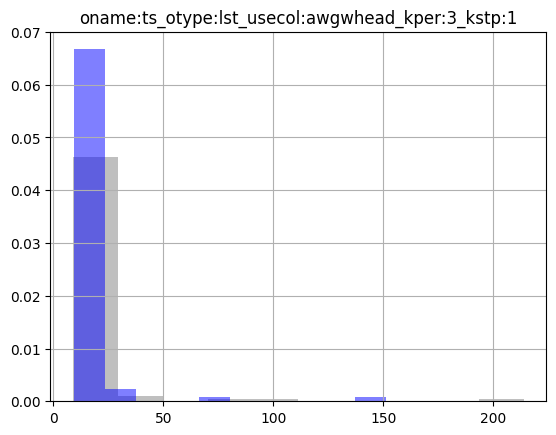

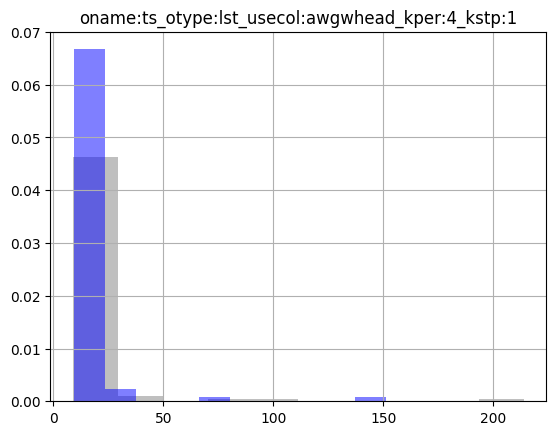

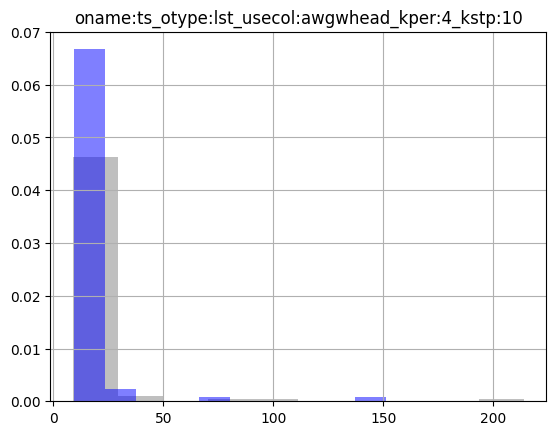

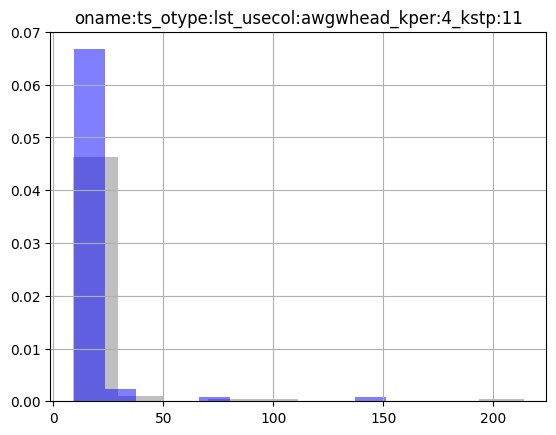

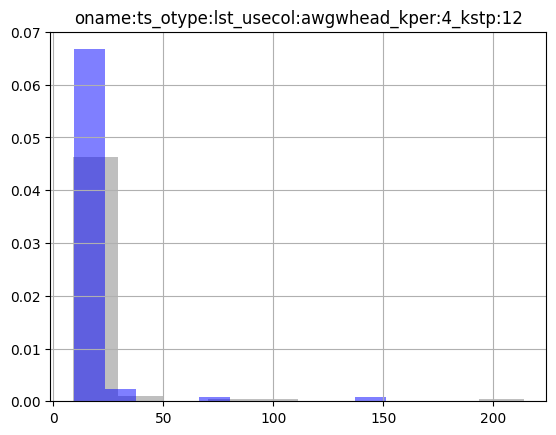

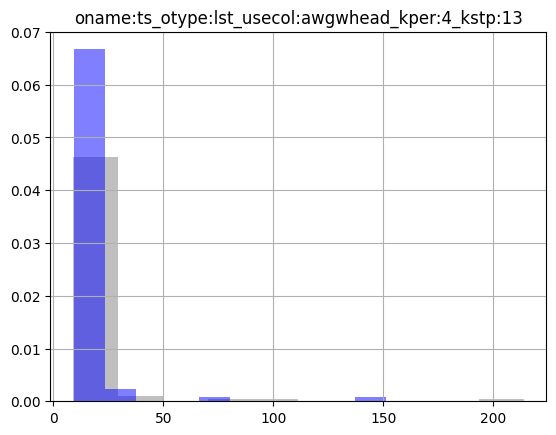

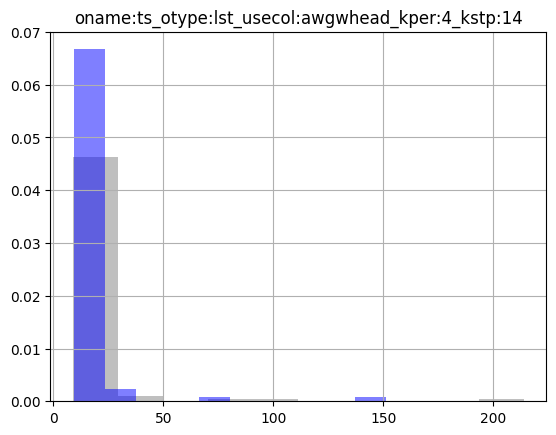

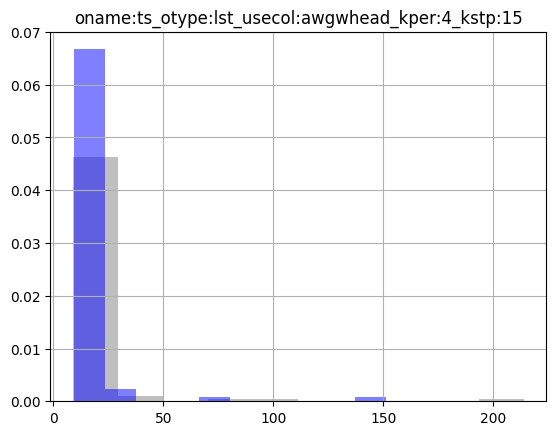

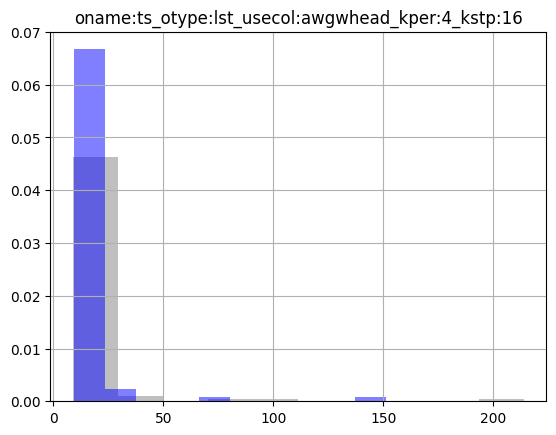

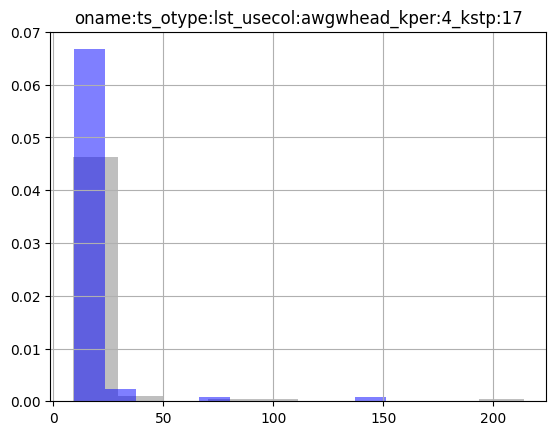

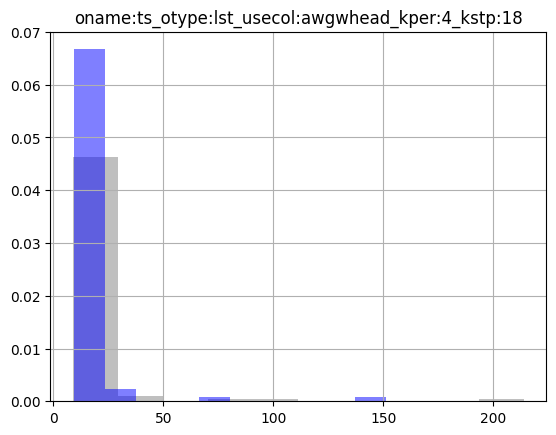

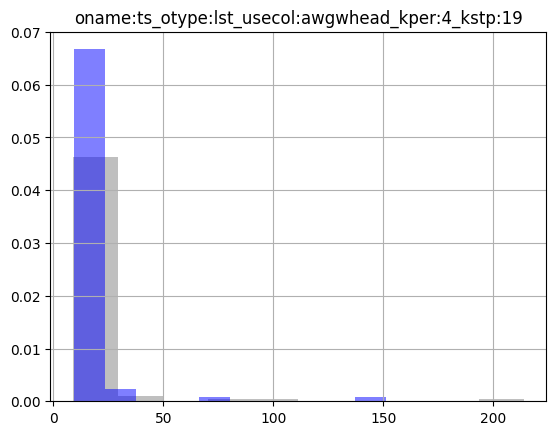

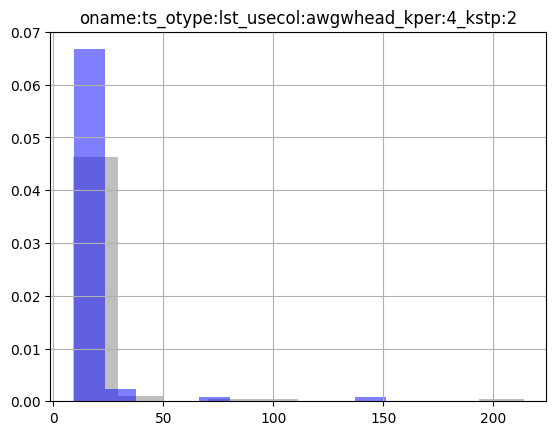

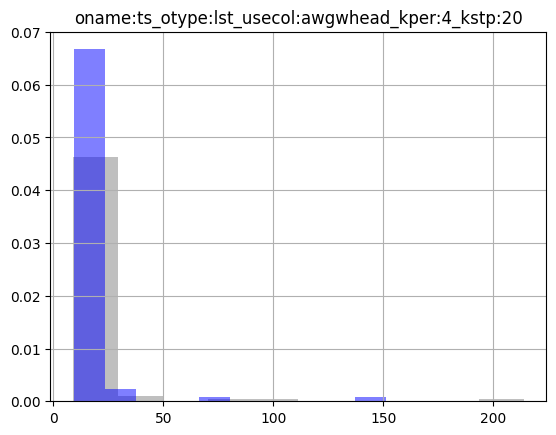

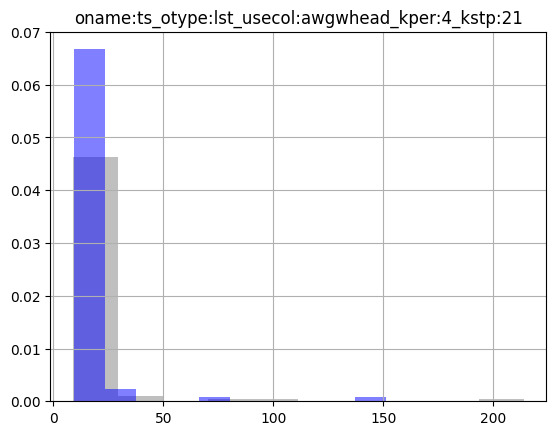

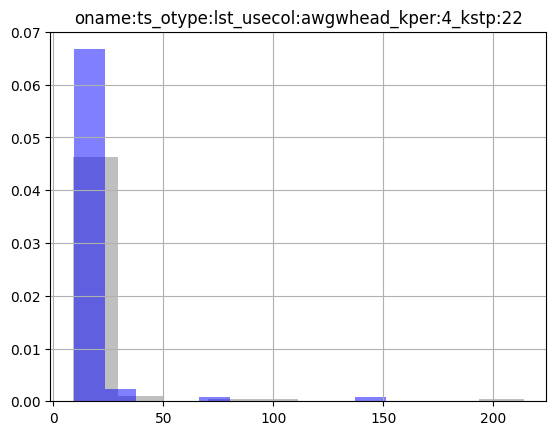

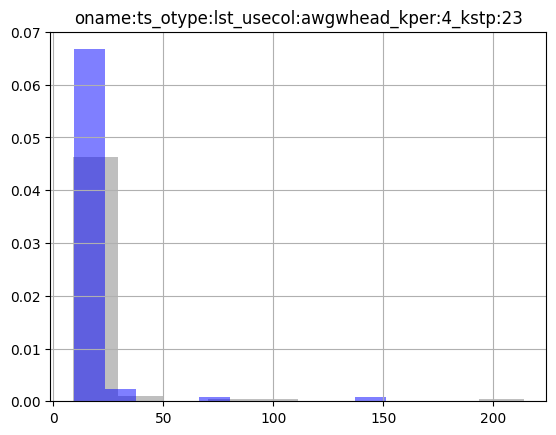

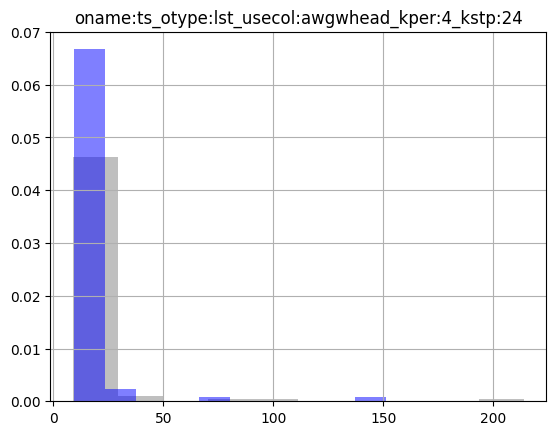

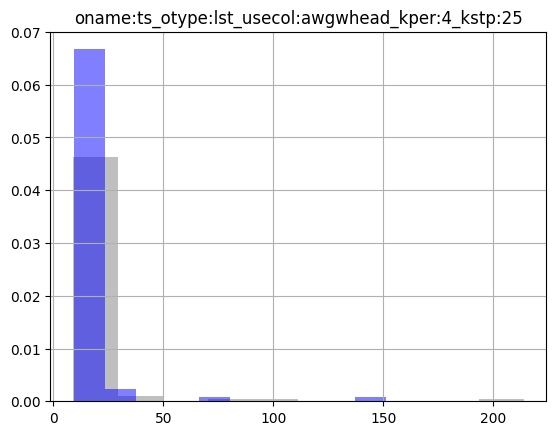

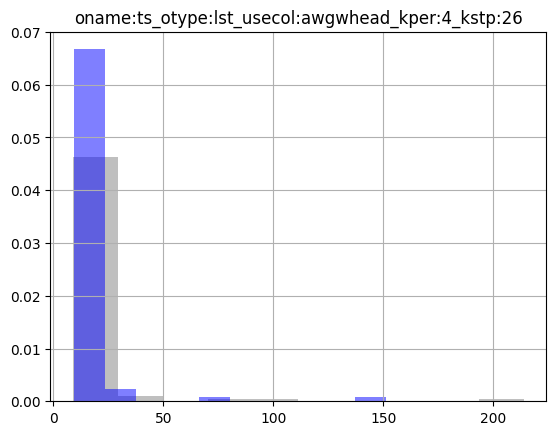

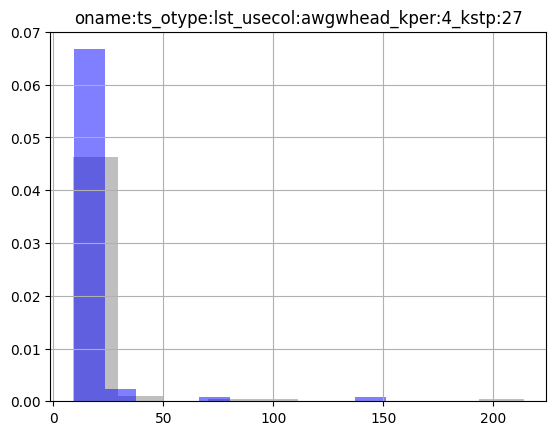

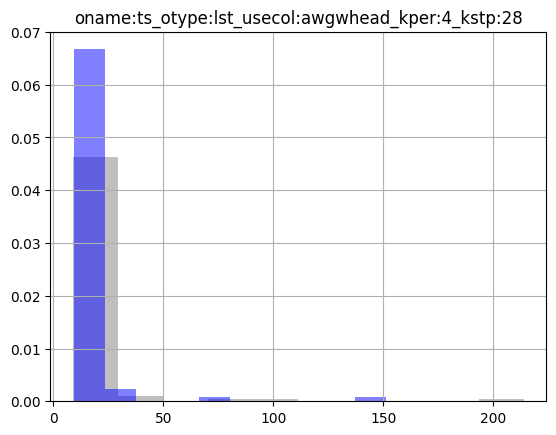

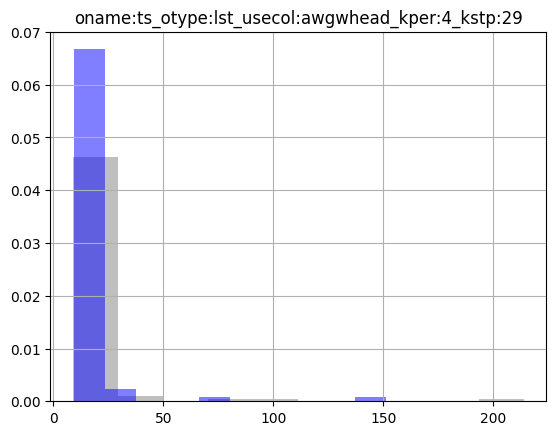

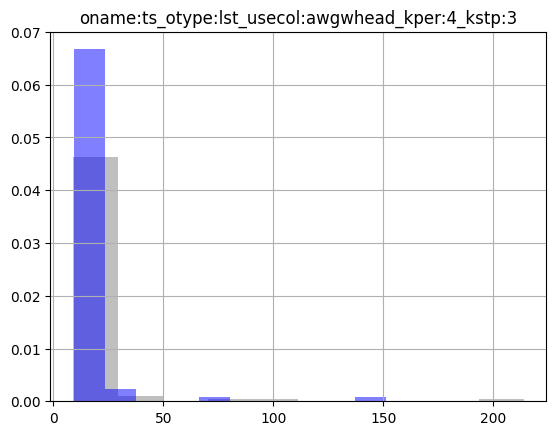

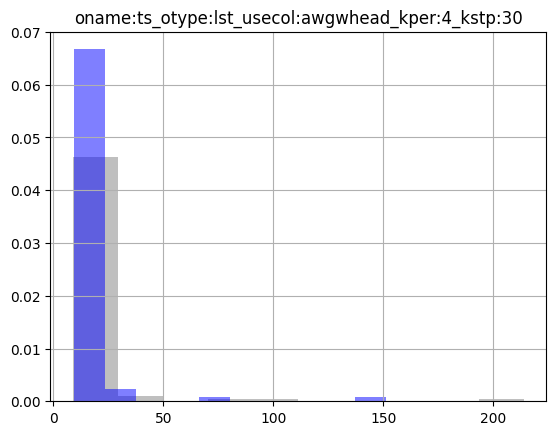

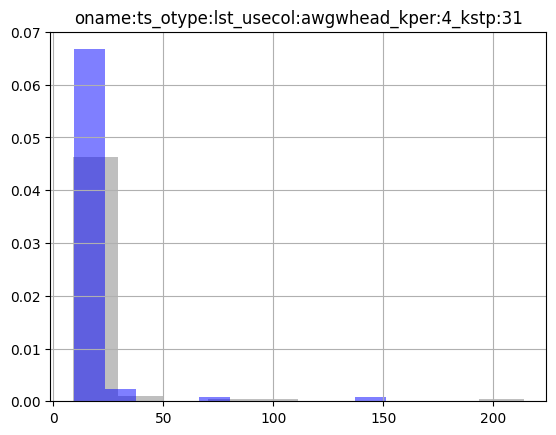

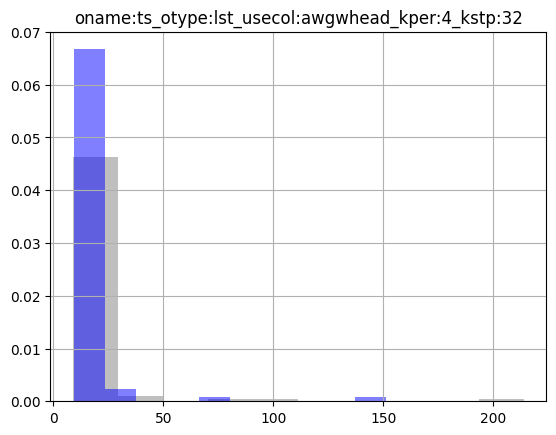

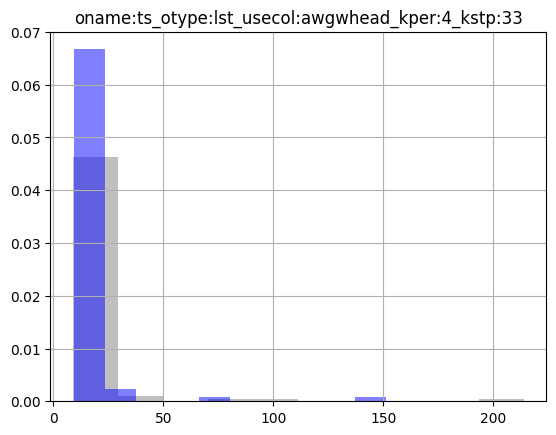

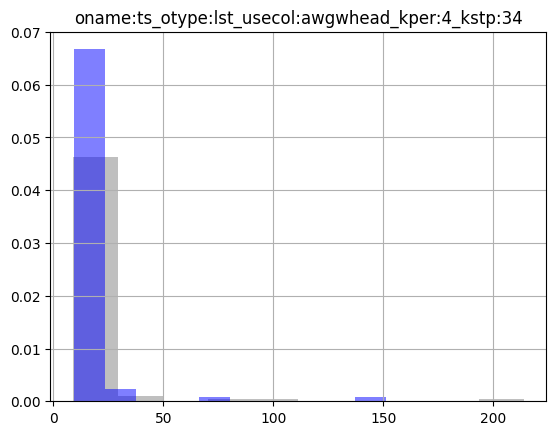

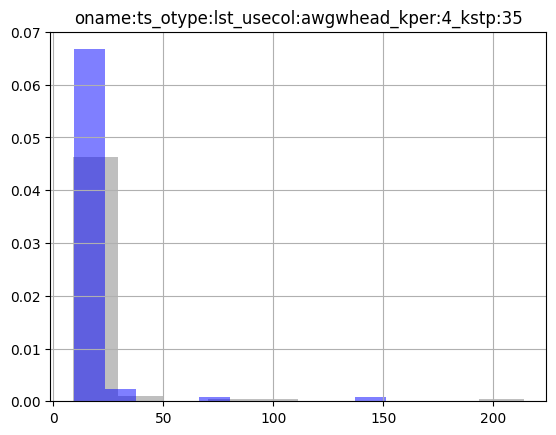

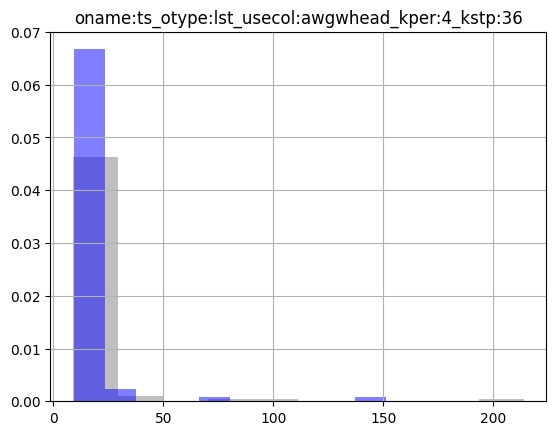

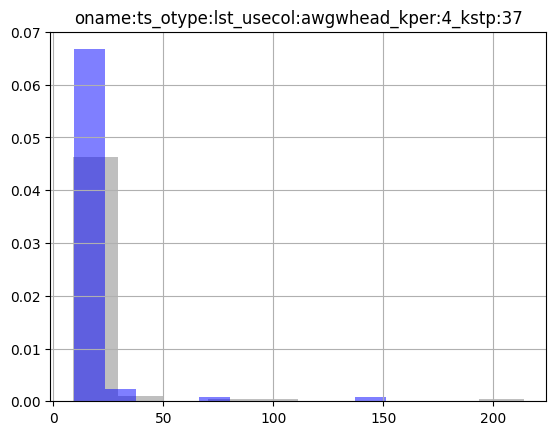

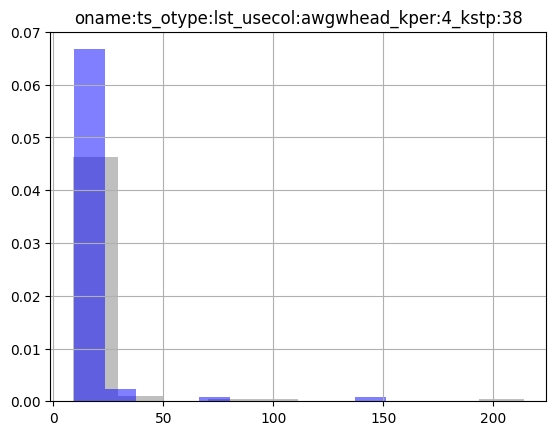

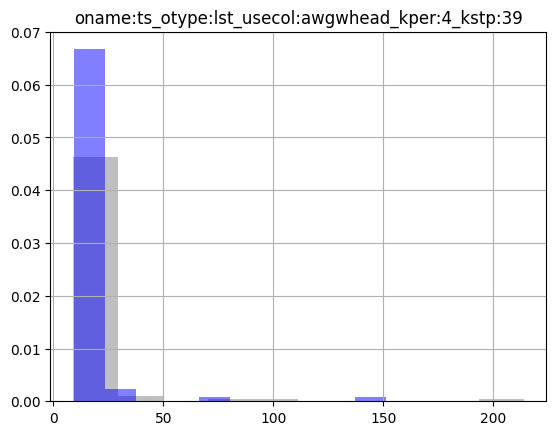

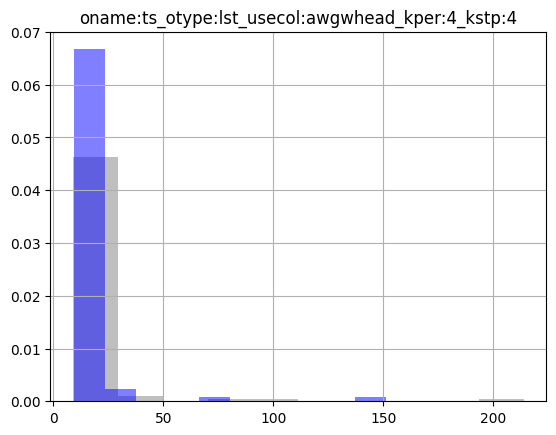

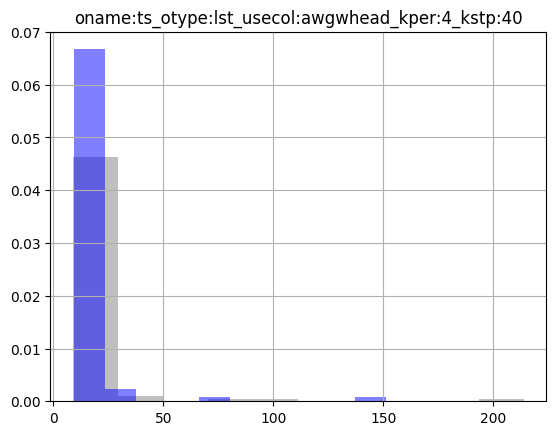

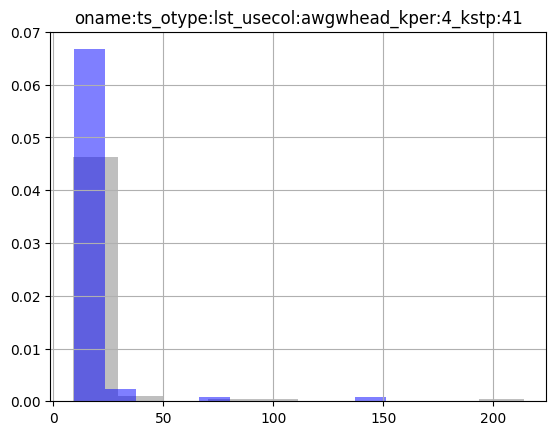

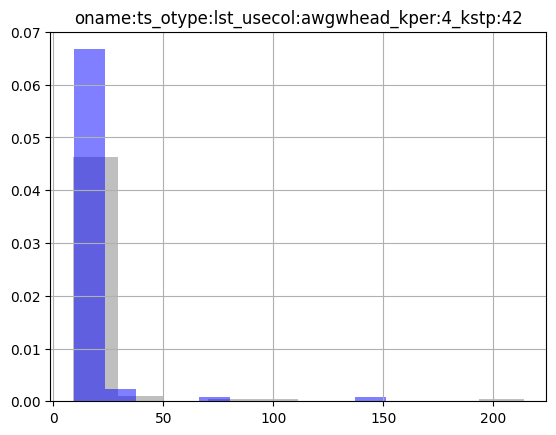

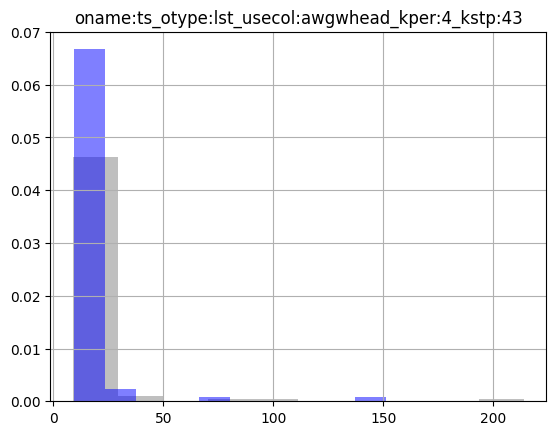

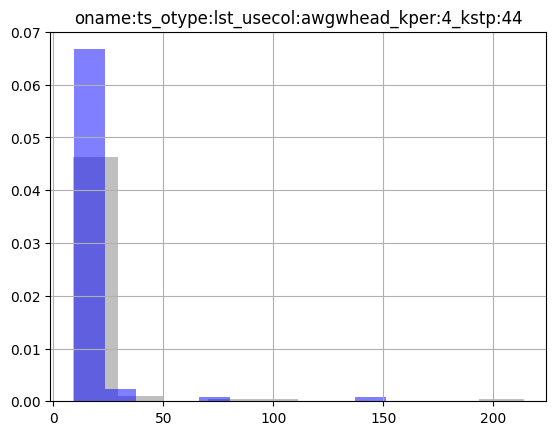

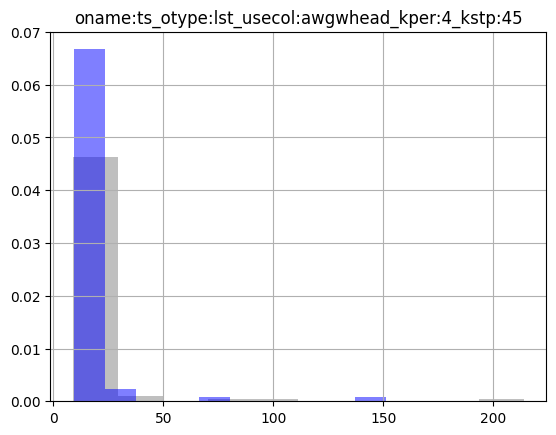

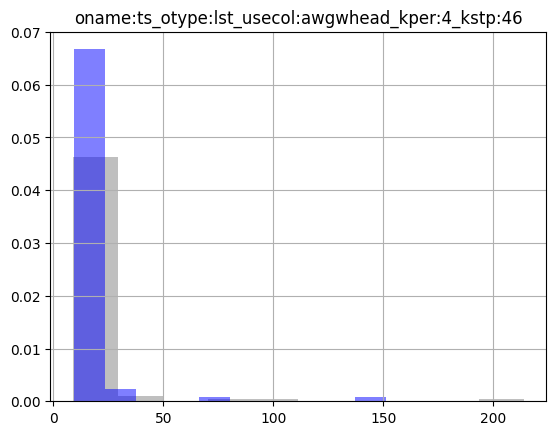

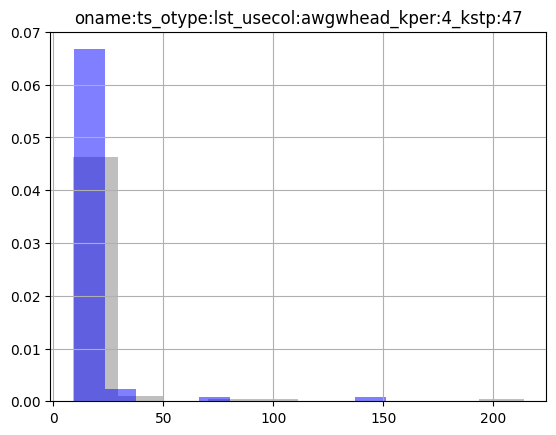

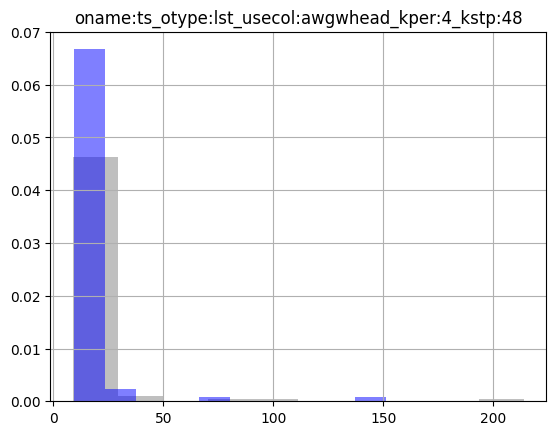

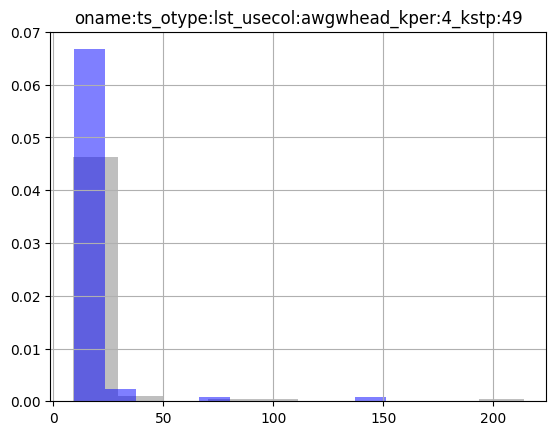

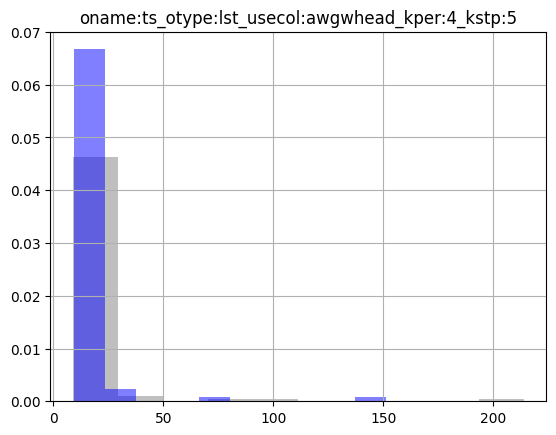

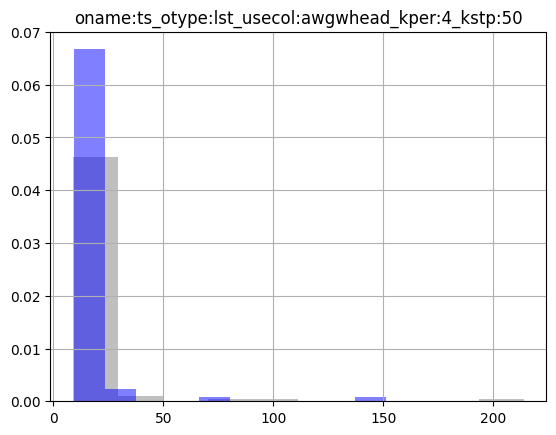

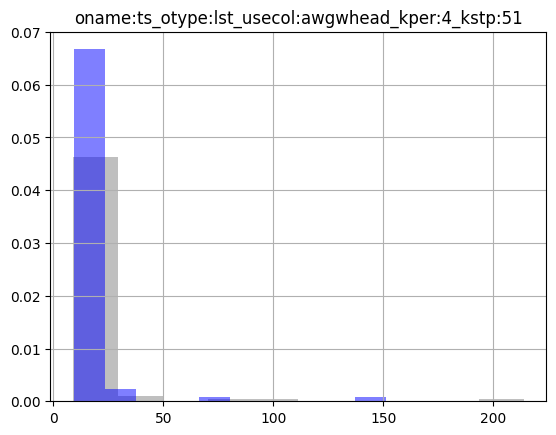

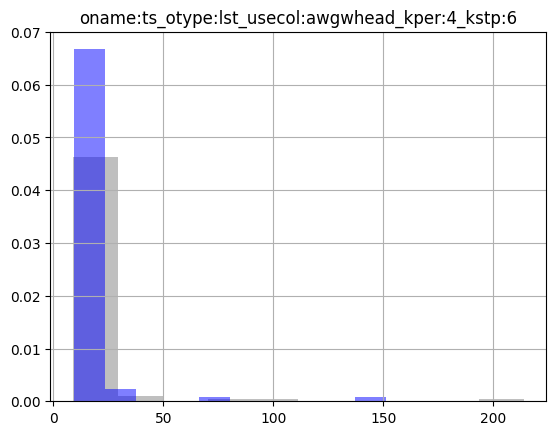

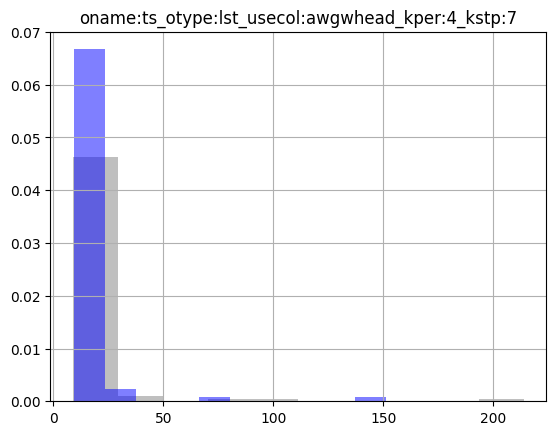

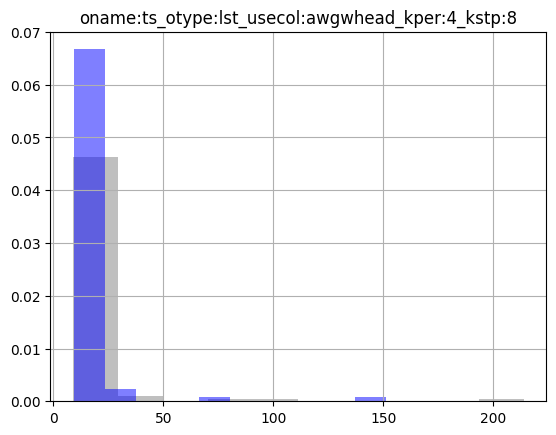

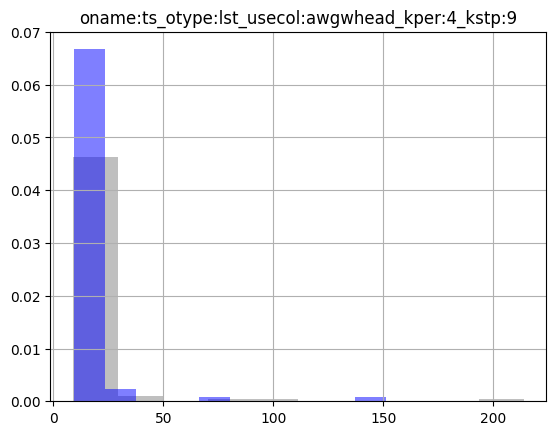

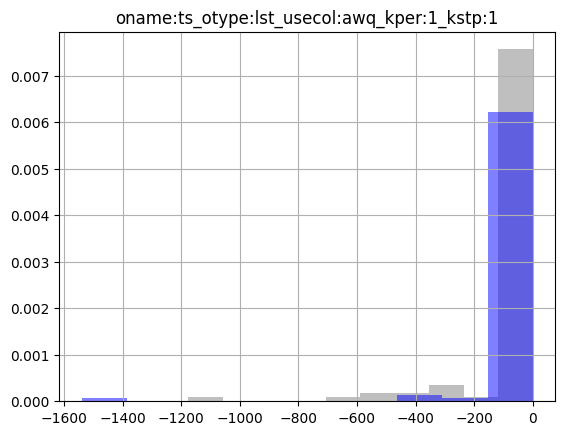

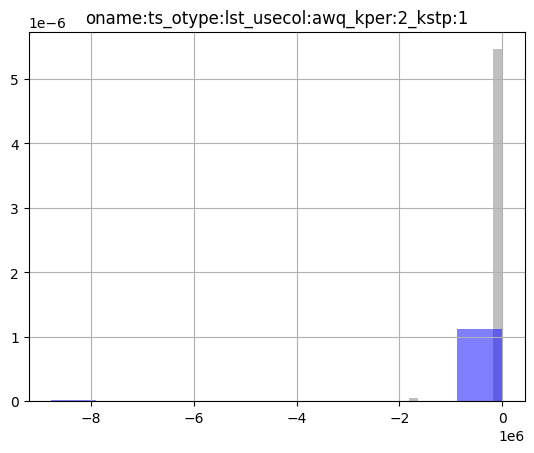

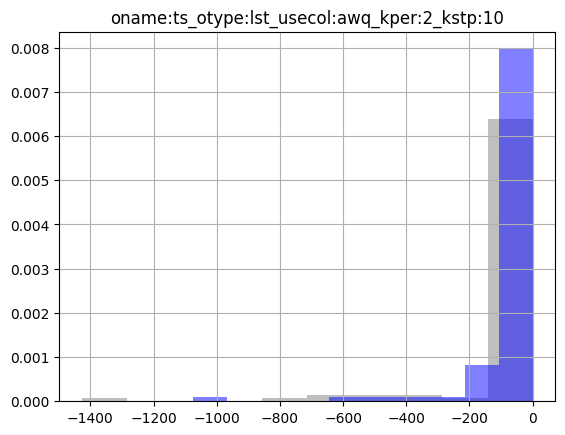

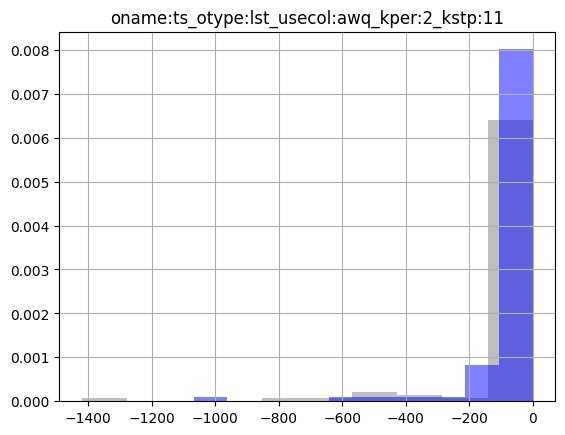

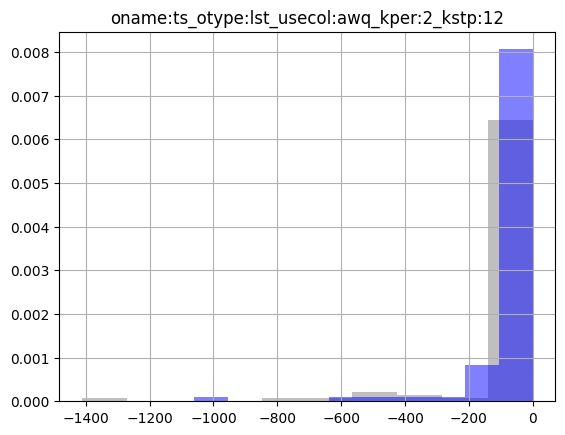

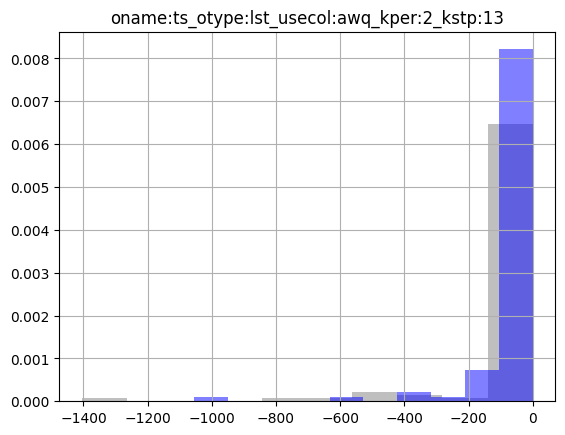

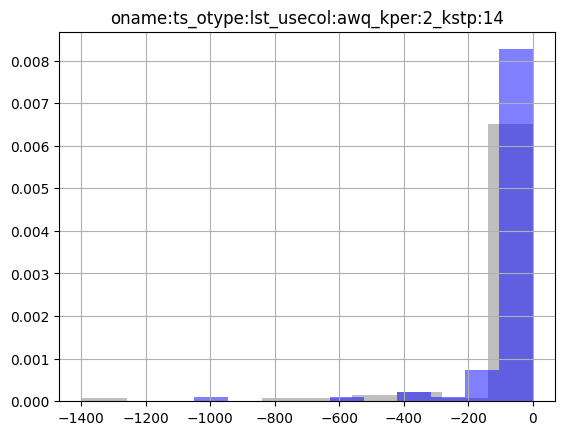

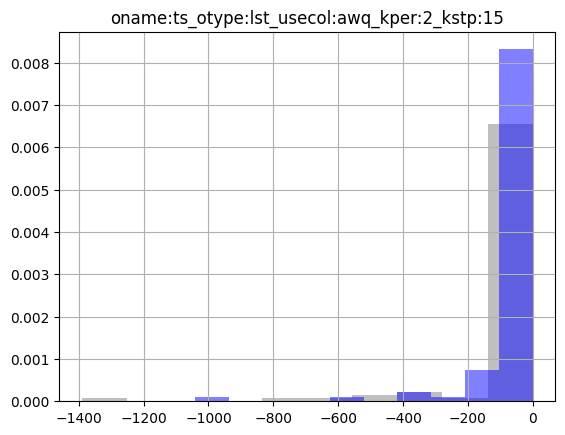

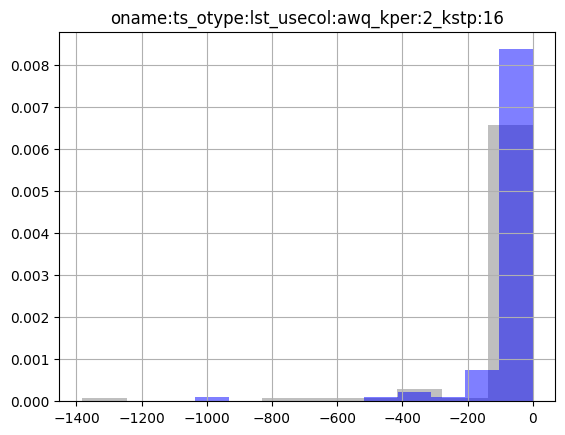

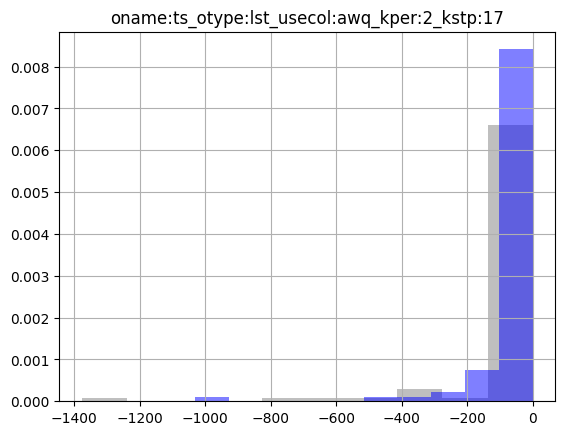

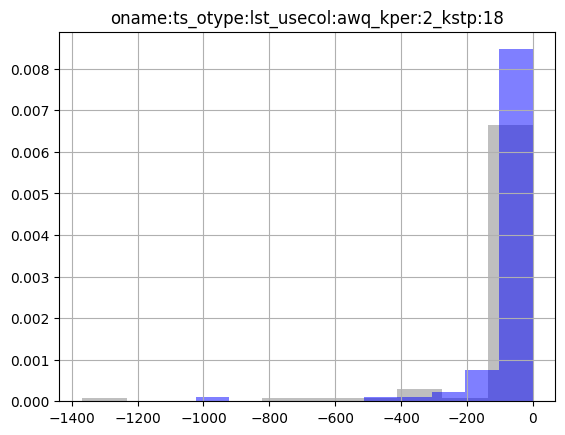

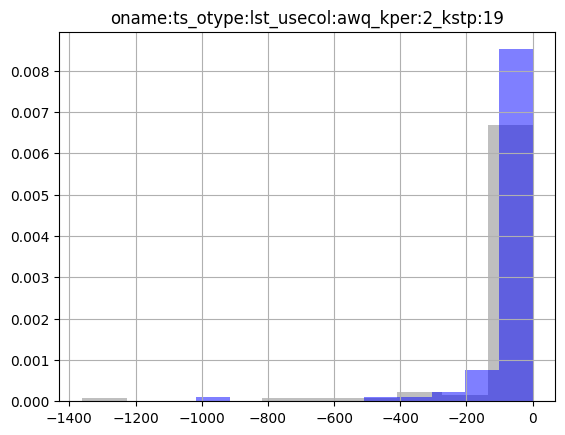

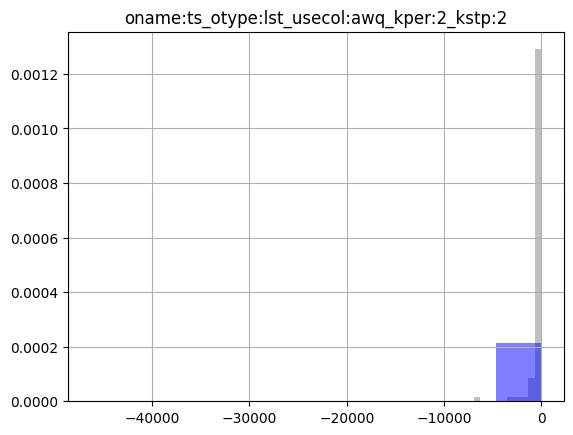

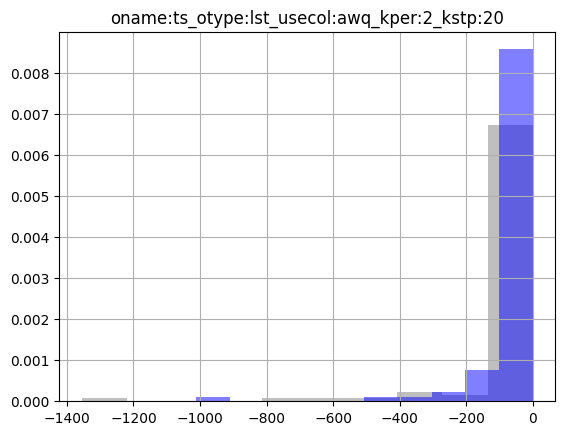

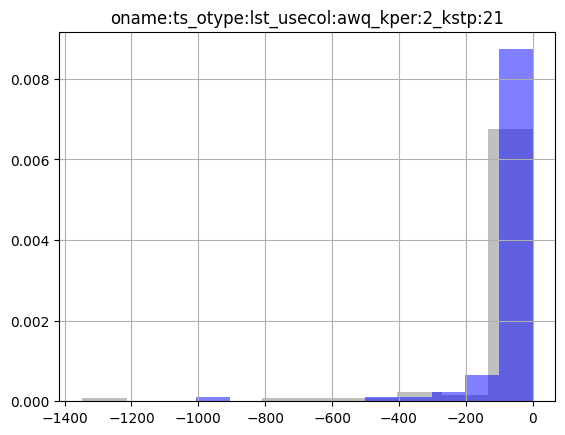

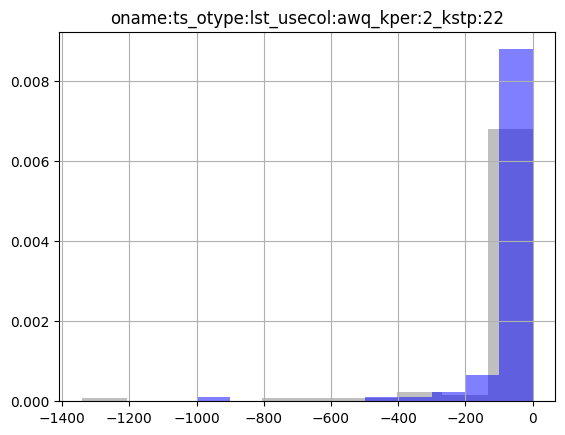

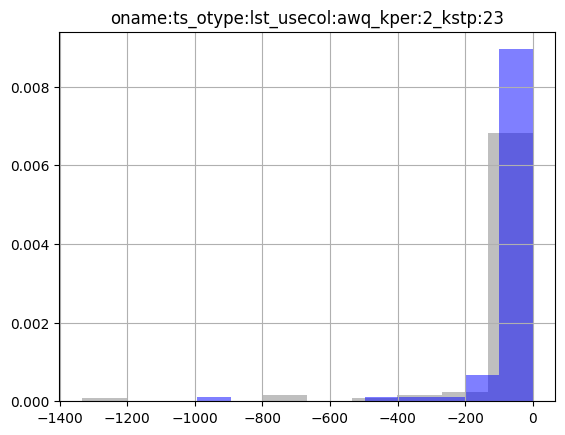

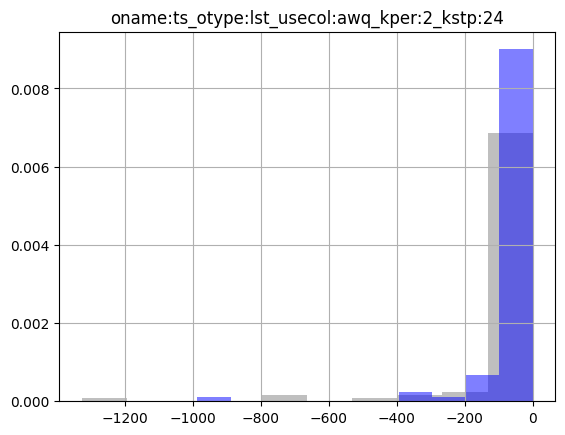

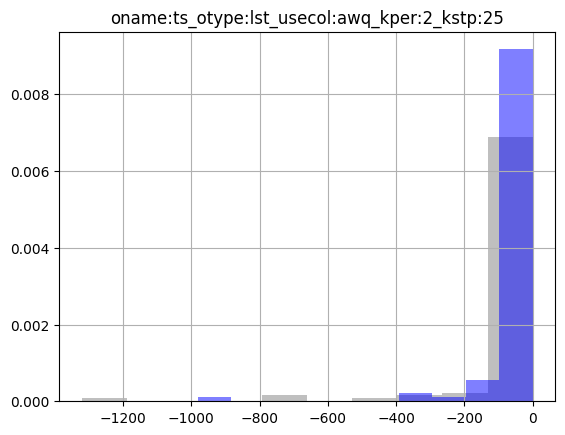

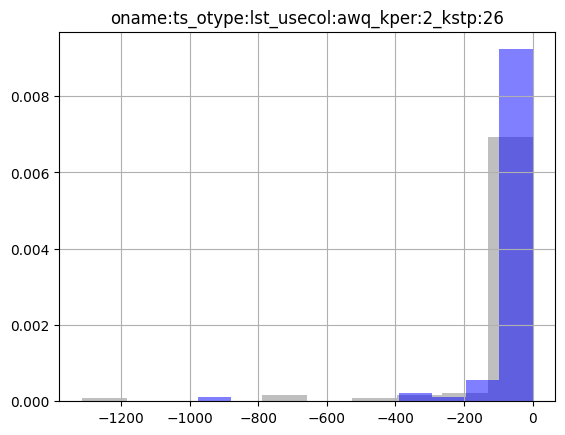

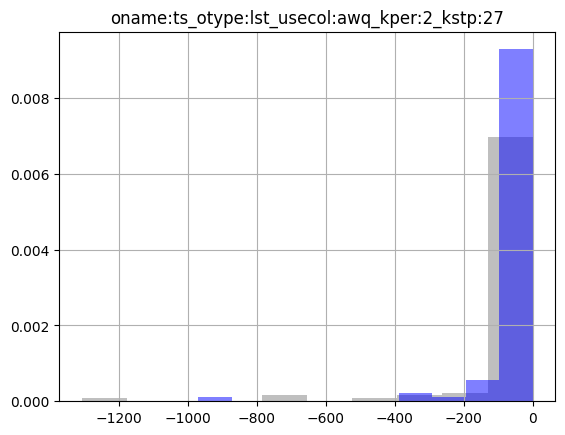

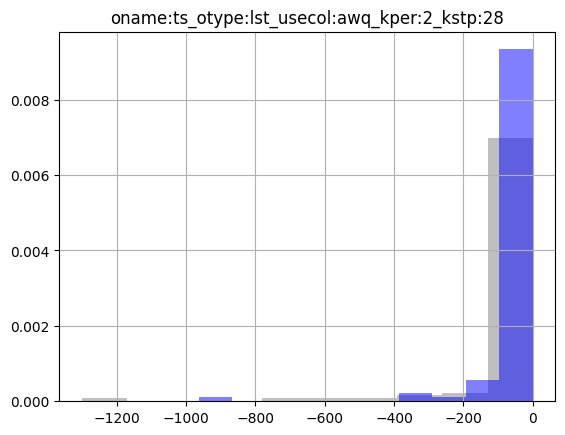

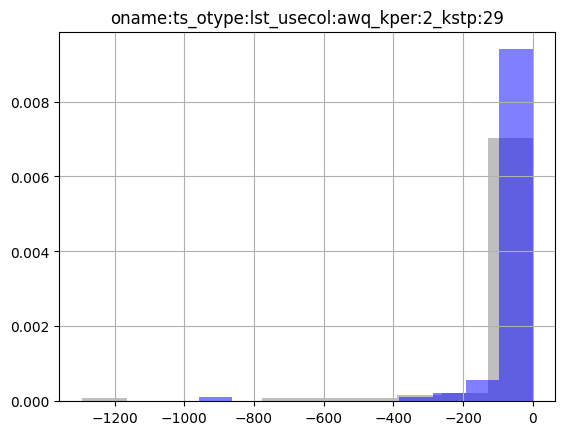

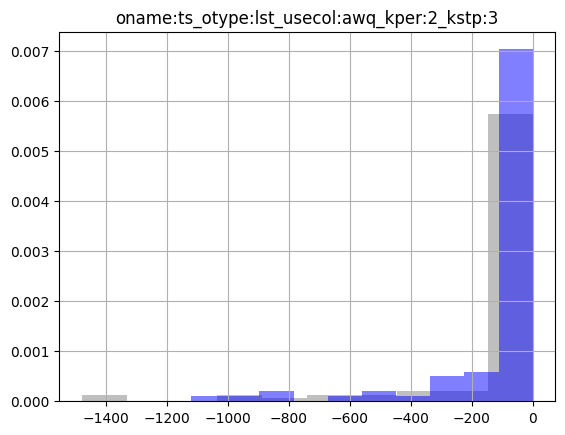

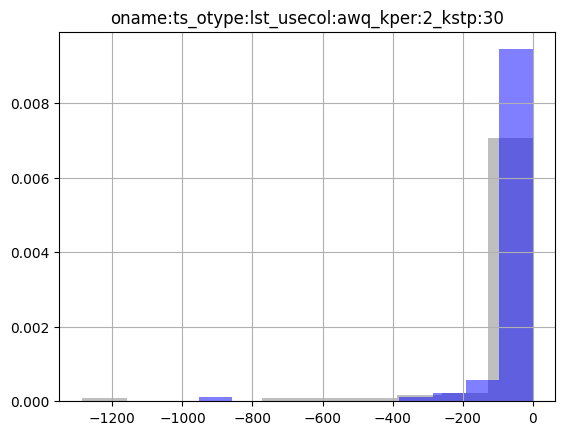

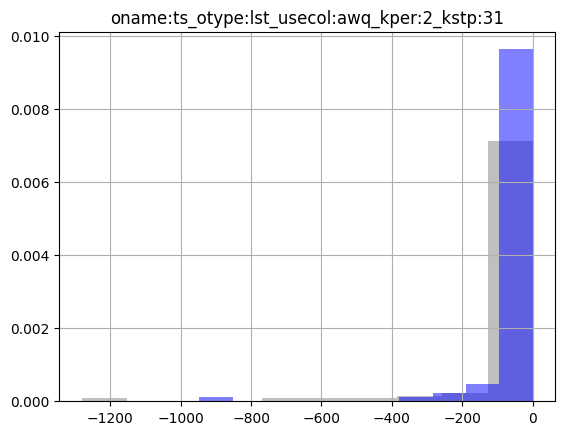

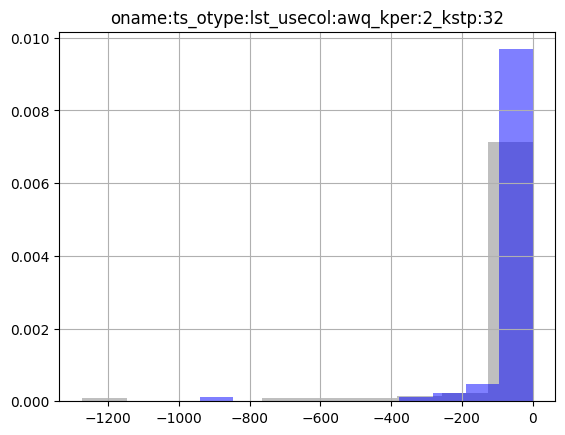

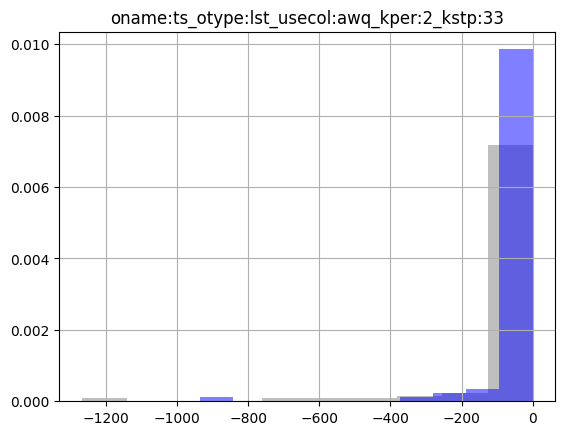

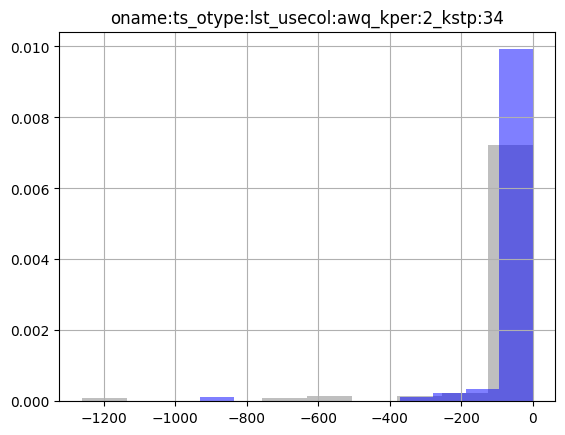

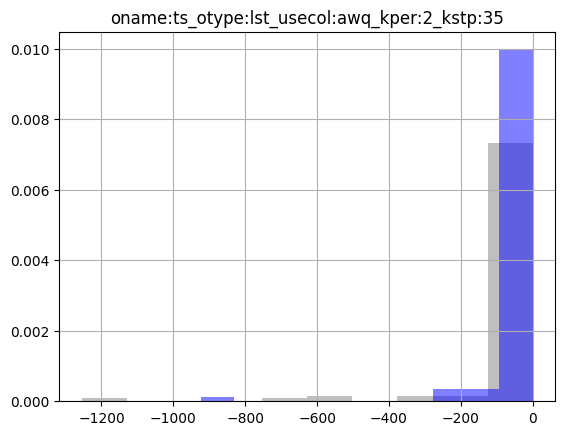

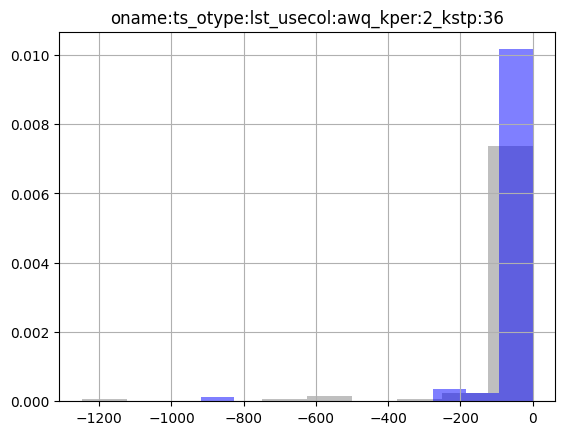

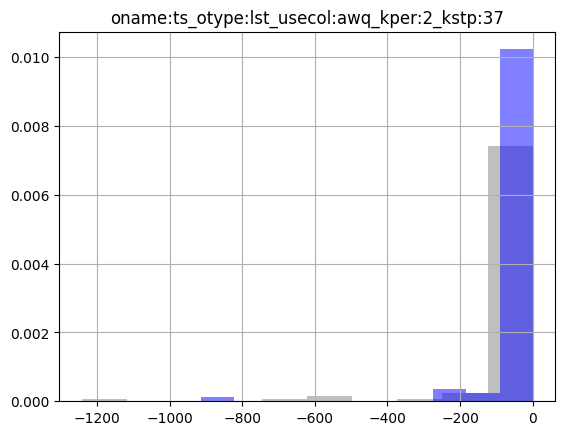

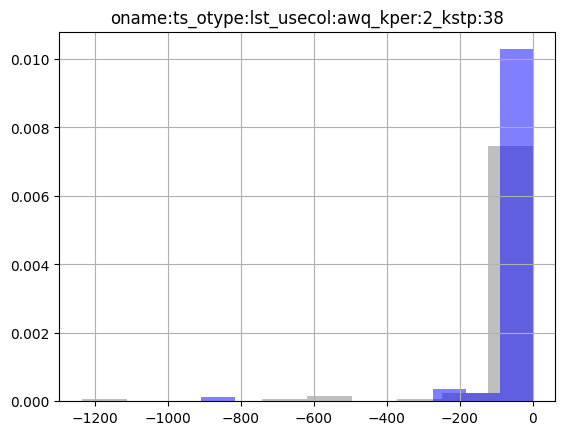

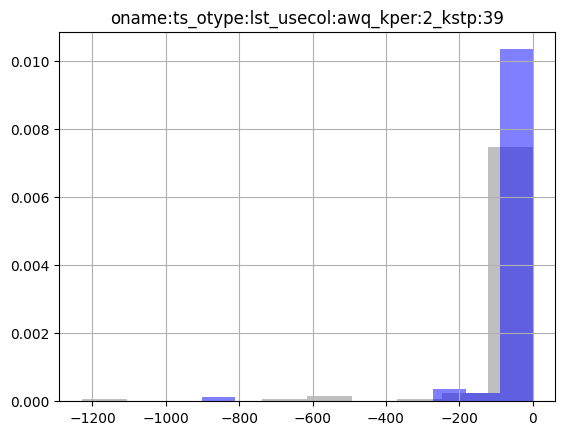

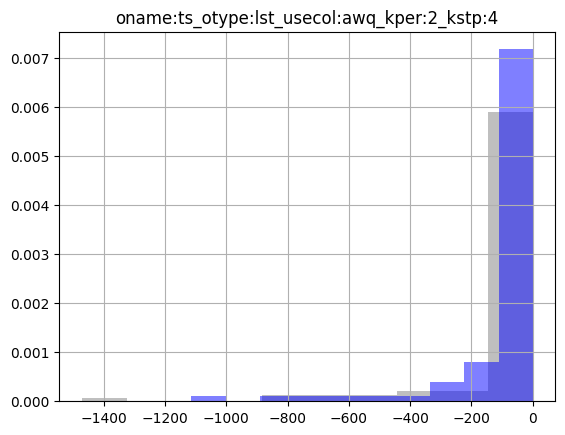

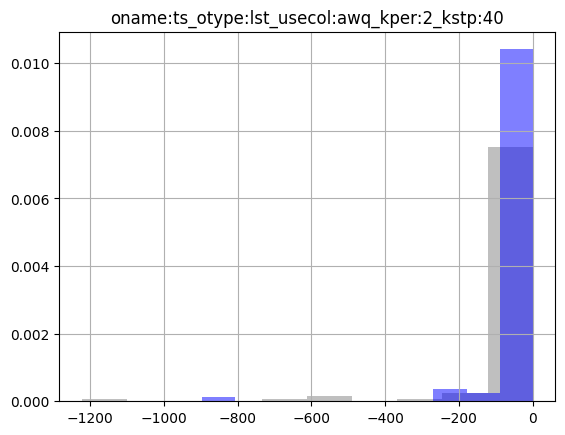

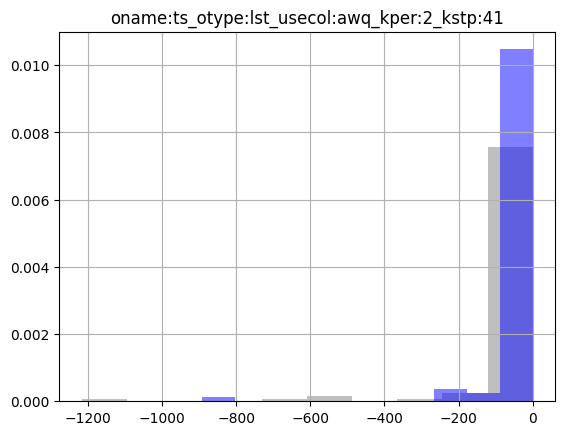

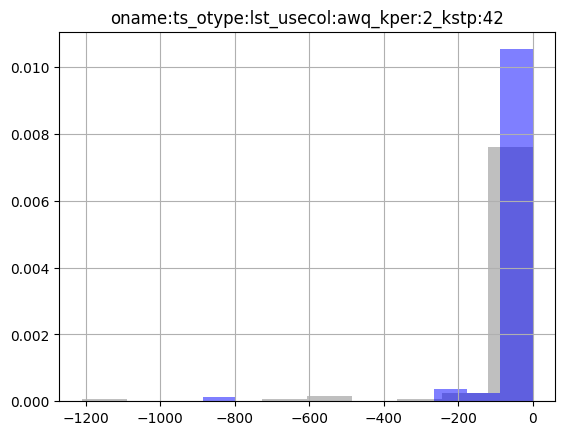

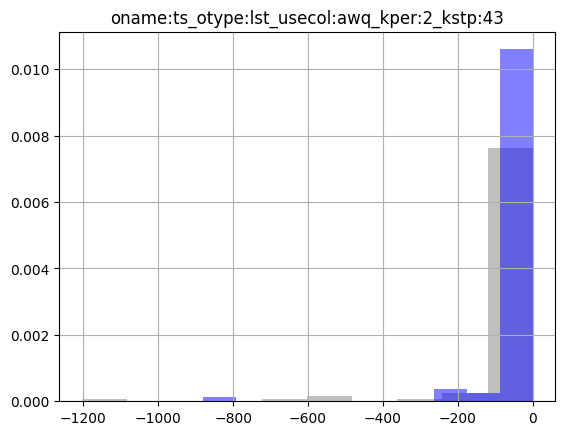

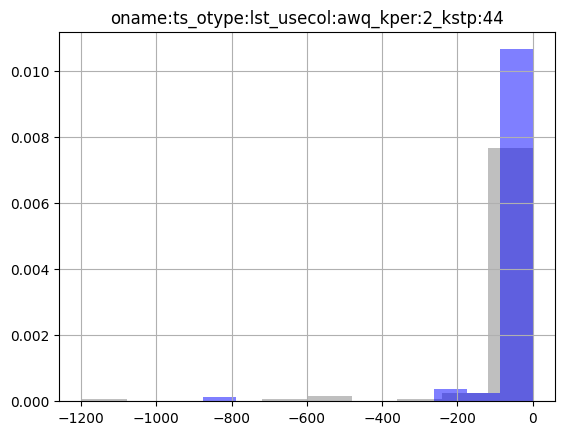

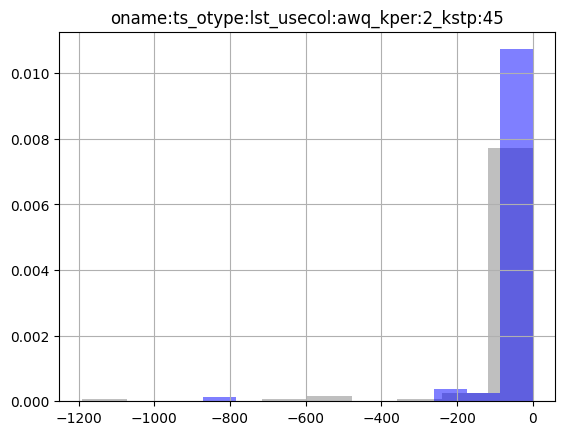

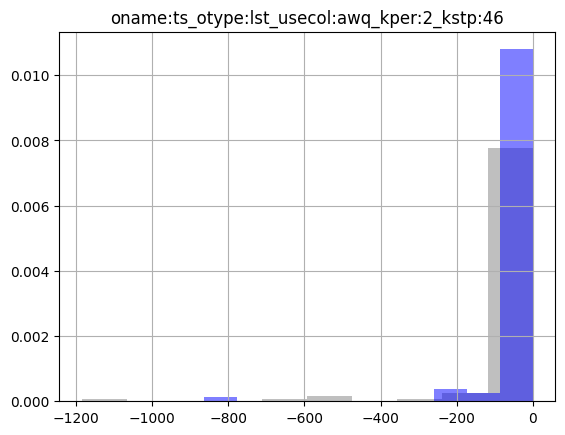

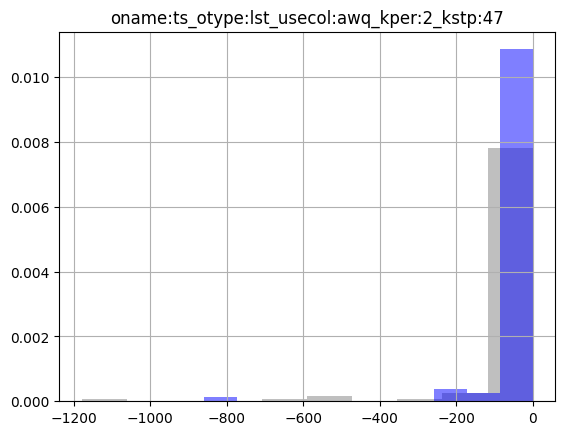

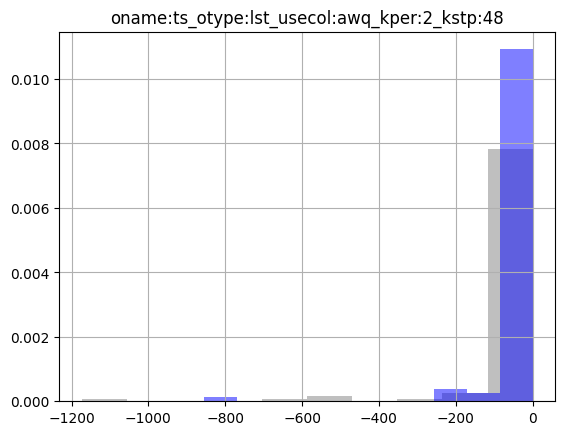

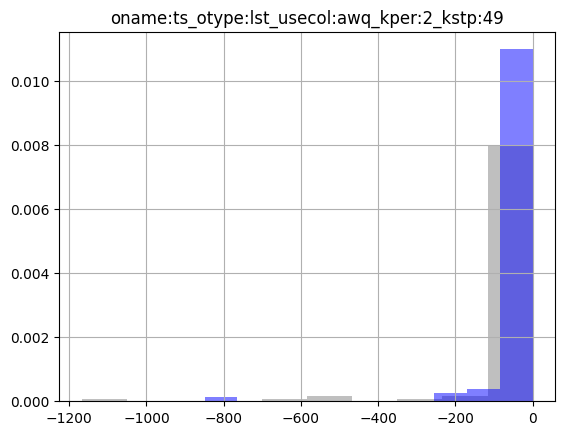

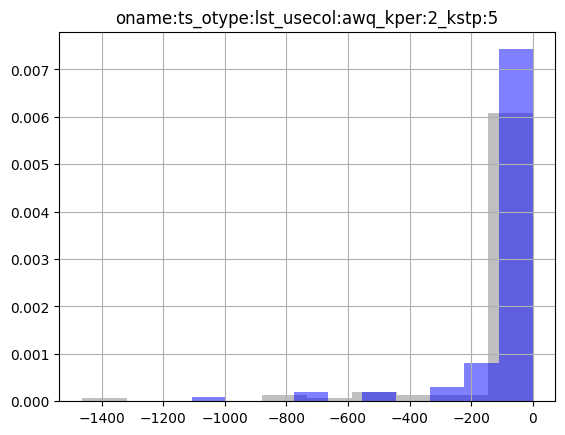

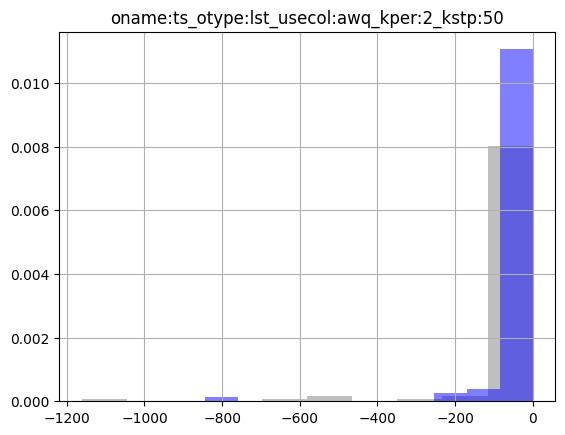

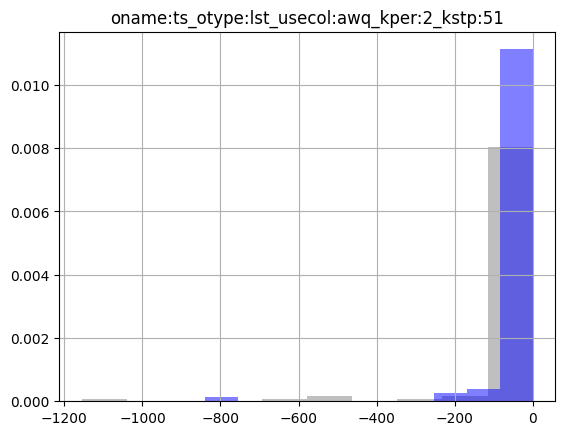

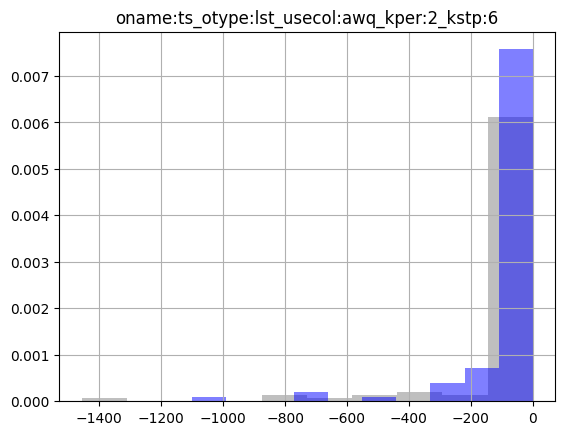

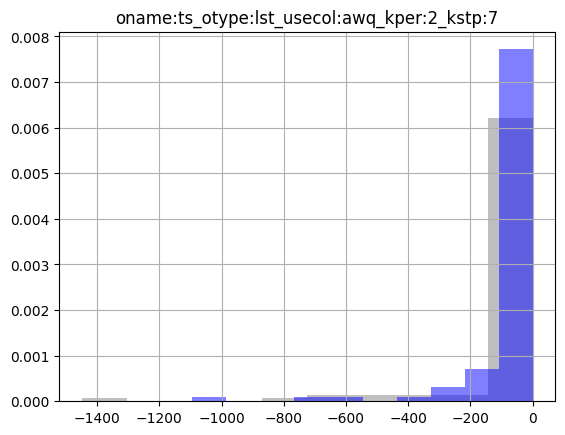

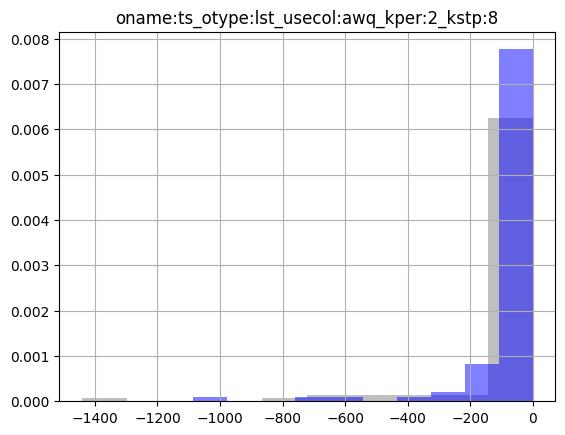

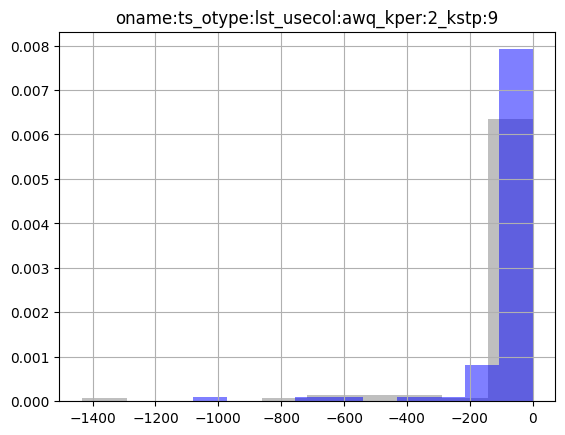

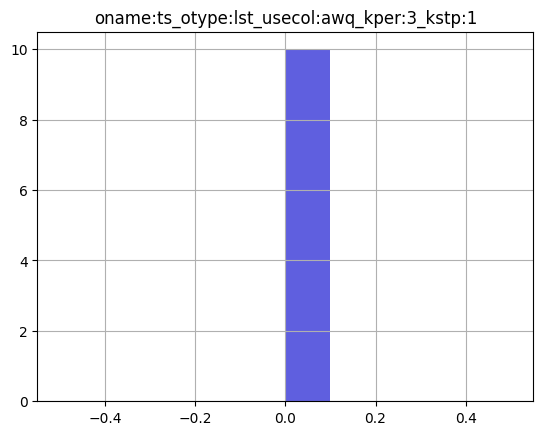

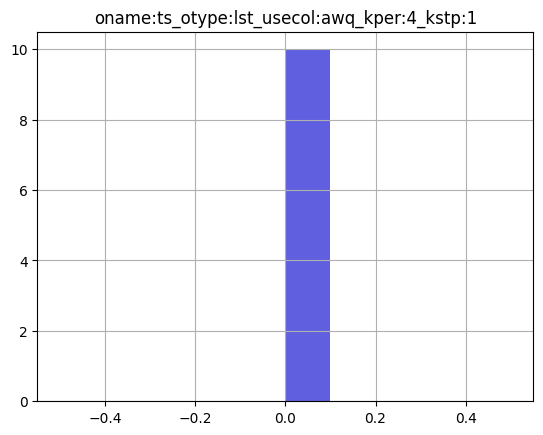

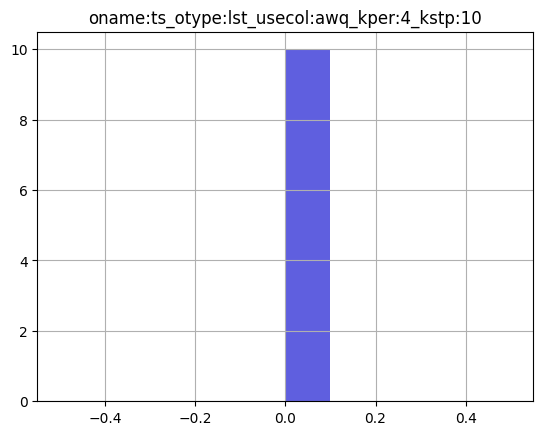

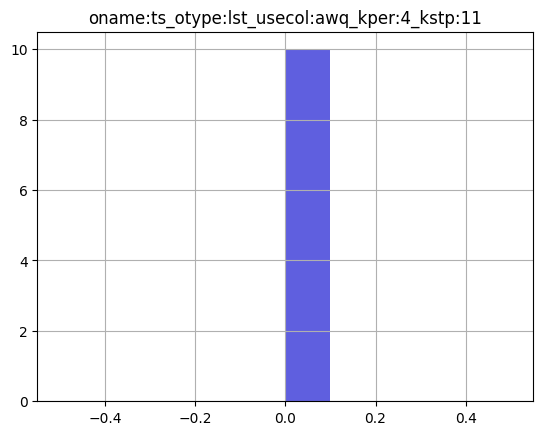

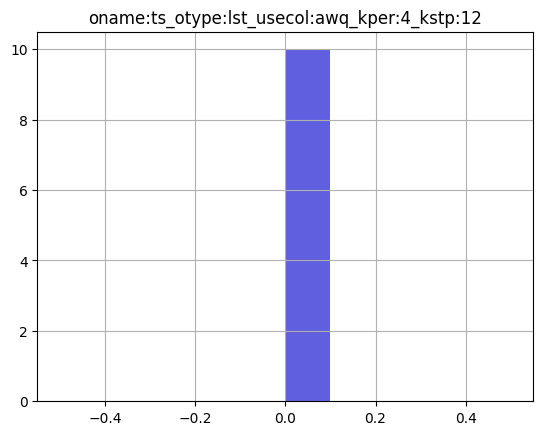

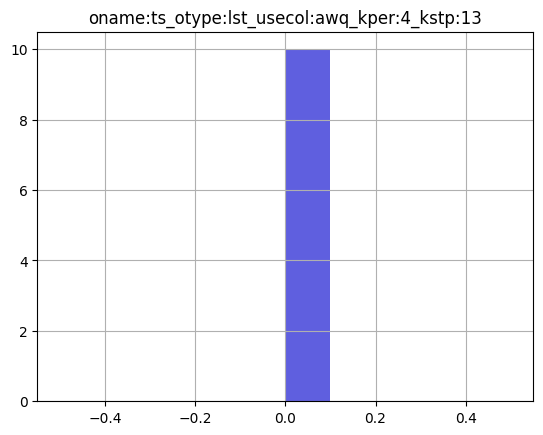

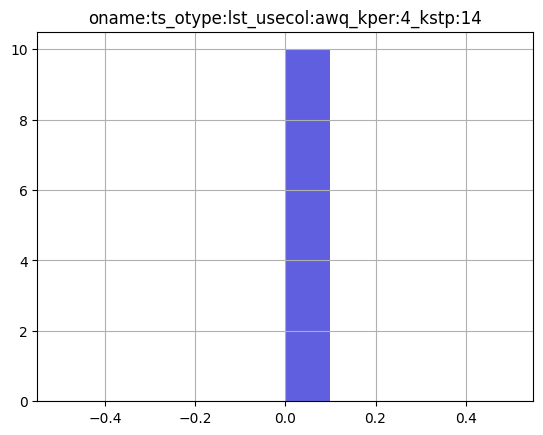

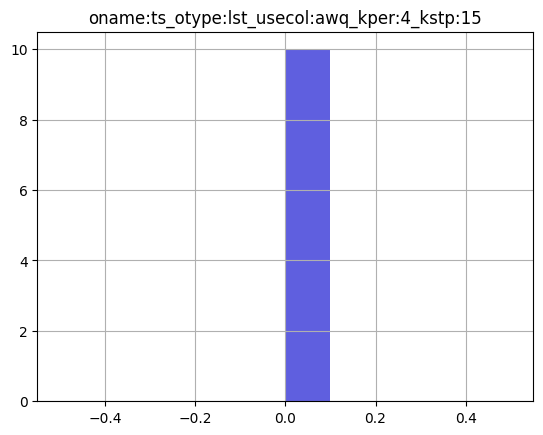

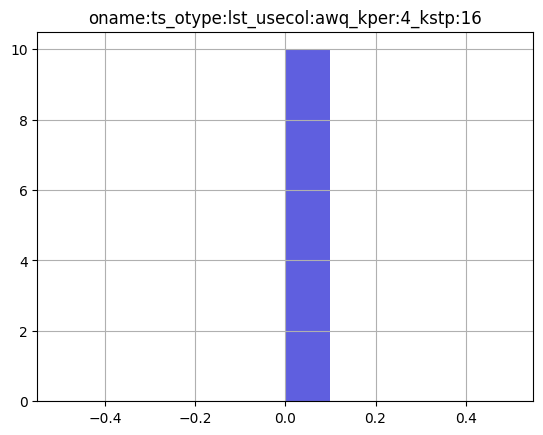

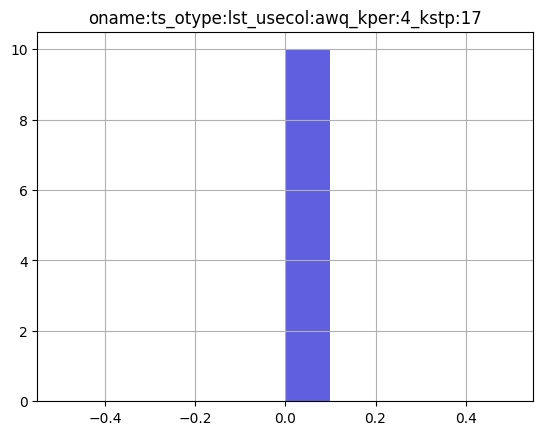

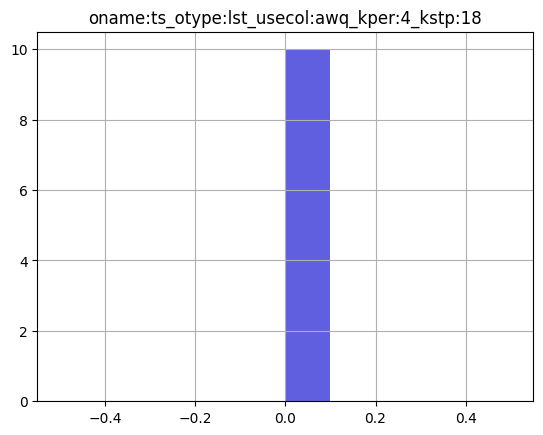

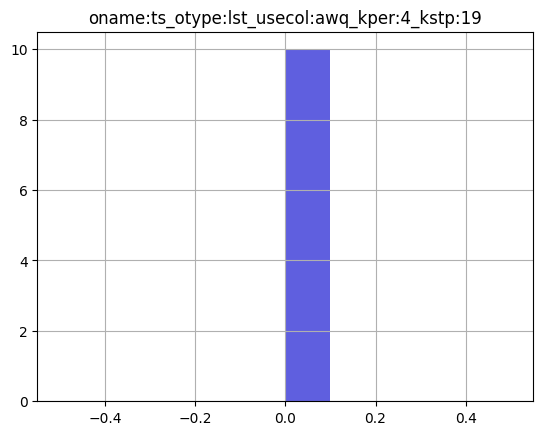

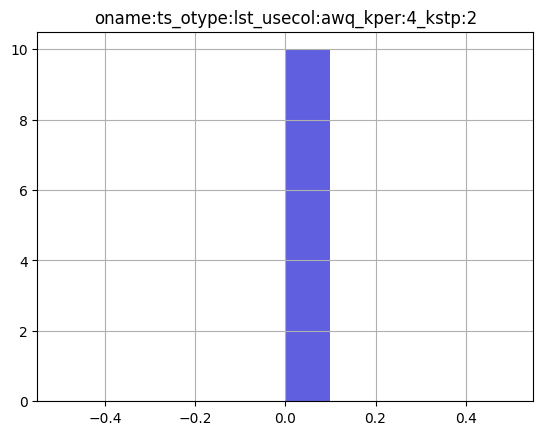

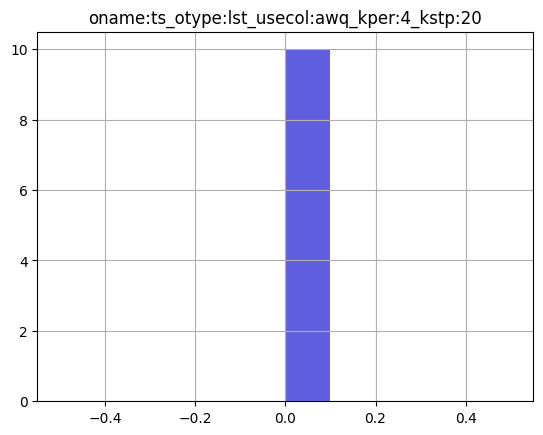

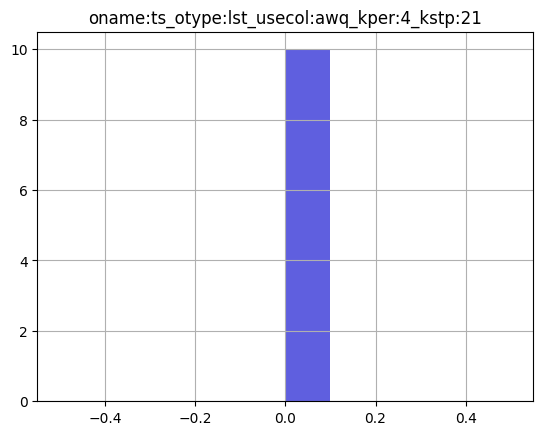

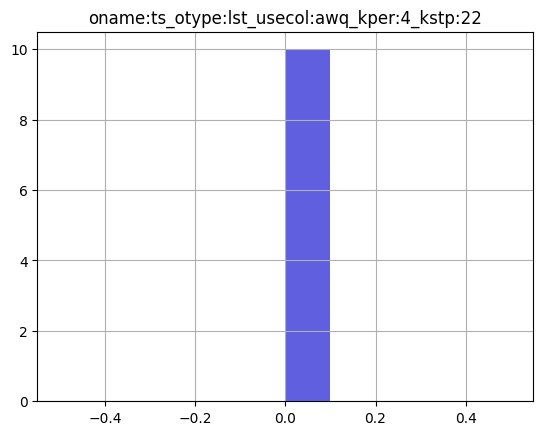

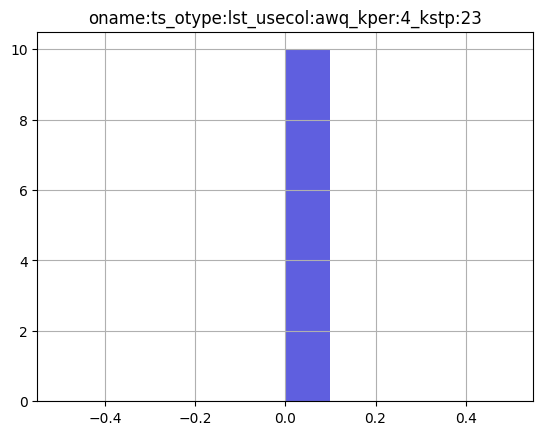

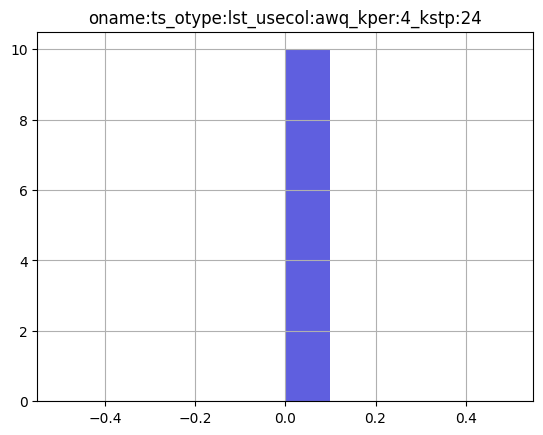

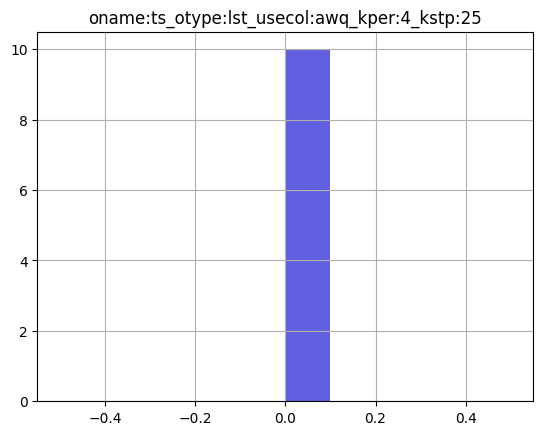

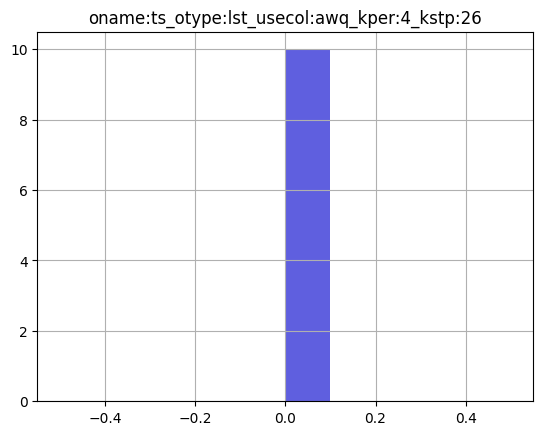

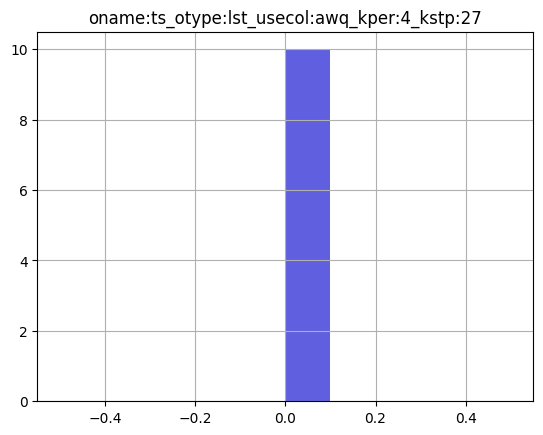

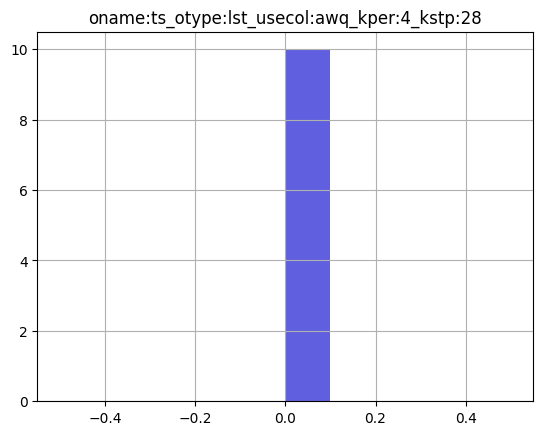

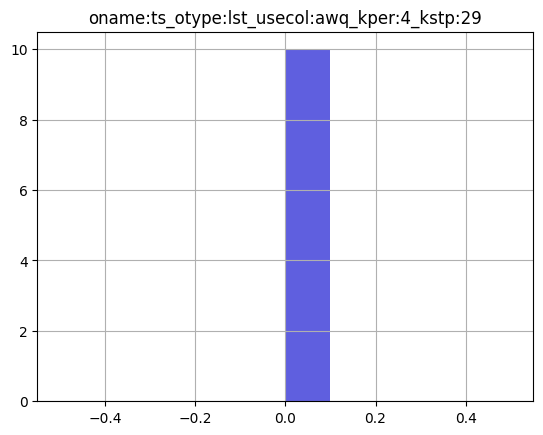

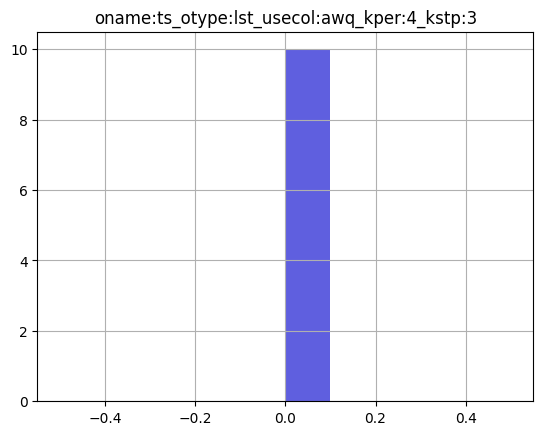

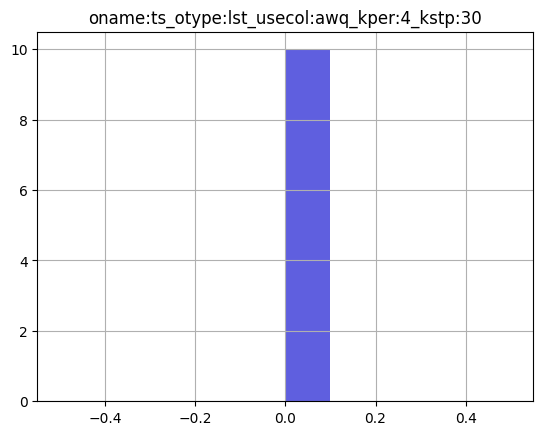

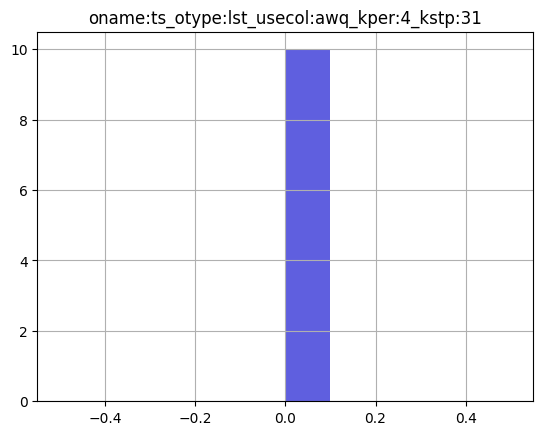

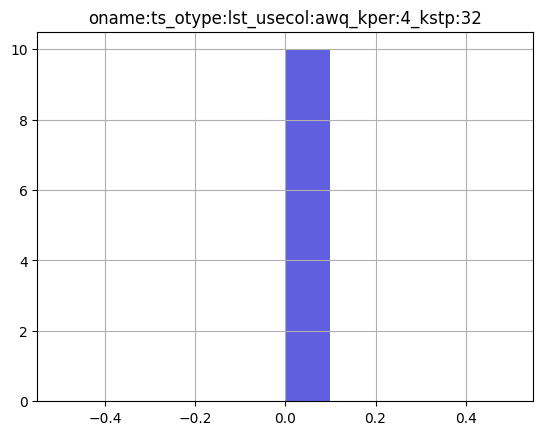

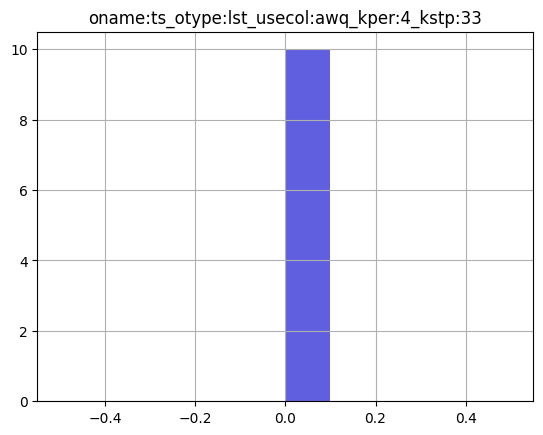

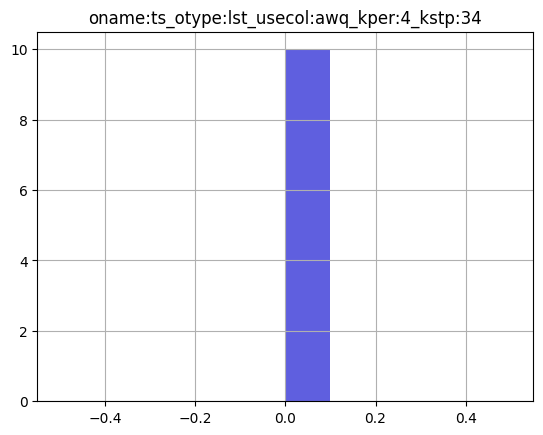

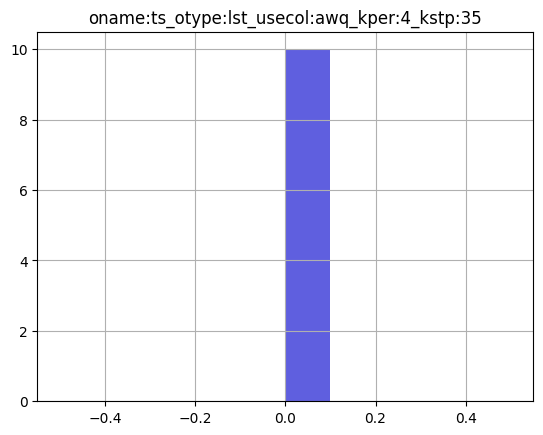

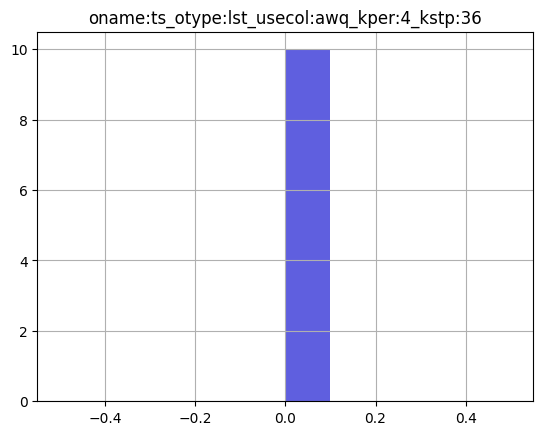

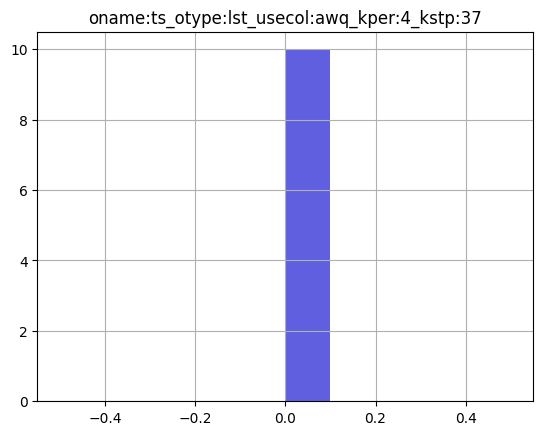

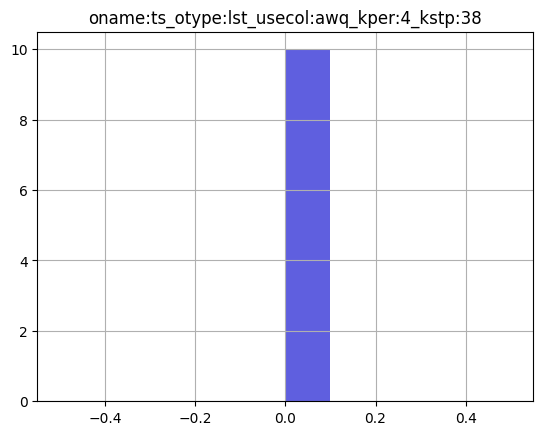

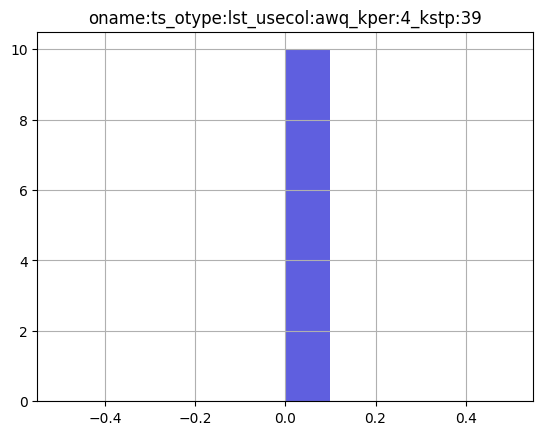

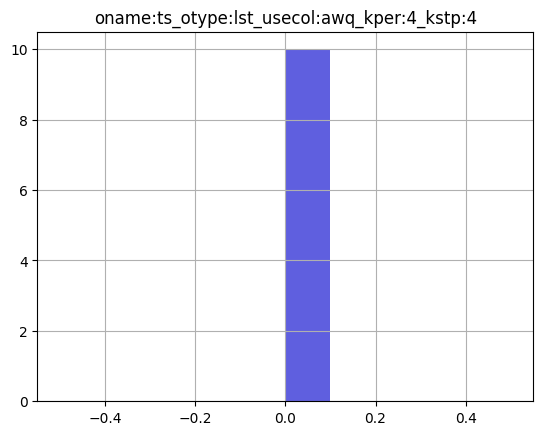

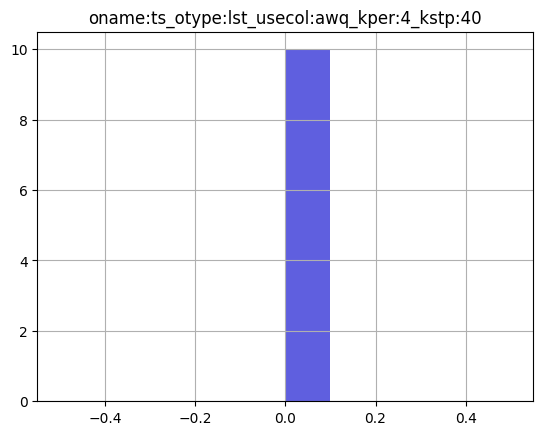

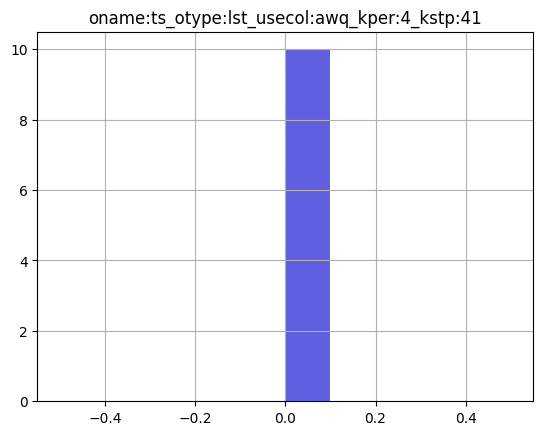

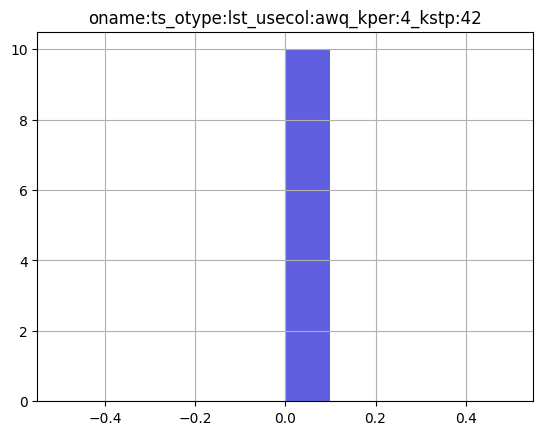

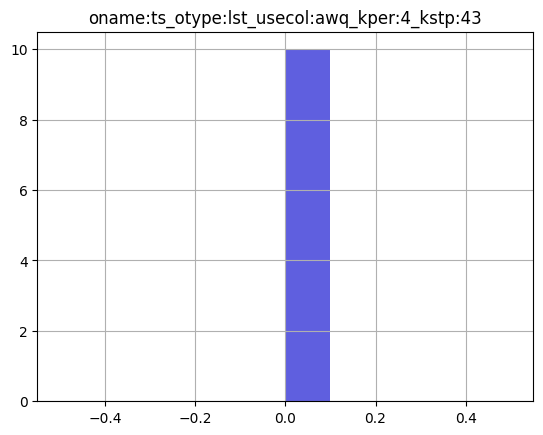

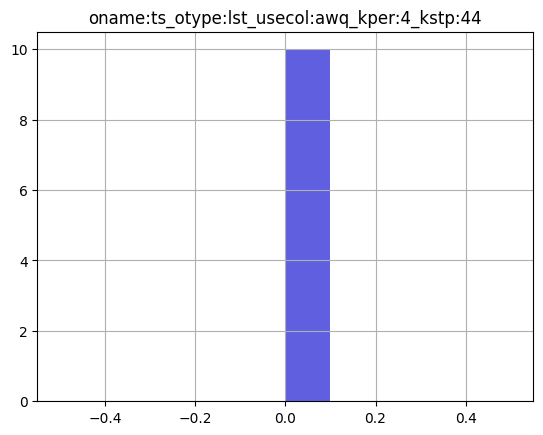

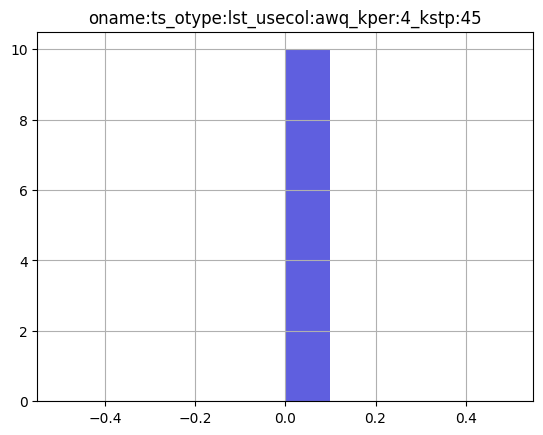

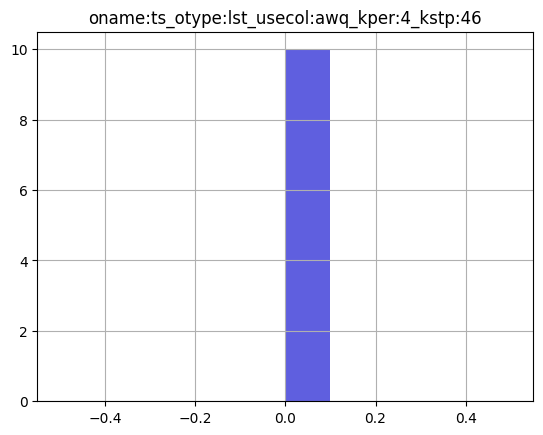

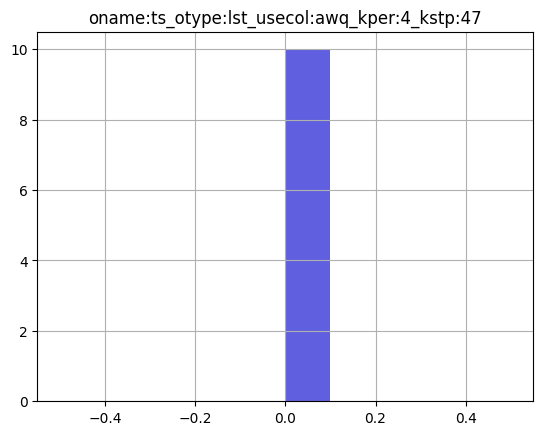

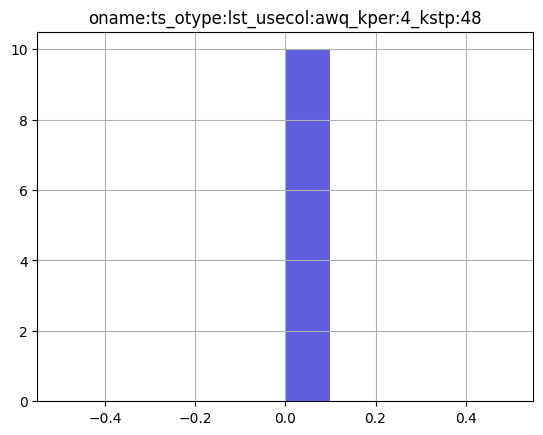

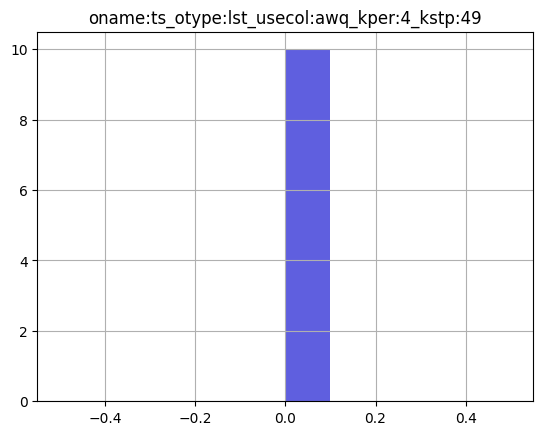

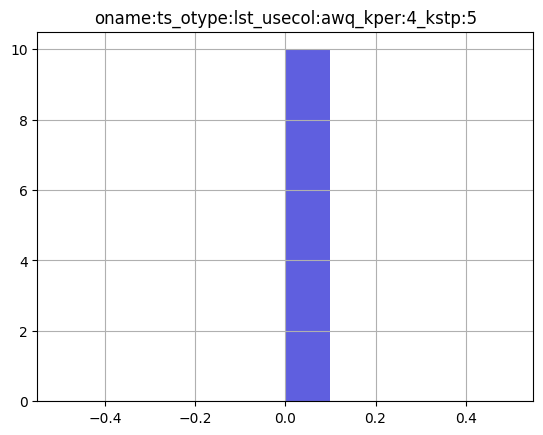

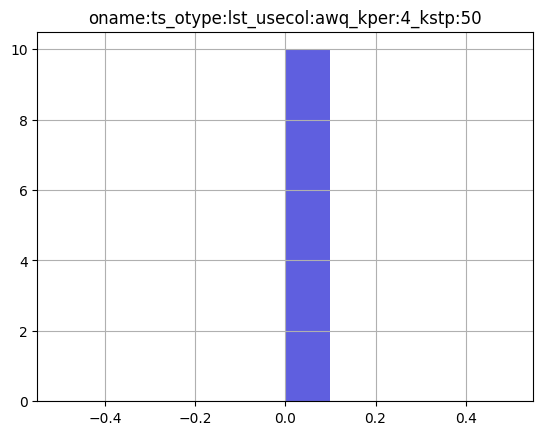

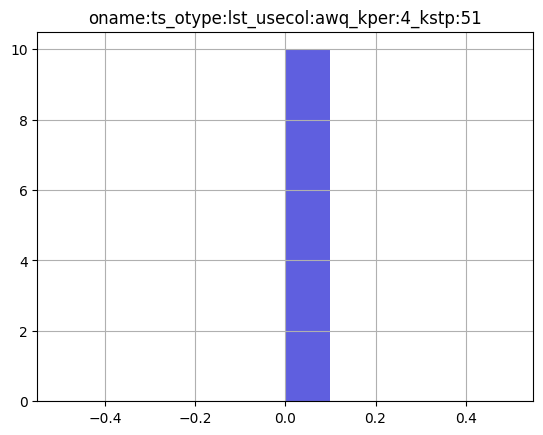

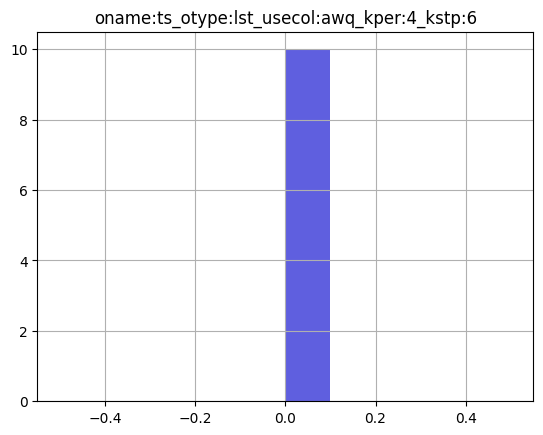

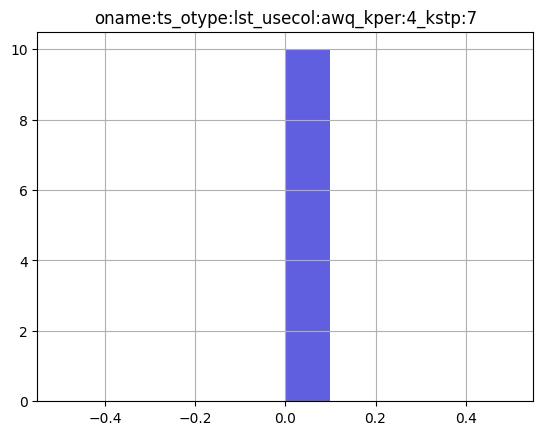

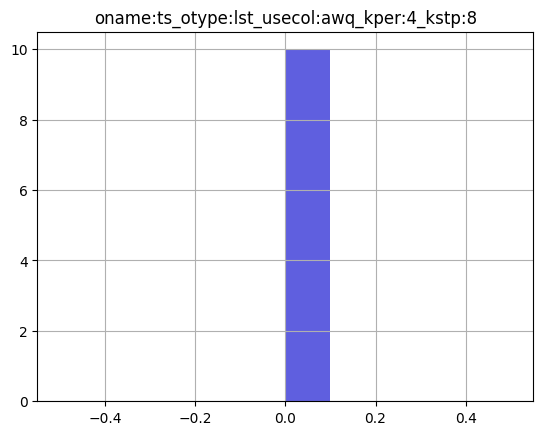

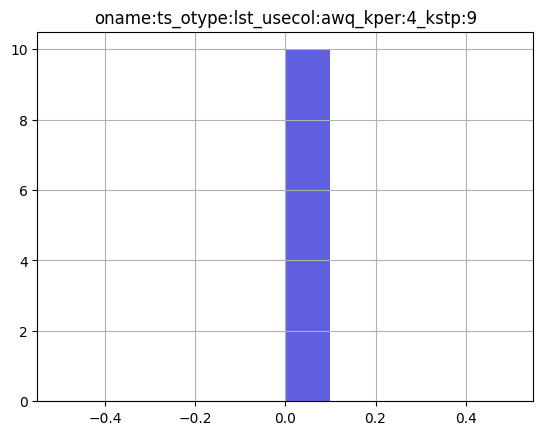

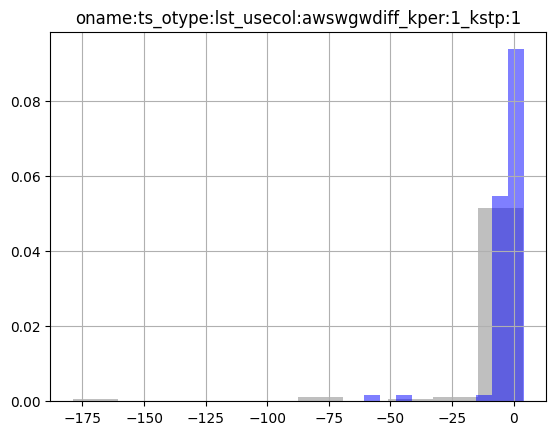

KeyboardInterrupt: 

In [31]:
for col in pr_oe.columns:
    # plot the prior and posterior ensemble distributions
    fig, ax = plt.subplots(1, 1)
    pr_oe.loc[:, col].hist(ax=ax, fc="0.5", ec="none", alpha=0.5, density=True)  # prior grey
    pt_oe.loc[:, col].hist(ax=ax, fc="b", ec="none", alpha=0.5, density=True)  # posterior blue
    ax.set_title(col)
    plt.show()

# Budget

In [96]:
m_d = r'../models/local2/pest/master_ies'
run_name = 'local2'

pr_oe_df = pd.read_csv(os.path.join(m_d, f"{run_name}.3.obs.csv"))

C:\Users\tfo46\AppData\Local\Temp\ipykernel_29600\930036039.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [97]:
mask = [col.split('_')[0].split(':')[-1] == 'bgt' for col in pr_oe_df.columns]
dat = pr_oe_df.loc[:,mask]

In [107]:
realization = 60

r0 = dat.iloc[realization, :].to_frame(name='value').reset_index()
r0.columns = ['oname', 'value']
r0['col'] = r0['oname'].map(lambda x: x.split('_')[2].split(':')[-1])
r0['kper'] = r0['oname'].map(lambda x: int(x.split('_')[3].split(':')[-1]))

<Axes: xlabel='col'>

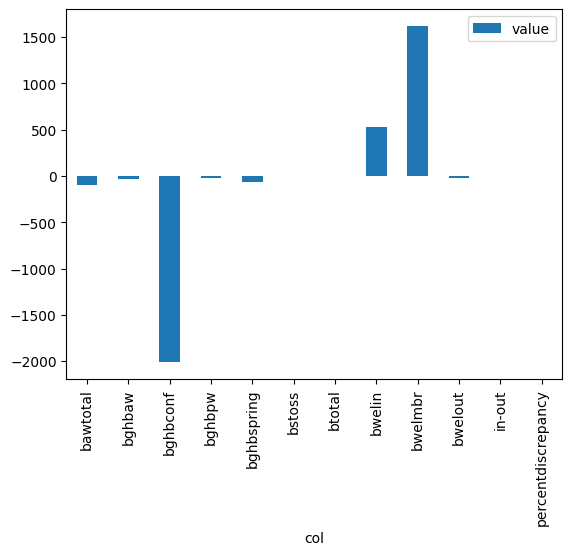

In [108]:
filtered = r0[(r0['kper'] == 1)]
filtered.plot.bar(x='col', y='value')

In [ ]:

# create array
filtered = r0[(r0['kper'] == 1) & (r0['kstp'] == 1)]
arr = filtered.pivot(index='i', columns='j', values='value').to_numpy()
max_nan = 1e+30
arr = np.where(arr == max_nan, np.nan, arr)

# Heads

In [ ]:
m_d = r'../models/local2/pest/master_ies'
run_name = 'local2'

pst = pst = pyemu.Pst(os.path.join(m_d, f"{run_name}.pst"))
pr_oe_df = pd.read_csv(os.path.join(m_d, f"{run_name}.3.obs.csv"))

C:\Users\tfo46\AppData\Local\Temp\ipykernel_29600\3840553852.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,oname:h_otype:lst_usecol:head_i:0_j:0_kper:1_kstp:1,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:1,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:10,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:11,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:12,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:13,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:14,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:15,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:16,oname:h_otype:lst_usecol:head_i:0_j:0_kper:2_kstp:17,...,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:47,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:48,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:49,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:5,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:50,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:51,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:6,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:7,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:8,oname:h_otype:lst_usecol:head_i:9_j:9_kper:4_kstp:9
0,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,...,11.86950,11.87850,11.88710,10.98250,11.89550,11.90360,11.02270,11.06140,11.09880,11.13480
1,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,...,9.61492,9.61492,9.61492,9.61562,9.61492,9.61492,9.61513,9.61498,9.61494,9.61492
2,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,...,12.01180,12.01530,12.01880,11.85760,12.02220,12.02570,11.86140,11.86530,11.86910,11.87300
3,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,...,12.01300,11.98560,11.95890,14.20900,11.93300,11.90780,14.12200,14.03730,13.95500,13.87480
4,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,1.000000e+30,...,13.97790,13.97780,13.97760,13.98490,13.97740,13.97730,13.98480,13.98460,13.98440,13.98420


In [ ]:
realization = 60
mask = [col.split('_')[0].split(':')[-1] == 'h' for col in pr_oe_df.columns]
hdat = pr_oe_df.loc[:,mask]

r0 = hdat.iloc[realization, :].to_frame(name='value').reset_index()
r0.columns = ['oname', 'value']
r0['i'] = r0['oname'].map(lambda x: int(x.split('_')[3].split(':')[-1]))
r0['j'] = r0['oname'].map(lambda x: int(x.split('_')[4].split(':')[-1]))
r0['kper'] = r0['oname'].map(lambda x: int(x.split('_')[5].split(':')[-1]))
r0['kstp'] = r0['oname'].map(lambda x: int(x.split('_')[6].split(':')[-1]))

# create array
filtered = r0[(r0['kper'] == 1) & (r0['kstp'] == 1)]
arr = filtered.pivot(index='i', columns='j', values='value').to_numpy()
max_nan = 1e+30
arr = np.where(arr == max_nan, np.nan, arr)
plt.imshow(arr)
# add contours
plt.contour(arr, colors='k', linewidths=0.5)
plt.colorbar()

### ss

In [ ]:
r0['i'] = r0.index.map(lambda x: int(x.split('_')[3].split(':')[-1]))
arr = filtered.pivot(index='i', columns='j', values='head').to_numpy()

TypeError: 'ObservationEnsemble' object does not support item assignment

In [8]:
col = pr_oe.columns[-1]

In [9]:
col.split('_')[5].split(':')

['kper', '4']

In [10]:
import numpy as np
conditions = (col.split('_')[0].split(':')[-1] == 'h')

# Filter columns where oname is 'h'
mask = [col.split('_')[0].split(':')[-1] == 'h' for col in pr_oe.columns]
h_cols = pr_oe.columns[mask]
kper_mask = [col.split('_')[5].split(':')[-1] == '1' for col in h_cols]
h_cols = h_cols[kper_mask]

In [11]:
h_cols

Index(['oname:h_otype:lst_usecol:head_i:0_j:0_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:10_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:11_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:12_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:13_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:14_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:15_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:16_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:17_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:0_j:18_kper:1_kstp:1',
       ...
       'oname:h_otype:lst_usecol:head_i:9_j:29_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:9_j:2_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:9_j:30_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:9_j:3_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:9_j:4_kper:1_kstp:1',
       'oname:h_otype:lst_usecol:head_i:9_j:5_kp

In [12]:
# Extract i and j indices from column names
i_vals = [int(col.split('_')[3].split(':')[-1]) for col in h_cols]
j_vals = [int(col.split('_')[4].split(':')[-1]) for col in h_cols]

# Determine array shape
nrow = max(i_vals) + 1
ncol = max(j_vals) + 1


In [27]:
col

'oname:h_otype:lst_usecol:head_i:9_j:9_kper:1_kstp:1'

In [31]:
col.split('_')[3]

'i:9'

In [20]:
arr[i, j] = 50

In [32]:
irealization = 20
arr = np.full((nrow, ncol), np.nan)
for icol in range(len(h_cols)):
    col = h_cols[icol]
    i = int(col.split('_')[3].split(':')[-1])
    j = int(col.split('_')[4].split(':')[-1])
    arr[i, j] = pr_oe.values[irealization][icol]  # or use .iloc[realization, col] if needed

In [29]:
arr[0,0] = 100

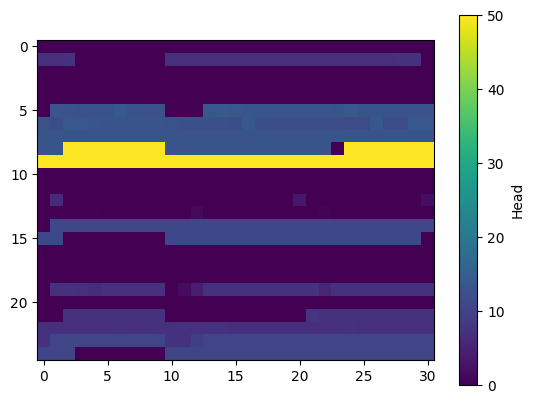

In [33]:
# arr now contains the head values organized by i, j
# plot heads
plt.imshow(arr, cmap='viridis', vmin=0, vmax=50)
plt.colorbar(label='Head')

# Params

In [33]:
pst = pyemu.Pst(os.path.join(m_d, f"{run_name}.pst"))
pr_pe = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.0.par.csv"))
pt_pe = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.{pst.control_data.noptmax}.par.csv"))

In [34]:
pr_pe

return type uncaught, losing Ensemble type, returning DataFrame


c:\Users\tfo46\e_Python\e_projects\pakipaki_01\.venv\Lib\site-packages\pyemu\en.py:227: PyemuWarning: return type uncaught, losing Ensemble type, returning DataFrame


,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:12_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:17_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:22_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:2_j:27_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:7_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:12_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:17_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:22_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:7_j:27_zone:1,pname:npfklayer1-pp_inst:0_ptype:pp_pstyle:m_i:12_j:2_zone:1,...,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:19_idx2:4,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:19_idx2:5,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:20_idx2:1,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:20_idx2:2,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:20_idx2:3,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:20_idx2:4,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:21_idx2:0,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:21_idx2:1,pname:ghb-conf-head-crgr_inst:2_ptype:gr_usecol:3_pstyle:a_idx0:0_idx1:21_idx2:2,pname:ghb-conf-head-cn_inst:2_ptype:cn_usecol:3_pstyle:a
real_name,,,,,,,,,,,,,,,,,,,,,
0,8.000890,11.072500,2.010360,0.389044,6.618630,7.706680,3.867370,3.282980,1.269850,1.885480,...,-0.654714,-0.542078,-0.691195,-0.742691,-0.865933,-0.784459,-0.782371,-0.884791,-0.863386,-0.449483
1,22.314900,9.008250,5.591420,2.229630,6.439650,4.591740,8.377770,5.813640,1.192450,2.792310,...,0.702379,0.277648,0.949108,1.029730,0.743256,0.579546,0.854280,0.630081,0.649254,-0.076086
2,0.106468,0.132968,0.403636,0.196436,0.782189,0.074772,0.039802,0.075567,0.195545,2.162730,...,-0.346583,-0.223921,0.381298,0.540780,-0.041180,0.054211,0.374716,0.341205,0.416268,0.485192
3,0.145517,0.239867,0.643708,0.872587,0.394064,0.287395,0.507956,0.343376,1.942490,5.620720,...,-0.386566,-0.450820,-0.672805,-0.218561,-0.337208,-0.269538,-0.550932,-0.320538,-0.253803,-0.854129
4,1.872070,0.645393,1.093760,0.797467,0.160693,0.321927,0.356099,0.610484,2.891300,0.227012,...,-0.285545,-0.170946,0.242404,0.183530,-0.043293,0.048105,0.546647,0.284584,0.180180,0.174282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.517170,0.190053,0.142611,0.093690,6.045420,7.162560,0.319358,0.195995,0.458060,37.103800,...,-0.630494,-0.599741,-0.605789,-0.412670,-0.380860,-0.428920,-0.641957,-0.440032,-0.197136,0.580019
96,3.947550,3.083720,2.473750,1.267360,0.285206,0.377027,0.332835,1.008950,0.763887,0.239943,...,-0.233210,-0.286943,-0.485114,-0.440976,-0.324428,-0.420567,-0.569928,-0.296302,-0.360358,0.355420
97,0.615812,1.480100,0.692888,0.282339,0.917813,1.696360,1.834380,1.560840,1.279250,0.516066,...,-0.017048,-0.259517,-0.508451,-0.456253,-0.070142,-0.141783,-0.356164,-0.690831,-0.485836,-0.643265


<Axes: >

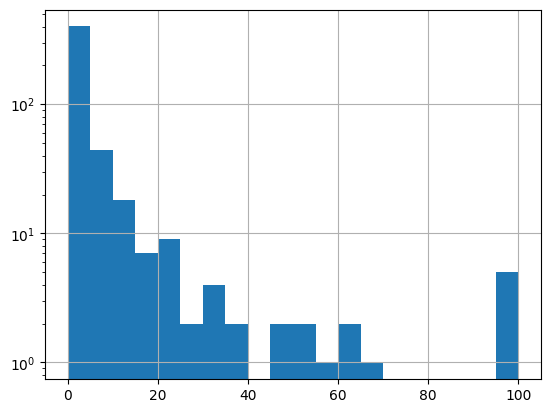

In [87]:
pr_oe_df = pr_oe._df
mask = pr_oe_df.columns.str.contains("npfklayer1")
cols = pr_oe_df.columns[mask]
pr_oe_df[cols[2]].hist(bins=20, log=True)

In [ ]:
pr_oe_df[cols[2]]

AttributeError: 'Series' object has no attribute 'log'

## using Mult to model

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package sto...
    loading package npf...
    loading package ic...
    loading package ghb...
    loading package ghb...
    loading package ghb...
    loading package ghb...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package oc...
  loading solution package local2...


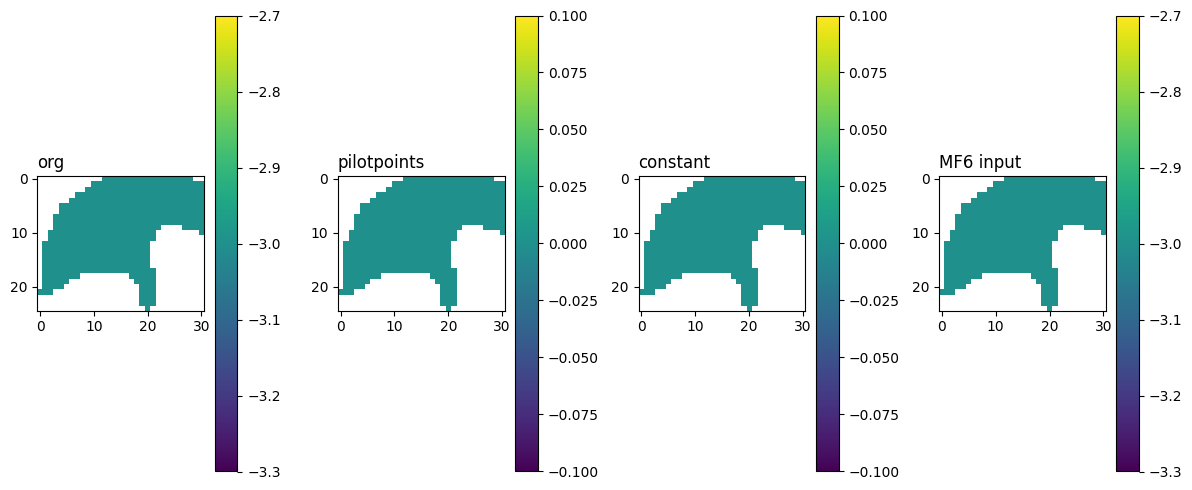

In [272]:
TEMP_DIR = r'../models/local2/pest/local2_template'
df = pd.read_csv(os.path.join(TEMP_DIR,"mult2model_info.csv"))
kh1_df = df.loc[df.model_file.str.contains("npf"),:]
sim = flopy.mf6.MFSimulation.load(sim_ws=m_d)
ib = sim.get_model().dis.idomain.array[0,:,:]

org_arr = np.loadtxt(os.path.join(TEMP_DIR,kh1_df.org_file.iloc[0]))
inp_arr = np.loadtxt(os.path.join(TEMP_DIR,kh1_df.model_file.iloc[0]))
mlt_arrs = [np.loadtxt(os.path.join(TEMP_DIR,afile)) for afile in kh1_df.mlt_file]
arrs = [org_arr]
arrs.extend(mlt_arrs)
arrs.append(inp_arr)
names = ["org"]
names.extend([mf.split('.')[0].split('_')[-1] for mf in kh1_df.mlt_file])
names.append("MF6 input")
fig,axes = plt.subplots(1,kh1_df.shape[0]+2,figsize=(5*kh1_df.shape[0]+2,5))
for i,ax in enumerate(axes.flatten()):
    arr = np.log10(arrs[i])
    arr[ib==0] = np.nan
    cb = ax.imshow(arr)
    plt.colorbar(cb,ax=ax)
    ax.set_title(names[i],loc="left")
plt.tight_layout()

In [273]:
kh1_df

,Unnamed: 0,org_file,model_file,use_cols,index_cols,fmt,sep,head_rows,upper_bound,lower_bound,...,mlt_file,fac_file,pp_file,pp_fill_value,pp_lower_limit,pp_upper_limit,zone_file,apply_order,chkpar,zero_based
0,0,org\local2.npf_k_layer1.txt,local2.npf_k_layer1.txt,NaN,NaN,%24.18E,NaN,0,1e+30,-1e+30,...,mult\npfklayer1-pp_inst0_pilotpoints.csv,npfklayer1-pp_inst0pp.fac,npfklayer1-pp_inst0pp.dat,1.0,1.000000e-30,1.000000e+30,npfklayer1-pp_inst0pp.dat.zone,999,NaN,False
1,1,org\local2.npf_k_layer1.txt,local2.npf_k_layer1.txt,NaN,NaN,%24.18E,NaN,0,1e+30,-1e+30,...,mult\npfklayer1-cn_inst0_constant.csv,NaN,NaN,NaN,NaN,NaN,npfklayer1-cn_inst0_constant.csv.zone,999,NaN,False


# Prior data conflict

In [274]:
pdc0 = os.path.join(m_d, f"{run_name}.0.pdc.csv")
#read
pdc = pd.read_csv(pdc0,index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: '../models/local2/pest/master_ies\\local2.0.pdc.csv'

In [43]:
pdc

,obs_mean,obs_std,obs_min,obs_max,obs_stat_min,obs_stat_max,sim_mean,sim_std,sim_min,sim_max,sim_stat_min,sim_stat_max,distance
name,,,,,,,,,,,,,
oname:flux_otype:lst_usecol:drn_totim:1,100404.00,1.310980e-10,100404.00,100404.00,100404.00,100404.00,-5116.88000,1845.98000,-11946.90000,-1368.540000,-6962.87000,-3270.90000,101772.000000
oname:heads_otype:lst_usecol:pk2_head_kper:0,7.60,1.600320e-14,7.60,7.60,7.60,7.60,12.00160,2.08976,8.45290,18.348300,9.91185,14.09140,0.852895
oname:heads_otype:lst_usecol:pk4_head_kper:0,7.80,1.689230e-14,7.80,7.80,7.80,7.80,15.22420,3.31495,9.78740,23.325900,11.90920,18.53910,1.987400
oname:heads_otype:lst_usecol:pk4_pk2_diff_kper:0,-0.20,4.723170e-16,-0.20,-0.20,-0.20,-0.20,3.22257,1.33145,1.05173,6.530730,1.89112,4.55402,1.251730
oname:heads_otype:lst_usecol:spring_pk2_diff_kper:0,0.05,1.180790e-16,0.05,0.05,0.05,0.05,-3.77553,1.78029,-8.42896,-0.600441,-5.55582,-1.99524,0.650441
oname:heads_otype:lst_usecol:spring_pk4_diff_kper:0,-0.15,0.000000e+00,-0.15,-0.15,-0.15,-0.15,-6.99810,3.10169,-14.87090,-1.989220,-10.09980,-3.89641,1.839220


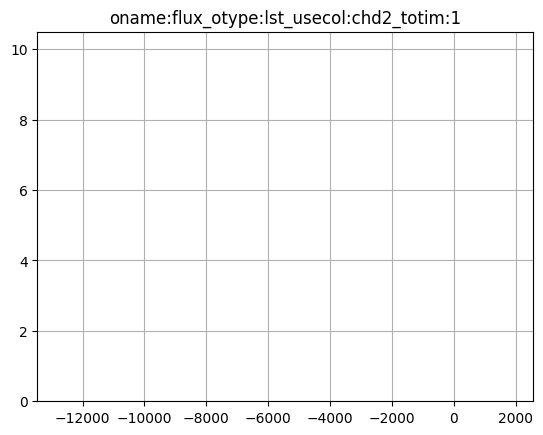

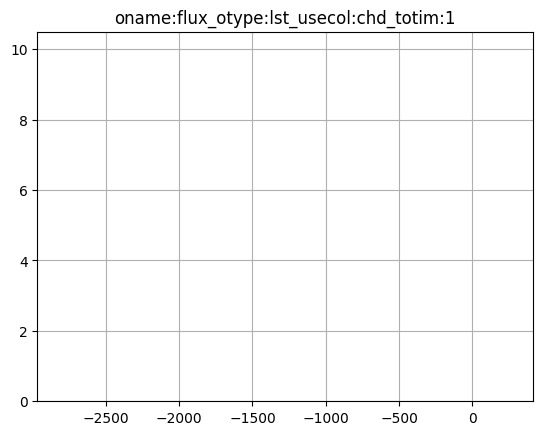

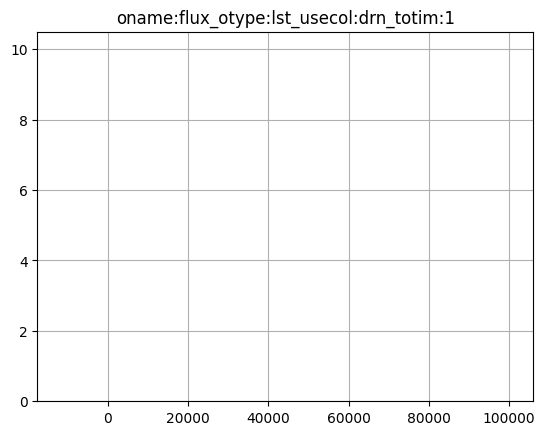

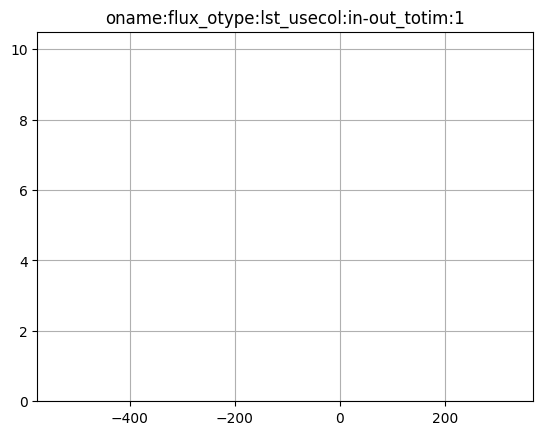

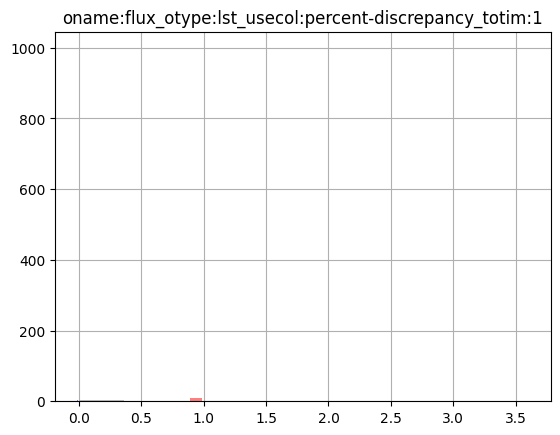

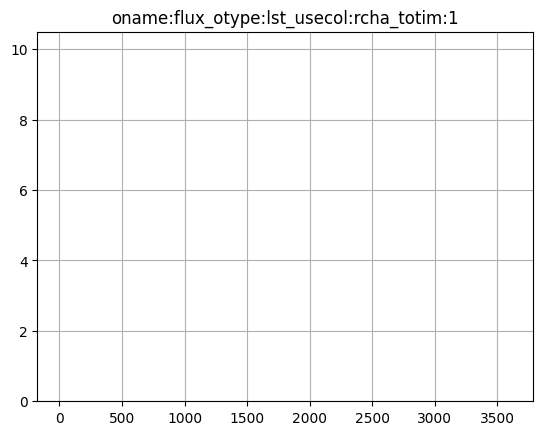

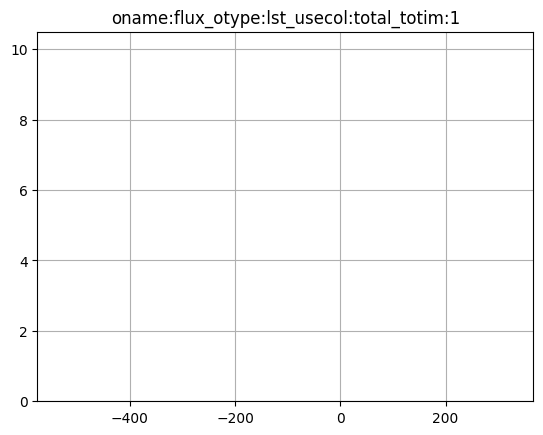

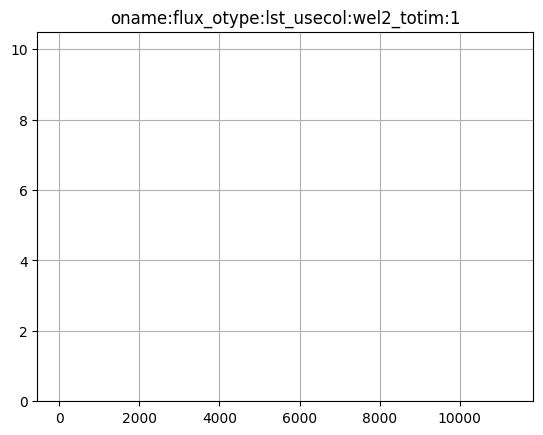

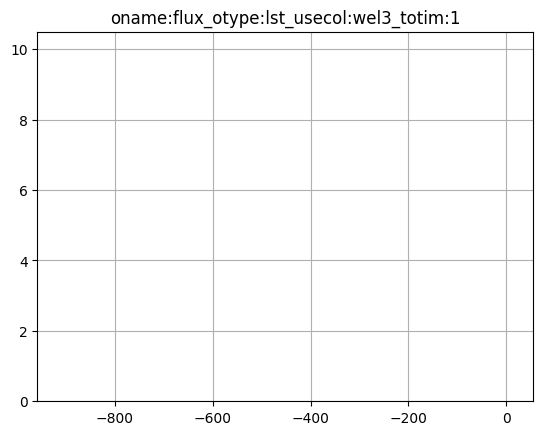

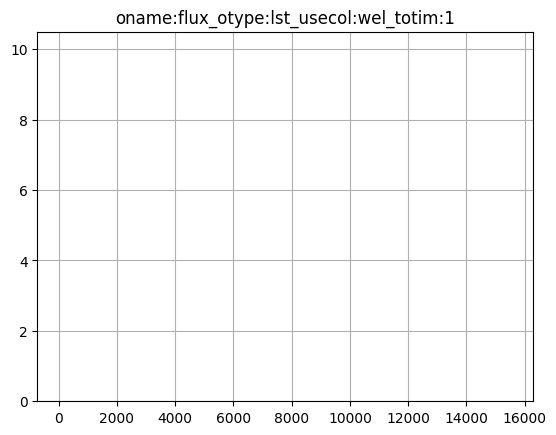

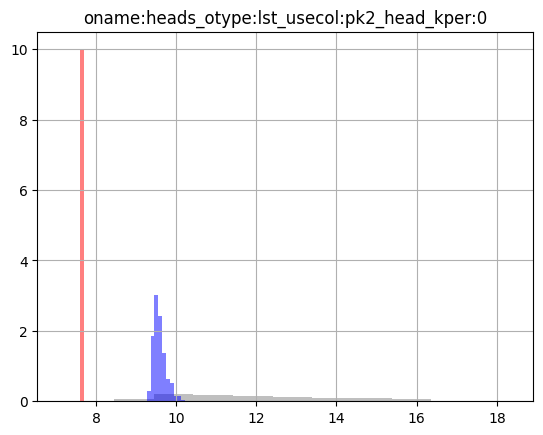

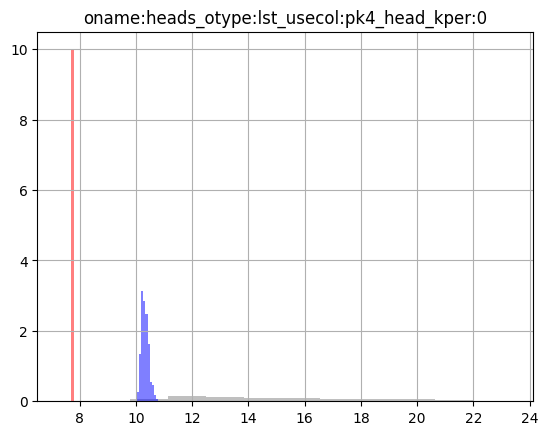

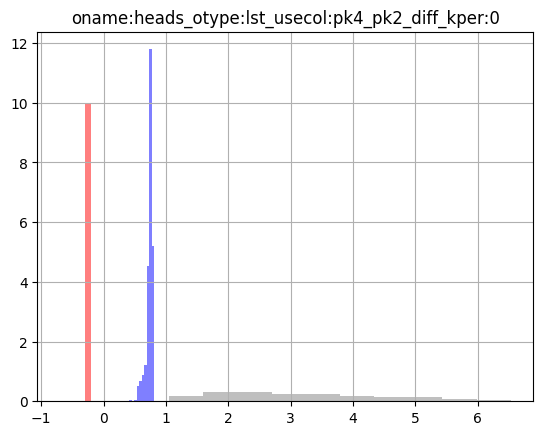

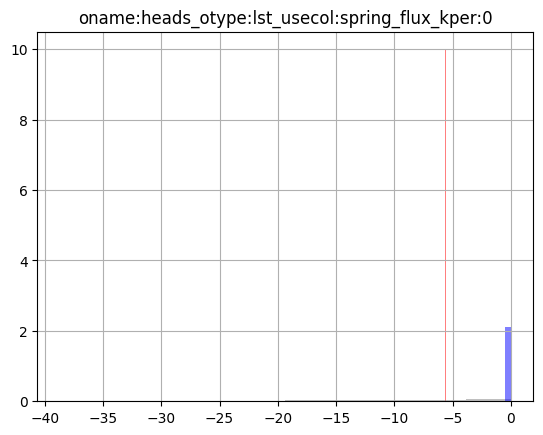

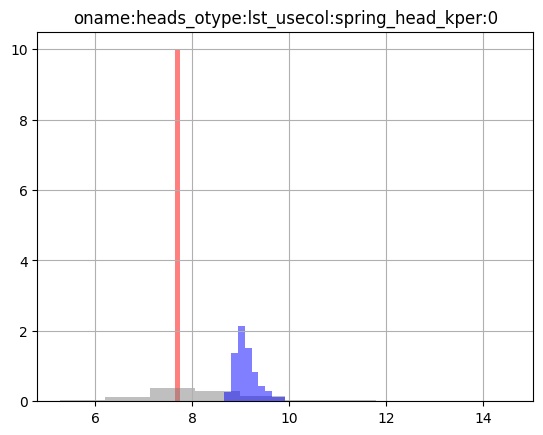

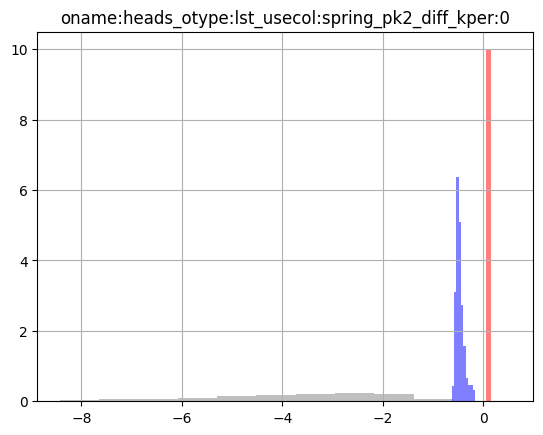

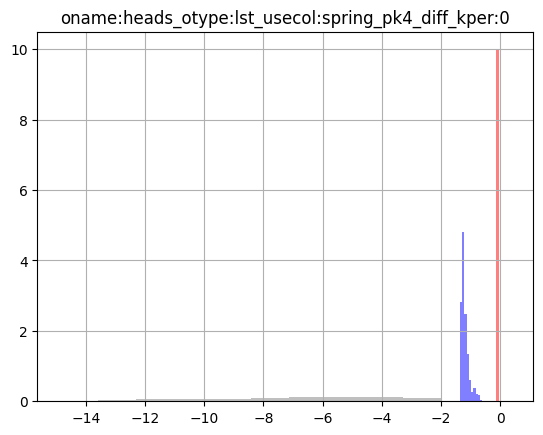

In [49]:
# plot obs+noise vs prior mean
for col in pr_oe.columns:
    # plot the prior and posterior ensemble distributions
    fig, ax = plt.subplots(1, 1)
    noise.loc[:, col].hist(ax=ax, fc="r", ec="none", alpha=0.5, density=True)  # posterior blue
    pr_oe.loc[:, col].hist(ax=ax, fc="0.5", ec="none", alpha=0.5, density=True)  # prior grey
    pt_oe.loc[:, col].hist(ax=ax, fc="b", ec="none", alpha=0.5, density=True)  # posterior blue
    ax.set_title(col)
    plt.show()

# Forecasts

In [275]:
pst.forecast_names

['oname:ts_otype:lst_usecol:pk4head_kper:3_kstp:1',
 'oname:ts_otype:lst_usecol:pk4head_kper:4_kstp:1',
 'oname:ts_otype:lst_usecol:pk4head_kper:4_kstp:2',
 'oname:ts_otype:lst_usecol:pk4head_kper:4_kstp:3',
 'oname:ts_otype:lst_usecol:pk4head_kper:4_kstp:4',
 'oname:ts_otype:lst_usecol:pk4head_kper:4_kstp:5',
 'oname:ts_otype:lst_usecol:pk4springdiff_kper:3_kstp:1',
 'oname:ts_otype:lst_usecol:pk4springdiff_kper:4_kstp:1',
 'oname:ts_otype:lst_usecol:pk4springdiff_kper:4_kstp:2',
 'oname:ts_otype:lst_usecol:pk4springdiff_kper:4_kstp:3',
 'oname:ts_otype:lst_usecol:pk4springdiff_kper:4_kstp:4',
 'oname:ts_otype:lst_usecol:pk4springdiff_kper:4_kstp:5',
 'oname:ts_otype:lst_usecol:springq_kper:1_kstp:1',
 'oname:ts_otype:lst_usecol:springq_kper:2_kstp:1',
 'oname:ts_otype:lst_usecol:springq_kper:2_kstp:2',
 'oname:ts_otype:lst_usecol:springq_kper:2_kstp:3',
 'oname:ts_otype:lst_usecol:springq_kper:2_kstp:4',
 'oname:ts_otype:lst_usecol:springq_kper:2_kstp:5',
 'oname:ts_otype:lst_usecol:

In [123]:
def plot_forecast_hist_compare(pt_oe,pr_oe, last_pt_oe=None,last_prior=None ):
        num_plots = len(pst.forecast_names)
        num_cols = 1
        if last_pt_oe!=None:
            num_cols=2
        fig,axes = plt.subplots(num_plots, num_cols, figsize=(5*num_cols,num_plots * 2.5), sharex='row',sharey='row')
        for axs,forecast in zip(axes, pst.forecast_names):
            # plot first column with current outcomes
            if num_cols==1:
                axs=[axs]
            ax = axs[0]
            # just for aesthetics
            bin_cols = [pt_oe.loc[:,forecast], pr_oe.loc[:,forecast],]
            if num_cols>1:
                bin_cols.extend([last_pt_oe.loc[:,forecast],last_prior.loc[:,forecast]])
            bins=np.histogram(pd.concat(bin_cols),
                                         bins=20)[1] #get the bin edges
            pr_oe.loc[:,forecast].hist(facecolor="0.5",alpha=0.5, bins=bins, ax=ax)
            pt_oe.loc[:,forecast].hist(facecolor="b",alpha=0.5, bins=bins, ax=ax)
            ax.set_title(forecast)
            fval = pst.observation_data.loc[forecast,"obsval"]
            ax.plot([fval,fval],ax.get_ylim(),"r-")
            # plot second column with other outcomes
            if num_cols >1:
                ax = axs[1]
                last_prior.loc[:,forecast].hist(facecolor="0.5",alpha=0.5, bins=bins, ax=ax)
                last_pt_oe.loc[:,forecast].hist(facecolor="b",alpha=0.5, bins=bins, ax=ax)
                ax.set_title(forecast)
                fval = pst.observation_data.loc[forecast,"obsval"]
                ax.plot([fval,fval],ax.get_ylim(),"r-")
        # set ax column titles
        if num_cols >1:
            axes.flatten()[0].text(0.5,1.2,"Current Attempt", transform=axes.flatten()[0].transAxes, weight='bold', fontsize=12, horizontalalignment='center')
            axes.flatten()[1].text(0.5,1.2,"Previous Attempt", transform=axes.flatten()[1].transAxes, weight='bold', fontsize=12, horizontalalignment='center')
        fig.tight_layout()
        return fig

In [124]:
fig = plot_forecast_hist_compare(pt_oe=pt_oe, pr_oe=pr_oe)

NameError: name 'pt_oe' is not defined